In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Label counts:
FINAL LABEL
Govt Critique    104
Neutral           53
Govt Leaning      43
Name: count, dtype: int64


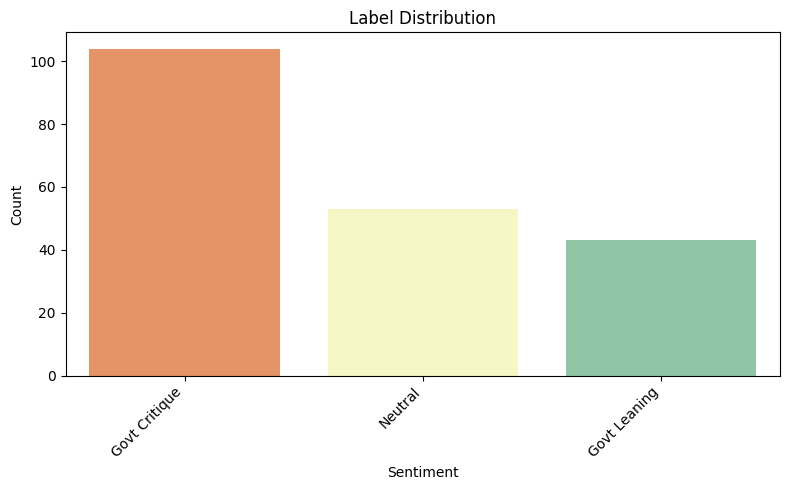

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Political_Bias/Dataset.csv')

df['FINAL LABEL'] = df['FINAL LABEL'].str.strip()
df['FINAL LABEL'] = df['FINAL LABEL'].str.lower()
df['FINAL LABEL'] = df['FINAL LABEL'].str.title()

label_counts = df['FINAL LABEL'].value_counts()
print("Label counts:")
print(label_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='FINAL LABEL', hue='FINAL LABEL', palette='Spectral', dodge=False, legend=False)
plt.title("Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
columns_to_clean = [
    'Annotator 1',
    'Annotator 2 [Zannatul]',
    'Annotator 3-MIM',
    'FINAL LABEL',
    'Article Label',
    'image label'
]

for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower().str.title()
    else:
        print(f"Warning: Column '{col}' not found in DataFrame.")

print("Cleaned label columns in df:")
print(df[columns_to_clean].head())

Cleaned label columns in df:
     Annotator 1 Annotator 2 [Zannatul] Annotator 3-MIM    FINAL LABEL  \
0  Govt Critique          Govt Critique   Govt Critique  Govt Critique   
1  Govt Critique          Govt Critique   Govt Critique  Govt Critique   
2  Govt Critique          Govt Critique   Govt Critique  Govt Critique   
3            Nan          Govt Critique   Govt Critique  Govt Critique   
4            Nan                Neutral         Neutral        Neutral   

   Article Label    image label  
0        Neutral  Govt Critique  
1  Govt Critique  Govt Critique  
2            Nan            Nan  
3  Govt Critique        Neutral  
4        Neutral        Neutral  


In [ ]:
print("\nValue counts for cleaned label columns:")
for col in columns_to_clean:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts())
    else:
        print(f"Warning: Column '{col}' not found for value counts.")


Value counts for cleaned label columns:

--- Annotator 1 ---
Annotator 1
Nan              168
Govt Critique     19
Govt Leaning       9
Neutral            4
Name: count, dtype: int64

--- Annotator 2 [Zannatul] ---
Annotator 2 [Zannatul]
Govt Critique    104
Neutral           56
Govt Leaning      39
Nan                1
Name: count, dtype: int64

--- Annotator 3-MIM ---
Annotator 3-MIM
Govt Critique    91
Neutral          71
Govt Leaning     37
Nan               1
Name: count, dtype: int64

--- FINAL LABEL ---
FINAL LABEL
Govt Critique    104
Neutral           53
Govt Leaning      43
Name: count, dtype: int64

--- Article Label ---
Article Label
Govt Critique    72
Neutral          60
Nan              41
Govt Leaning     27
Name: count, dtype: int64

--- image label ---
image label
Neutral          106
Nan               45
Govt Critique     41
Govt Leaning       8
Name: count, dtype: int64


In [ ]:
output_path = '/content/drive/MyDrive/Political_Bias/Political_Bias_Cleaned_Dataset.csv'
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: /content/drive/MyDrive/Political_Bias/Political_Bias_Cleaned_Dataset.csv


In [ ]:
!pip install emoji

import re
import pandas as pd
import unicodedata
import emoji

def replace_emoji_with_text(text):
    return emoji.demojize(text, delimiters=(" ", " "))

def remove_urls_hashtags_html(text):
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'#\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    return text

def remove_non_bengali(text):
    return re.sub(r'[^\u0980-\u09FF\s\n]', ' ', text)

def normalize_whitespace(text):
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n+', '\n', text)
    return text.strip()

def normalize_unicode(text):
    return unicodedata.normalize('NFKC', text)

def basic_preprocess(text):
    text = str(text)

    text = replace_emoji_with_text(text)
    text = remove_urls_hashtags_html(text)
    text = remove_non_bengali(text)
    text = normalize_unicode(text)
    text = normalize_whitespace(text)

    return text

input_path = '/content/drive/MyDrive/Political_Bias/Political_Bias_Cleaned_Dataset.csv'
output_path = '/content/drive/MyDrive/Political_Bias/Preprocesing.csv'

df = pd.read_csv(input_path)
df['Preprocessed_Text'] = df['Title'].apply(basic_preprocess)
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print("Preprocessing complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.3 MB/s eta 0:00:00
Preprocessing complete.


In [ ]:
import pandas as pd

input_path = '/content/drive/MyDrive/Political_Bias/Preprocesing.csv'
output_path = '/content/drive/MyDrive/Political_Bias/Preprocesing_Cleaned.csv'
df = pd.read_csv(input_path)
columns_to_drop = [
    'Date',
    'Annotator 1',
    'Annotator 2 [Zannatul]',
    'Annotator 3-MIM',
    'NB',
    'Unnamed: 14',
    'Unnamed: 15',
    'Unnamed: 16', 'FINAL_LABEL_NUM',	'Article Label_NUM',	'image label_NUM',	'Annotator 1_NUM',	'Annotator 2 [Zannatul]_NUM',	'Annotator 3-MIM_NUM',	'FINAL LABEL_NUM'
]

df = df.drop(columns=columns_to_drop, errors='ignore')

df.to_csv(output_path, index=False, encoding='utf-8-sig')
print("Columns dropped successfully.")

Columns dropped successfully.


In [ ]:
import pandas as pd

input_path = '/content/drive/MyDrive/Political_Bias/Preprocesing_Cleaned.csv'
output_path = '/content/drive/MyDrive/Political_Bias/Final_Dataset.csv'
df = pd.read_csv(input_path)
label_map = {
    'Govt Critique': 0,
    'Neutral': 1,
    'Govt Leaning': 2
}

label_columns = [
    'Article Label',
    'image label',
    'FINAL LABEL'
]

for col in label_columns:
    df[col] = df[col].map(label_map)

df.to_csv(output_path, index=False, encoding='utf-8-sig')
print("Numerical label conversion complete.")

Numerical label conversion complete.


In [ ]:
import pandas as pd

input_path = "/content/drive/MyDrive/Political_Bias/Final_Dataset.csv"
df = pd.read_csv(input_path)

print("Original dataset shape:", df.shape)
df_cleaned = df.drop_duplicates(subset=['Title', 'Preprocessed_Text'], keep='first').reset_index(drop=True)
print("After removing duplicates:")
print("Dataset shape:", df_cleaned.shape)
duplicates_removed = len(df) - len(df_cleaned)
print(f"Number of duplicate rows removed: {duplicates_removed}")

output_path = "/content/drive/MyDrive/Political_Bias/Final_Dataset.csv"
df_cleaned.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Cleaned dataset saved to: {output_path}")

Original dataset shape: (200, 11)
After removing duplicates:
Dataset shape: (198, 11)
Number of duplicate rows removed: 2
Cleaned dataset saved to: /content/drive/MyDrive/Political_Bias/Final_Dataset.csv


Label counts:
FINAL LABEL
0    103
1     53
2     42
Name: count, dtype: int64


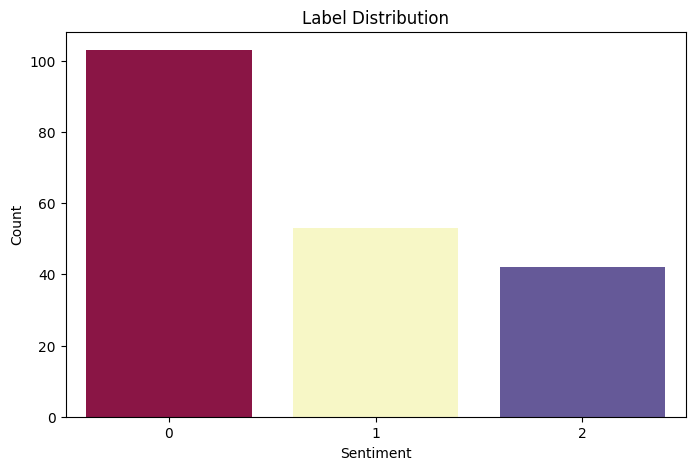

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Political_Bias/Final_Dataset.csv')

label_counts = df['FINAL LABEL'].value_counts()
print("Label counts:")
print(label_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='FINAL LABEL', hue='FINAL LABEL', palette='Spectral', dodge=False, legend=False)
plt.title("Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [ ]:
import pandas as pd
from statsmodels.stats.inter_rater import fleiss_kappa
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('/content/drive/MyDrive/Political_Bias/Preprocesing.csv')

annotations = df[['Annotator 1', 'Annotator 2 [Zannatul]', 'Annotator 3-MIM']]

encoder = LabelEncoder()
all_labels = pd.concat([annotations[col] for col in annotations.columns])
encoder.fit(all_labels)

annotations_encoded = annotations.apply(encoder.transform)

n_categories = len(encoder.classes_)
fleiss_matrix = []

for _, row in annotations_encoded.iterrows():
    counts = [0] * n_categories
    for label in row:
        counts[label] += 1
    fleiss_matrix.append(counts)

fleiss_df = pd.DataFrame(fleiss_matrix, columns=encoder.classes_)

kappa_score = fleiss_kappa(fleiss_df.to_numpy())
print("Fleiss' Kappa:", kappa_score)

Fleiss' Kappa: 0.08936907380862955


In [ ]:
!pip install googletrans==4.0.0-rc1

import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from googletrans import Translator
import time

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Final_Dataset.csv")

print("Original dataset shape:", df.shape)
print("\nClass distribution:")
print(df['FINAL LABEL'].value_counts())
print("\nClass mapping:")
print("0: Govt Critique, 1: Neutral, 2: Govt Leaning")

BENGALI_SYNONYMS = {
    'সরকার': ['প্রশাসন', 'রাষ্ট্র', 'কর্তৃপক্ষ', 'গণপ্রশাসন'],
    'বলা': ['উল্লেখ করা', 'জানানো', 'উচ্চারণ করা', 'ঘোষণা করা'],
    'জন্য': ['উদ্দেশ্যে', 'খাতিরে', 'মতো', 'জন্যে'],
    'আর': ['এবং', 'ও', 'পাশাপাশি'],
    'কিন্তু': ['তবে', 'অথচ', 'যদিও'],
    'এখন': ['বর্তমানে', 'এই মুহূর্তে', 'সময়টি'],
    'দেশ': ['রাষ্ট্র', 'জাতি', 'ভূমি', 'দেশজ'],
    'মানুষ': ['ব্যক্তি', 'লোক', 'জন', 'নাগরিক'],
    'সমস্যা': ['কষ্ট', 'দুর্দশা', 'বিপত্তি', 'সমঝোতা'],
    'সমাধান': ['ফলাফল', 'মীমাংসা', 'উপায়'],
    'প্রধান': ['মুখ্য', 'প্রথম', 'গুরুত্বপূর্ণ', 'অগ্রণী'],
    'বিশেষ': ['অসাধারণ', 'অন্যন্য', 'বিশিষ্ট'],
    'নতুন': ['তাজা', 'সদ্য', 'আধুনিক', 'নবীন'],
    'ভাল': ['উত্তম', 'চমৎকার', 'সুন্দর', 'দারুণ'],
    'খারাপ': ['অসুন্দর', 'অনুচিত', 'দুষ্ট'],
    'বড়': ['বৃহৎ', 'বিশাল', 'প্রচণ্ড'],
    'ছোট': ['ক্ষুদ্র', 'সামান্য', 'সঙ্কীর্ণ'],
    'দেয়': ['প্রদান করে', 'হস্তান্তর করে', 'দিতে পারে'],
    'নেয়': ['গ্রহণ করে', 'লয়', 'নিয়েছে'],
    'অপরাধ': ['অন্যায়', 'দোষ', 'অপরাধমূলক'],
    'অর্থনীতি': ['অর্থনৈতিক ব্যবস্থা', 'বাণিজ্য ব্যবস্থা'],
    'শিক্ষা': ['শিক্ষাব্যবস্থা', 'পাঠদান'],
    'সেবা': ['পরিষেবা', 'সুবিধা'],
}

def bengali_synonym_replacement(text, replace_prob=0.15):
    words = text.split()
    for i, word in enumerate(words):
        if len(word) > 2 and word in BENGALI_SYNONYMS and random.random() < replace_prob:
            synonym = random.choice(BENGALI_SYNONYMS[word])
            if synonym != word:
                words[i] = synonym
    return ' '.join(words)

def bengali_random_deletion(text, delete_prob=0.1):
    words = text.split()
    if len(words) > 4:
        new_words = [word for word in words if random.random() > delete_prob * (1 - len(word)/10)]
        if len(new_words) >= 3:
            return ' '.join(new_words)
    return text

def bengali_random_swap(text, swap_prob=0.15):
    words = text.split()
    if len(words) >= 4:
        num_swaps = max(1, int(len(words) * swap_prob))
        for _ in range(num_swaps):
            idx = random.randint(0, len(words)-2)
            words[idx], words[idx+1] = words[idx+1], words[idx]
    return ' '.join(words)

def bengali_random_insertion(text, insert_prob=0.1):
    filler_words = ['এবং', 'অথবা', 'কিন্তু', 'তবে', 'যেমন', 'এখন', 'আর', 'অথচ', 'সাথে']
    words = text.split()
    if len(words) > 3:
        num_insertions = max(1, int(len(words) * insert_prob))
        for _ in range(num_insertions):
            words.insert(random.randint(0, len(words)), random.choice(filler_words))
    return ' '.join(words)

def bengali_back_translation(text):
    try:
        translator = Translator()
        time.sleep(0.5)
        translated = translator.translate(text, src='bn', dest='en')
        time.sleep(0.5)
        back_translated = translator.translate(translated.text, src='en', dest='bn')
        return back_translated.text
    except:
        return text

def augment_bengali_text(text, augmentation_type='all'):
    if pd.isna(text) or len(text.strip()) < 10:
        return text
    augmented = text
    if augmentation_type == 'all':
        augmentations = [bengali_synonym_replacement, bengali_random_swap, bengali_random_deletion, bengali_random_insertion]
        random.shuffle(augmentations)
        for aug_func in augmentations[:2]:
            augmented = aug_func(augmented)
    elif augmentation_type == 'synonym':
        augmented = bengali_synonym_replacement(augmented)
    elif augmentation_type == 'back_translation':
        augmented = bengali_back_translation(augmented)
    elif augmentation_type == 'swap':
        augmented = bengali_random_swap(augmented)
    return augmented.strip()

def balance_dataset_with_augmentation(df, target_column='FINAL LABEL', text_column='Preprocessed_Text', target_size=104):
    balanced_samples = []
    existing_texts = set(df[text_column].tolist())

    for class_label in sorted(df[target_column].unique()):
        class_data = df[df[target_column] == class_label]
        current_count = len(class_data)
        needed_count = max(0, target_size - current_count)

        for _, row in class_data.iterrows():
            balanced_samples.append({
                'Title': row['Title'],
                'Preprocessed_Text': row[text_column],
                'FINAL LABEL': row[target_column],
                'is_augmented': False,
                'source_index': _
            })

        if needed_count > 0:
            strategies = ['synonym', 'swap', 'all']
            for _ in range(needed_count):
                source_row = class_data.sample(n=1).iloc[0]
                strategy = random.choice(strategies)
                augmented_text = augment_bengali_text(source_row[text_column], strategy)

                attempts = 0
                while augmented_text in existing_texts and attempts < 10:
                    strategy = random.choice(strategies)
                    augmented_text = augment_bengali_text(source_row[text_column], strategy)
                    attempts += 1

                # Force small random insertion if still duplicate
                if augmented_text in existing_texts:
                    augmented_text += ' ' + random.choice(list(BENGALI_SYNONYMS.keys()))

                existing_texts.add(augmented_text)
                balanced_samples.append({
                    'Title': f"[Augmented] {source_row['Title']}",
                    'Preprocessed_Text': augmented_text,
                    'FINAL LABEL': source_row[target_column],
                    'is_augmented': True,
                    'source_index': source_row.name,
                    'augmentation_strategy': strategy
                })

    balanced_df = pd.DataFrame(balanced_samples).sample(frac=1, random_state=42).reset_index(drop=True)
    return balanced_df

target_size = 104
balanced_df = balance_dataset_with_augmentation(df, target_size=target_size)

balanced_df = balanced_df.drop_duplicates(subset=['Preprocessed_Text']).reset_index(drop=True)

print("\nBalanced dataset shape:", balanced_df.shape)
print("Balanced class distribution:\n", balanced_df['FINAL LABEL'].value_counts())
print("Total augmented samples:", balanced_df['is_augmented'].sum())

output_path = "/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv"
balanced_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Dataset saved to: {output_path}")

train_df, temp_df = train_test_split(balanced_df, test_size=0.3, random_state=42, stratify=balanced_df['FINAL LABEL'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['FINAL LABEL'])

train_df.to_csv("/content/drive/MyDrive/Political_Bias/train_set.csv", index=False, encoding='utf-8-sig')
val_df.to_csv("/content/drive/MyDrive/Political_Bias/val_set.csv", index=False, encoding='utf-8-sig')
test_df.to_csv("/content/drive/MyDrive/Political_Bias/test_set.csv", index=False, encoding='utf-8-sig')

print("Training set:", len(train_df), "Validation set:", len(val_df), "Test set:", len(test_df))

Original dataset shape: (198, 11)

Class distribution:
FINAL LABEL
0    103
1     53
2     42
Name: count, dtype: int64

Class mapping:
0: Govt Critique, 1: Neutral, 2: Govt Leaning

Balanced dataset shape: (312, 6)
Balanced class distribution:
 FINAL LABEL
2    104
0    104
1    104
Name: count, dtype: int64
Total augmented samples: 114
Dataset saved to: /content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv
Training set: 218 Validation set: 47 Test set: 47


In [ ]:
import pandas as pd
file_path = "/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv"
df = pd.read_csv(file_path)
title_duplicates = df[df.duplicated(subset=['Title'], keep=False)]
print(f"Number of duplicate Titles: {len(title_duplicates)}")
if not title_duplicates.empty:
    print(title_duplicates[['Title', 'Preprocessed_Text']])
text_duplicates = df[df.duplicated(subset=['Preprocessed_Text'], keep=False)]
print(f"\nNumber of duplicate Preprocessed_Text: {len(text_duplicates)}")
if not text_duplicates.empty:
    print(text_duplicates[['Title', 'Preprocessed_Text']])

Number of duplicate Titles: 83
                                                 Title  \
11   [Augmented] সোমবার নয়, বৃহস্পতিবার থেকে সারাদে...   
14   [Augmented] সাংবাদিক রোজিনার জামিননামা-পাসপোর্...   
19   [Augmented] রামপাল তাপবিদ্যুৎ কেন্দ্রে বাণিজ্য...   
21   [Augmented] শ্রম ভবনে ত্রিপক্ষীয় সভা\n\nপোশাক ...   
28   [Augmented] ধর্ষণের সর্বোচ্চ শাস্তি মৃত্যুদণ্ড...   
..                                                 ...   
296  [Augmented] ধর্ষণের সর্বোচ্চ শাস্তি মৃত্যুদণ্ড...   
297  [Augmented] রোহিঙ্গা' ও 'শরণার্থী' বলবে না বাং...   
305  [Augmented] শ্রম ভবনে ত্রিপক্ষীয় সভা\n\nপোশাক ...   
307  [Augmented] গোপালগঞ্জে সহিংস পরিস্থিতি তৈরি হও...   
310  [Augmented] খালেদা জিয়াকে ঘিরে মানুষের ভালোবাস...   

                                     Preprocessed_Text  
11    সোমবার বৃহস্পতিবার নয় থেকে সারাদেশে কঠোর লকডাউন  
14    সাংবাদিক রোজিনার জামিননামা পাসপোর্ট কিন্তু দাখিল  
19   রামপাল তাপবিদ্যুৎ কেন্দ্রে বাণিজ্যিক উৎপাদন শু...  
21   শ্রম ভবনে কিন্তু ত্রিপক্ষীয় সভা পোশাক 

# **Transformer Model**

Train/Val/Test sizes: 218 47 47


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/218 [00:00<?, ? examples/s]

Map:   0%|          | 0/47 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Accuracy: 0.723404255319149
Precision: 0.7191951566951568
Recall: 0.7277777777777779
F1 Score: 0.7188915012190874
               precision    recall  f1-score   support

Govt Critique       0.69      0.56      0.62        16
      Neutral       0.78      0.93      0.85        15
 Govt Leaning       0.69      0.69      0.69        16

     accuracy                           0.72        47
    macro avg       0.72      0.73      0.72        47
 weighted avg       0.72      0.72      0.72        47



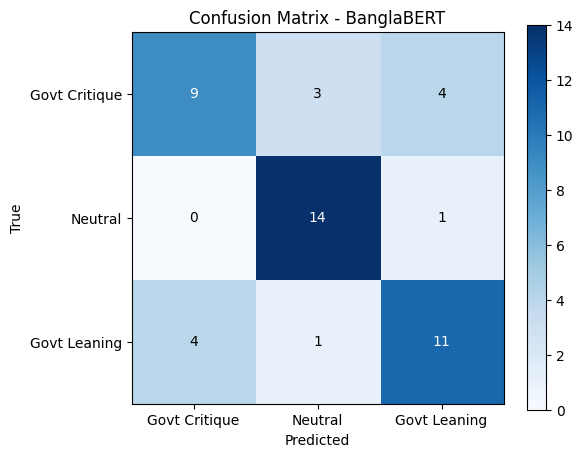

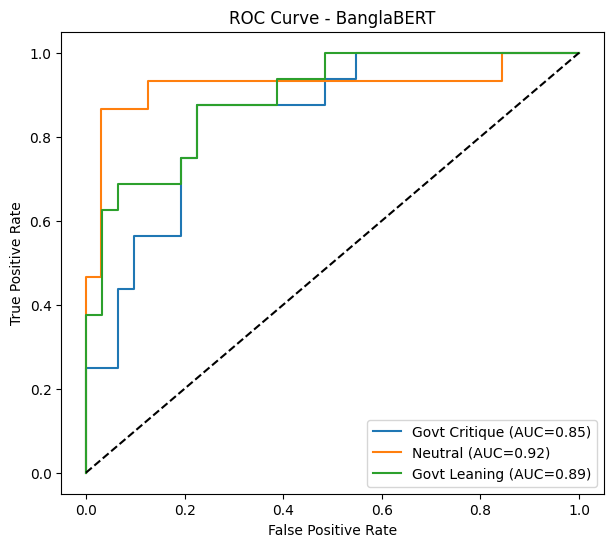

Predictions saved to: /content/drive/MyDrive/Political_Bias/BanglaBERT.csv


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from datasets import Dataset
from scipy.special import softmax

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['FINAL LABEL'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['FINAL LABEL'],
    random_state=42
)

print("Train/Val/Test sizes:", len(train_df), len(val_df), len(test_df))

model_name = "sagorsarker/bangla-bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

def tokenize(batch):
    return tokenizer(
        batch["Preprocessed_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("FINAL LABEL", "labels")
val_ds = val_ds.rename_column("FINAL LABEL", "labels")
test_ds = test_ds.rename_column("FINAL LABEL", "labels")

cols = ['input_ids', 'attention_mask', 'labels']
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Political_Bias/banglabert",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="/content/logs",
    logging_steps=50,
    fp16=True,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer)
)

trainer.train()

predictions = trainer.predict(test_ds)

logits = predictions.predictions
y_true = test_df['FINAL LABEL'].values
y_pred = np.argmax(logits, axis=1)
y_prob = softmax(logits, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='macro'))
print("Recall:", recall_score(y_true, y_pred, average='macro'))
print("F1 Score:", f1_score(y_true, y_pred, average='macro'))

print(classification_report(
    y_true,
    y_pred,
    target_names=["Govt Critique", "Neutral", "Govt Leaning"]
))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar()
classes = ["Govt Critique", "Neutral", "Govt Leaning"]
plt.xticks([0,1,2], classes)
plt.yticks([0,1,2], classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - BanglaBERT")

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.show()

y_true_bin = label_binarize(y_true, classes=[0,1,2])

plt.figure(figsize=(7,6))
for i, label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BanglaBERT")
plt.legend()
plt.show()

test_df['banglabert'] = y_pred
output_path = "/content/drive/MyDrive/Political_Bias/BanglaBERT.csv"
test_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Predictions saved to: {output_path}")

Train/Val/Test sizes: 218 47 47


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: monsoon-nlp/bangla-electra
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/218 [00:00<?, ? examples/s]

Map:   0%|          | 0/47 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

Accuracy: 0.46808510638297873
Precision: 0.4681818181818182
Recall: 0.46527777777777773
F1 Score: 0.4615384615384615
               precision    recall  f1-score   support

Govt Critique       0.45      0.56      0.50        16
      Neutral       0.45      0.33      0.38        15
 Govt Leaning       0.50      0.50      0.50        16

     accuracy                           0.47        47
    macro avg       0.47      0.47      0.46        47
 weighted avg       0.47      0.47      0.46        47



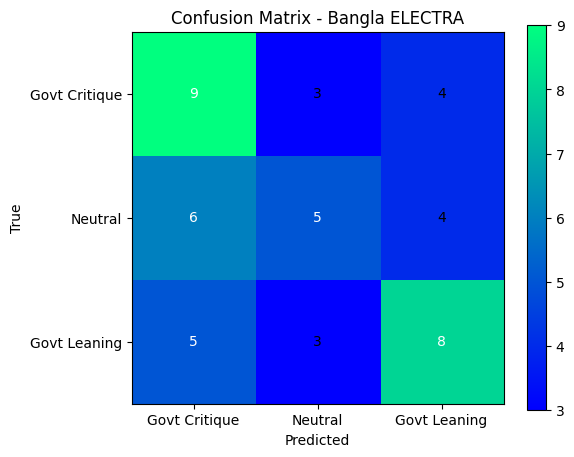

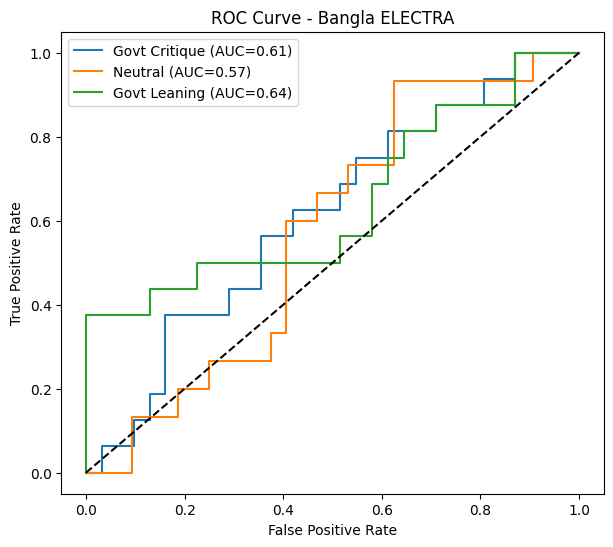

Predictions saved to: /content/drive/MyDrive/Political_Bias/BanglaELECTRA_Predictions.csv


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from datasets import Dataset
from scipy.special import softmax

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

# Train/Val/Test split
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['FINAL LABEL'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['FINAL LABEL'],
    random_state=42
)

print("Train/Val/Test sizes:", len(train_df), len(val_df), len(test_df))

# Model and tokenizer
model_name = "monsoon-nlp/bangla-electra"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

# Tokenization function
def tokenize(batch):
    return tokenizer(
        batch["Preprocessed_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

# Prepare datasets
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("FINAL LABEL", "labels")
val_ds = val_ds.rename_column("FINAL LABEL", "labels")
test_ds = test_ds.rename_column("FINAL LABEL", "labels")

cols = ['input_ids', 'attention_mask', 'labels']
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)

# Training arguments
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Political_Bias/bangla-electra",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="/content/logs",
    logging_steps=50,
    fp16=True,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer)
)

# Train
trainer.train()

# Predictions
predictions = trainer.predict(test_ds)
logits = predictions.predictions
y_true = test_df['FINAL LABEL'].values
y_pred = np.argmax(logits, axis=1)
y_prob = softmax(logits, axis=1)

# Metrics
classes = ["Govt Critique", "Neutral", "Govt Leaning"]
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='macro'))
print("Recall:", recall_score(y_true, y_pred, average='macro'))
print("F1 Score:", f1_score(y_true, y_pred, average='macro'))
print(classification_report(y_true, y_pred, target_names=classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap='winter')
plt.colorbar()
plt.xticks([0,1,2], classes)
plt.yticks([0,1,2], classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Bangla ELECTRA")
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.show()

# ROC Curve
y_true_bin = label_binarize(y_true, classes=[0,1,2])
plt.figure(figsize=(7,6))
for i, label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Bangla ELECTRA")
plt.legend()
plt.show()

# Save predictions
test_df['bangla_electra'] = y_pred
output_path = "/content/drive/MyDrive/Political_Bias/BanglaELECTRA_Predictions.csv"
test_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Predictions saved to: {output_path}")


Train/Val/Test sizes: 218 47 47


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Accuracy: 0.6382978723404256
Precision: 0.6734006734006734
Recall: 0.6388888888888888
F1 Score: 0.6485671191553545
               precision    recall  f1-score   support

Govt Critique       0.50      0.56      0.53        16
      Neutral       0.91      0.67      0.77        15
 Govt Leaning       0.61      0.69      0.65        16

     accuracy                           0.64        47
    macro avg       0.67      0.64      0.65        47
 weighted avg       0.67      0.64      0.65        47



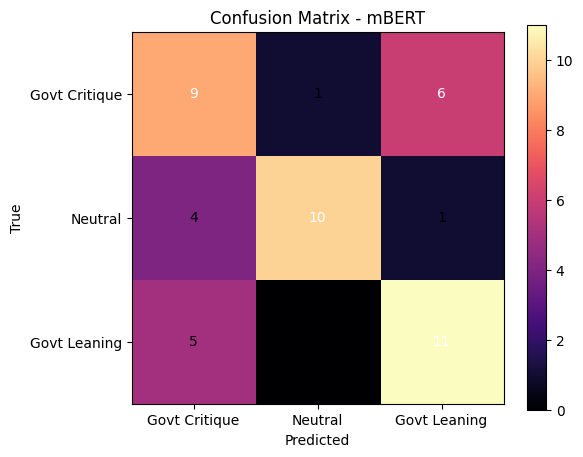

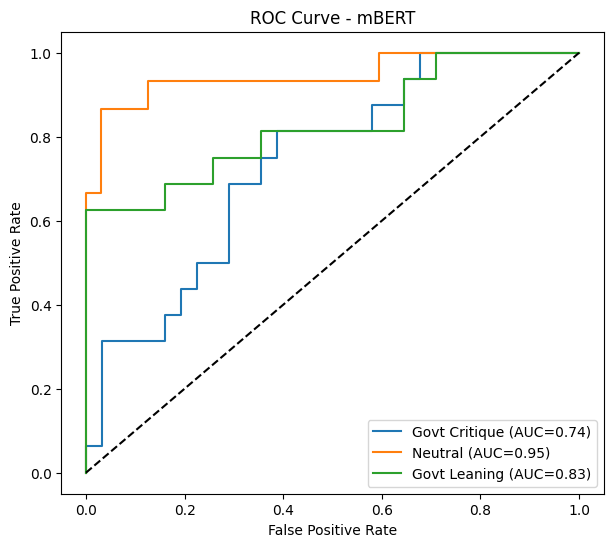

Predictions saved to: /content/drive/MyDrive/Political_Bias/mBERT_Predictions.csv


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from datasets import Dataset
from scipy.special import softmax

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['FINAL LABEL'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['FINAL LABEL'],
    random_state=42
)

print("Train/Val/Test sizes:", len(train_df), len(val_df), len(test_df))

model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

def tokenize(batch):
    return tokenizer(
        batch["Preprocessed_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("FINAL LABEL", "labels")
val_ds = val_ds.rename_column("FINAL LABEL", "labels")
test_ds = test_ds.rename_column("FINAL LABEL", "labels")

cols = ['input_ids', 'attention_mask', 'labels']
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Political_Bias/mbert",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="/content/logs",
    logging_steps=50,
    fp16=True,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer)
)

trainer.train()

predictions = trainer.predict(test_ds)

logits = predictions.predictions
y_true = test_df['FINAL LABEL'].values
y_pred = np.argmax(logits, axis=1)
y_prob = softmax(logits, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='macro'))
print("Recall:", recall_score(y_true, y_pred, average='macro'))
print("F1 Score:", f1_score(y_true, y_pred, average='macro'))

classes = ["Govt Critique", "Neutral", "Govt Leaning"]
print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap='magma')
plt.colorbar()
plt.xticks([0,1,2], classes)
plt.yticks([0,1,2], classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - mBERT")

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.show()

y_true_bin = label_binarize(y_true, classes=[0,1,2])
plt.figure(figsize=(7,6))
for i, label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - mBERT")
plt.legend()
plt.show()

test_df['mbert'] = y_pred
output_path = "/content/drive/MyDrive/Political_Bias/mBERT_Predictions.csv"
test_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Predictions saved to: {output_path}")


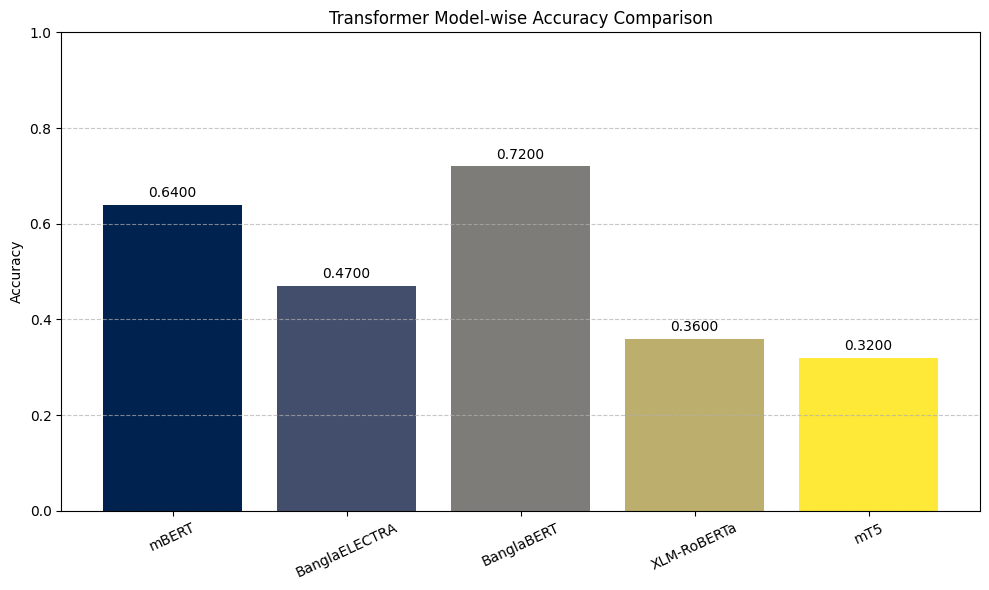

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "mBERT",
    "BanglaELECTRA",
    "BanglaBERT",
    "XLM-RoBERTa",
    "mT5"
]

accuracy = [
    0.64,
    0.47,
    0.72,
    0.36,
    0.32
]

colors = plt.cm.cividis(np.linspace(0, 1, len(models)))

plt.figure(figsize=(10,6))
bars = plt.bar(models, accuracy, color=colors)

plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Transformer Model-wise Accuracy Comparison")
plt.xticks(rotation=25)

plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar, acc in zip(bars, accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{acc:.4f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# **ML Models**

Accuracy: 0.7301587301587301
Precision: 0.7301587301587302
Recall: 0.7301587301587302
F1 Score: 0.7301587301587302


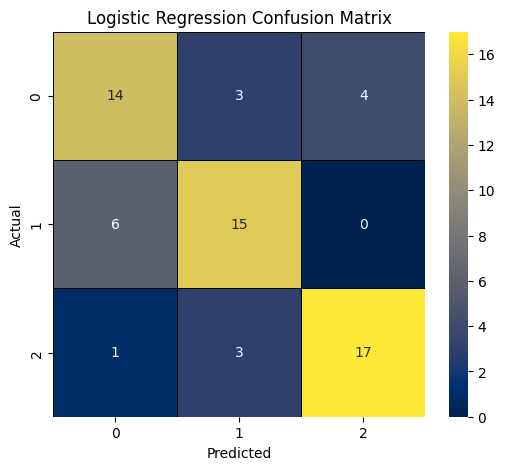

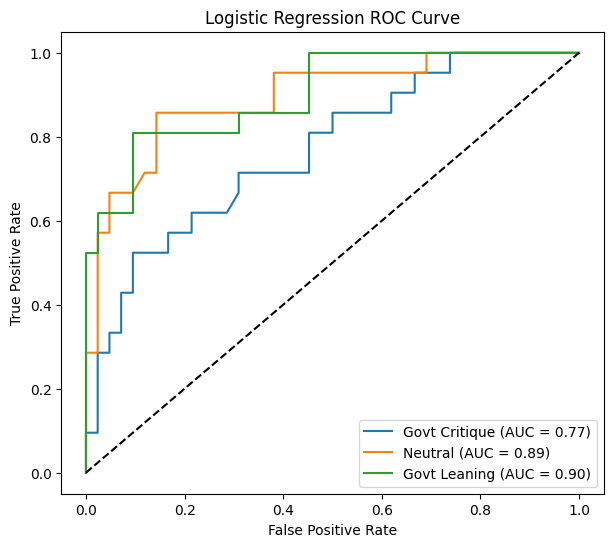

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

X = df["Preprocessed_Text"]
y = df["FINAL LABEL"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="cividis", linewidths=0.5, linecolor="black")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=[0,1,2])
clf = OneVsRestClassifier(LogisticRegression(max_iter=1000))
y_score = clf.fit(X_train_vec, y_train).predict_proba(X_test_vec)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
plt.plot(fpr[0], tpr[0], label="Govt Critique (AUC = %0.2f)" % roc_auc[0])
plt.plot(fpr[1], tpr[1], label="Neutral (AUC = %0.2f)" % roc_auc[1])
plt.plot(fpr[2], tpr[2], label="Govt Leaning (AUC = %0.2f)" % roc_auc[2])
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

Accuracy: 0.746031746031746
Precision: 0.7486291486291486
Recall: 0.746031746031746
F1 Score: 0.7470581350331775


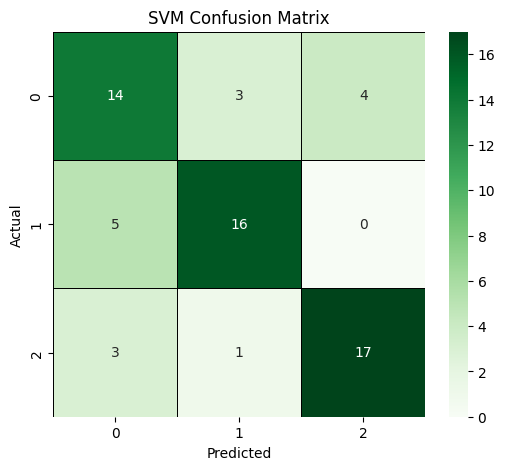

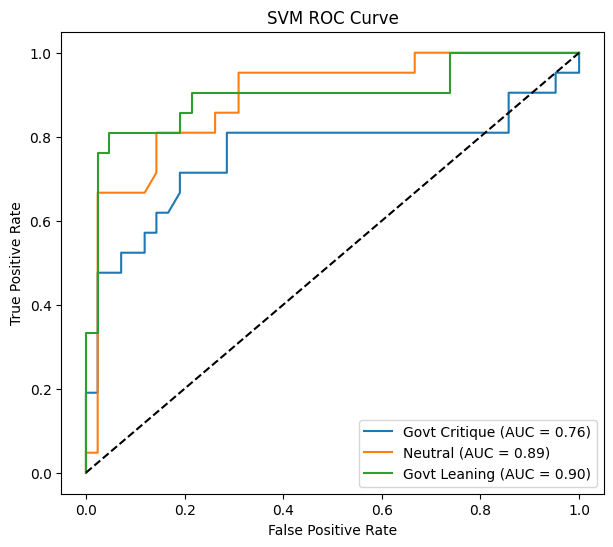

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

X = df["Preprocessed_Text"]
y = df["FINAL LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = SVC(kernel="linear", probability=True)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",linewidths=0.5, linecolor="black")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=[0,1,2])
clf = OneVsRestClassifier(SVC(kernel="linear", probability=True))
y_score = clf.fit(X_train_vec, y_train).predict_proba(X_test_vec)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
plt.plot(fpr[0], tpr[0], label="Govt Critique (AUC = %0.2f)" % roc_auc[0])
plt.plot(fpr[1], tpr[1], label="Neutral (AUC = %0.2f)" % roc_auc[1])
plt.plot(fpr[2], tpr[2], label="Govt Leaning (AUC = %0.2f)" % roc_auc[2])
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

Accuracy: 0.6825396825396826
Precision: 0.6881130141999708
Recall: 0.6825396825396824
F1 Score: 0.6832908693373808


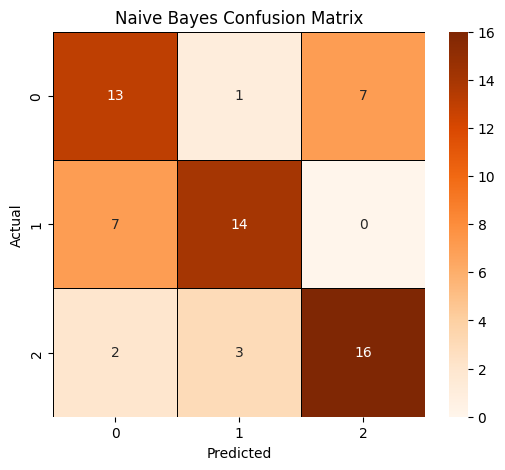

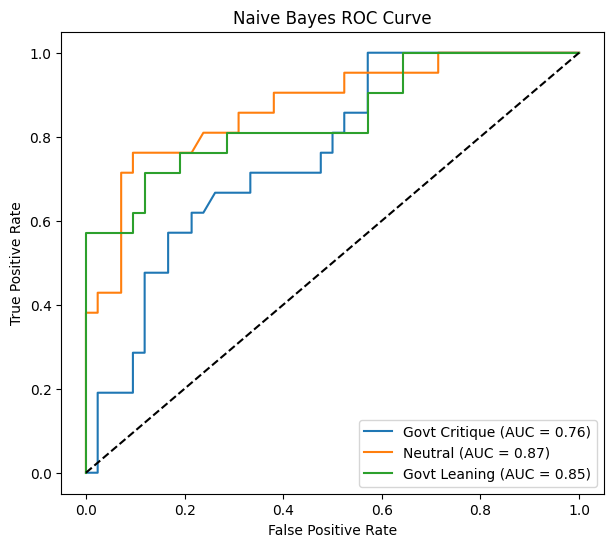

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

X = df["Preprocessed_Text"]
y = df["FINAL LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",linewidths=0.5, linecolor="black")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=[0,1,2])
clf = OneVsRestClassifier(MultinomialNB())
y_score = clf.fit(X_train_vec, y_train).predict_proba(X_test_vec)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
plt.plot(fpr[0], tpr[0], label="Govt Critique (AUC = %0.2f)" % roc_auc[0])
plt.plot(fpr[1], tpr[1], label="Neutral (AUC = %0.2f)" % roc_auc[1])
plt.plot(fpr[2], tpr[2], label="Govt Leaning (AUC = %0.2f)" % roc_auc[2])
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes ROC Curve")
plt.legend()
plt.show()

Accuracy: 0.6666666666666666
Precision: 0.6608391608391608
Recall: 0.6666666666666666
F1 Score: 0.6422872340425533


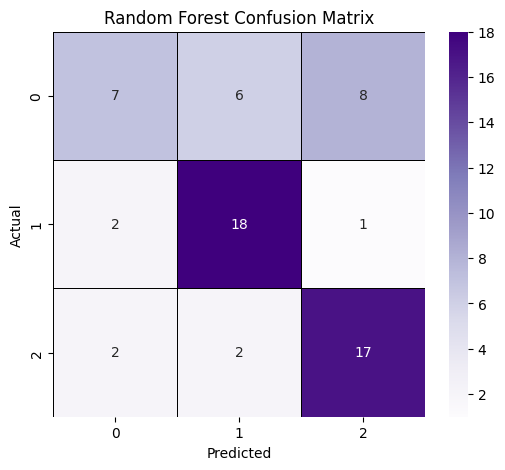

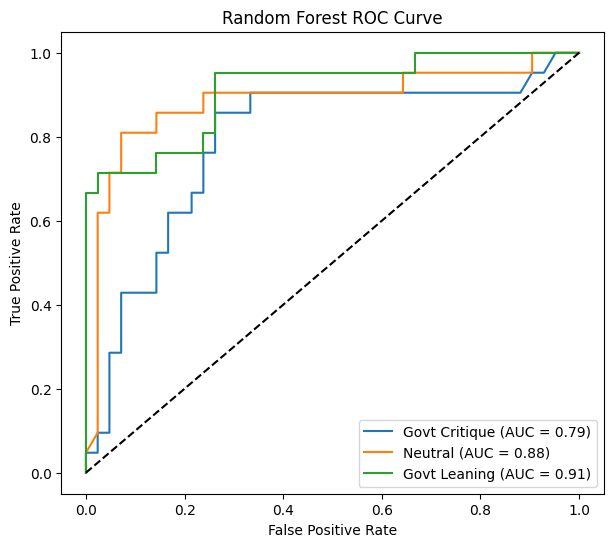

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

X = df["Preprocessed_Text"]
y = df["FINAL LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",linewidths=0.5, linecolor="black")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=[0,1,2])
clf = OneVsRestClassifier(RandomForestClassifier(n_estimators=300, random_state=42))
y_score = clf.fit(X_train_vec, y_train).predict_proba(X_test_vec)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
plt.plot(fpr[0], tpr[0], label="Govt Critique (AUC = %0.2f)" % roc_auc[0])
plt.plot(fpr[1], tpr[1], label="Neutral (AUC = %0.2f)" % roc_auc[1])
plt.plot(fpr[2], tpr[2], label="Govt Leaning (AUC = %0.2f)" % roc_auc[2])
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

Accuracy: 0.7301587301587301
Precision: 0.7240596226103472
Recall: 0.7301587301587302
F1 Score: 0.7118241235888295


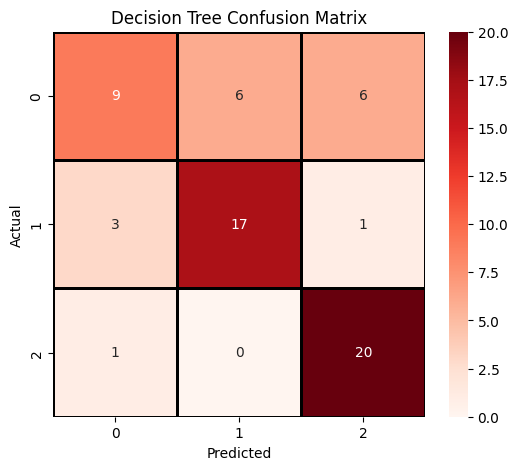

/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:557: RuntimeWarning: invalid value encountered in divide
  Y /= np.sum(Y, axis=1)[:, np.newaxis]


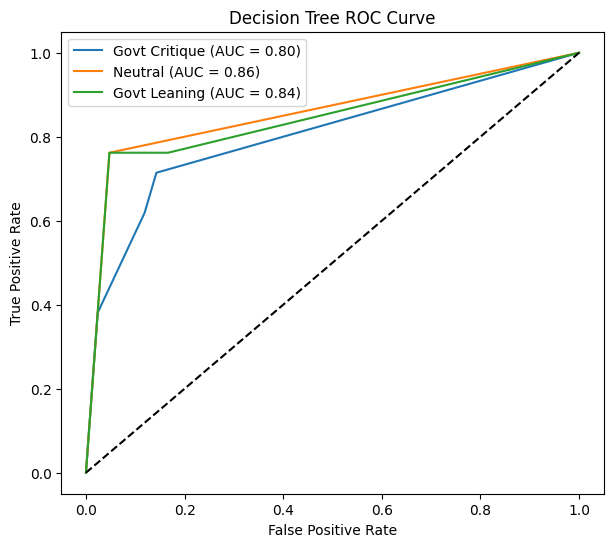

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

X = df["Preprocessed_Text"]
y = df["FINAL LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",linewidths=0.75, linecolor="black")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=[0,1,2])
clf = OneVsRestClassifier(DecisionTreeClassifier(random_state=42))
y_score = clf.fit(X_train_vec, y_train).predict_proba(X_test_vec)
y_score = np.nan_to_num(y_score, nan=0.0)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
plt.plot(fpr[0], tpr[0], label="Govt Critique (AUC = %0.2f)" % roc_auc[0])
plt.plot(fpr[1], tpr[1], label="Neutral (AUC = %0.2f)" % roc_auc[1])
plt.plot(fpr[2], tpr[2], label="Govt Leaning (AUC = %0.2f)" % roc_auc[2])
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

Accuracy: 0.4603174603174603
Precision: 0.6346031746031745
Recall: 0.4603174603174603
F1 Score: 0.4200263308244529


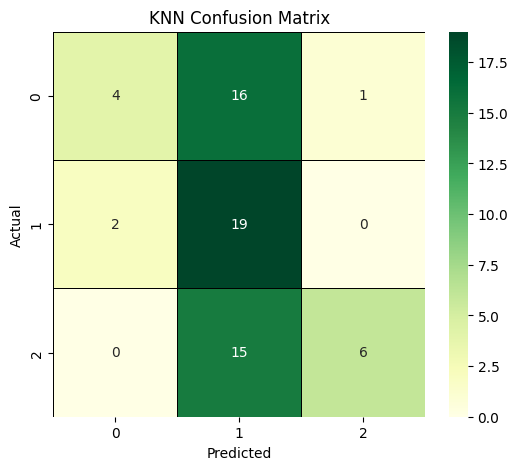

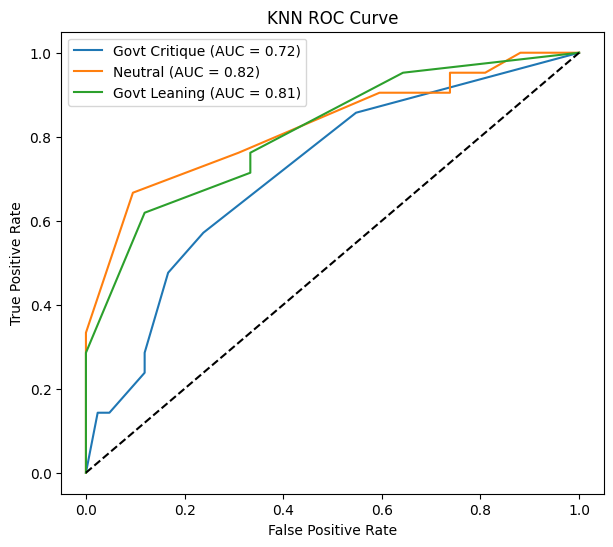

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

X = df["Preprocessed_Text"]
y = df["FINAL LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = KNeighborsClassifier(n_neighbors=7)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGn",linewidths=0.5, linecolor="black")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=[0,1,2])
clf = OneVsRestClassifier(KNeighborsClassifier(n_neighbors=7))
y_score = clf.fit(X_train_vec, y_train).predict_proba(X_test_vec)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
plt.plot(fpr[0], tpr[0], label="Govt Critique (AUC = %0.2f)" % roc_auc[0])
plt.plot(fpr[1], tpr[1], label="Neutral (AUC = %0.2f)" % roc_auc[1])
plt.plot(fpr[2], tpr[2], label="Govt Leaning (AUC = %0.2f)" % roc_auc[2])
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.show()

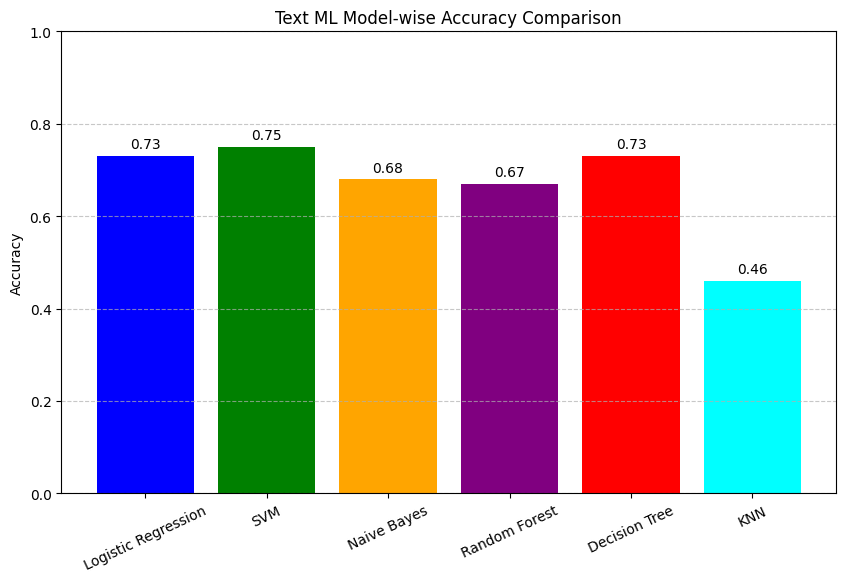

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "SVM",
    "Naive Bayes",
    "Random Forest",
    "Decision Tree",
    "KNN"
]

accuracy = [
    0.73,
    0.75,
    0.68,
    0.67,
    0.73,
    0.46
]

plt.figure(figsize=(10,6))
bars = plt.bar(models, accuracy, color=["blue", "green", "orange", "purple", "red", "cyan"])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Text ML Model-wise Accuracy Comparison")
plt.xticks(rotation=25)

plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar, acc in zip(bars, accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{acc:.2f}", ha='center', va='bottom')

plt.show()

# **Images**

In [ ]:
!pip install imagehash
!pip install pillow-avif-plugin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 32.7 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import imagehash

input_csv_path = "/content/drive/MyDrive/Political_Bias/Final_Dataset.csv"
input_image_folder = "/content/drive/MyDrive/Political_Bias/images"
output_image_folder = "/content/drive/MyDrive/Political_Bias/processed_images"
output_csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"

os.makedirs(output_image_folder, exist_ok=True)

df = pd.read_csv(input_csv_path)

hashes = {}
new_data = []

MIN_WIDTH = 100
MIN_HEIGHT = 100

for _, row in tqdm(df.iterrows(), total=len(df)):
    image_id = str(row["Image_id"]).strip()
    final_label = row["FINAL LABEL"]

    image_path = None
    for ext in [".jpg", ".jpeg", ".png", ".webp", ".avif"]:
        temp_path = os.path.join(input_image_folder, image_id + ext)
        if os.path.exists(temp_path):
            image_path = temp_path
            break

    if image_path is None:
        continue

    try:
        img = Image.open(image_path)
    except:
        continue

    if img.width < MIN_WIDTH or img.height < MIN_HEIGHT:
        continue

    try:
        img = img.convert("RGB")
    except:
        continue

    try:
        img_hash = imagehash.phash(img)
        if img_hash in hashes:
            continue
        hashes[img_hash] = image_id
    except:
        continue

    img.thumbnail((256, 256), Image.LANCZOS)

    new_img = Image.new("RGB", (256, 256), (0, 0, 0))
    new_img.paste(
        img,
        ((256 - img.width) // 2, (256 - img.height) // 2)
    )

    new_image_path = os.path.join(output_image_folder, image_id + ".jpg")
    new_img.save(new_image_path, "JPEG", quality=95)

    new_data.append([image_id, new_image_path, final_label])

new_df = pd.DataFrame(new_data, columns=["Image_id", "Image_Path", "Final_Label"])
new_df.to_csv(output_csv_path, index=False)

print("Preprocessing completed.")
print("Saved at:", output_csv_path)

100%|██████████| 198/198 [01:12<00:00,  2.73it/s]

Preprocessing completed.
Saved at: /content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv



--- Fold 1 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.4000, Precision: 0.2308, Recall: 0.4000, F1-score: 0.2927


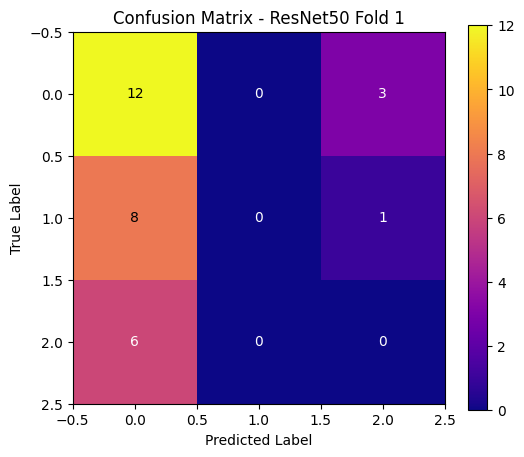

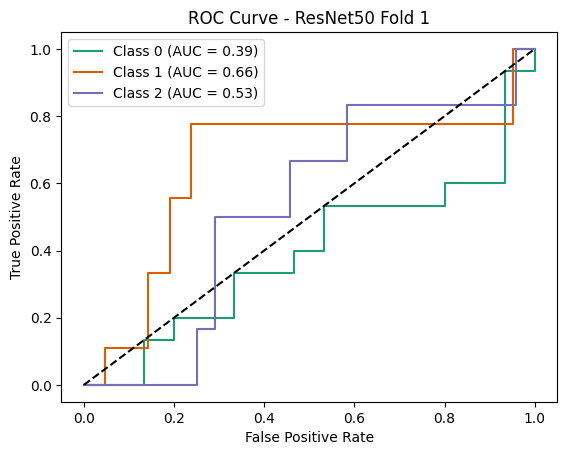


--- Fold 2 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.4000, Precision: 0.3953, Recall: 0.4000, F1-score: 0.3944


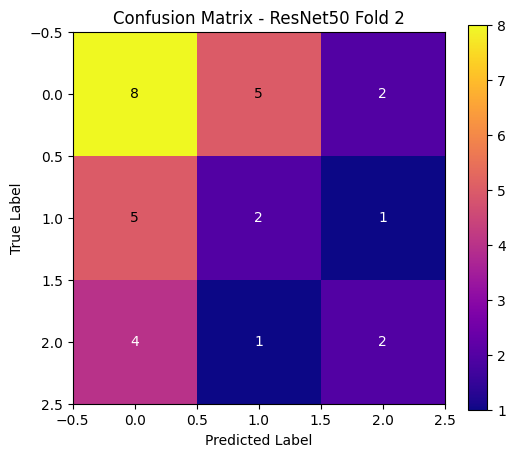

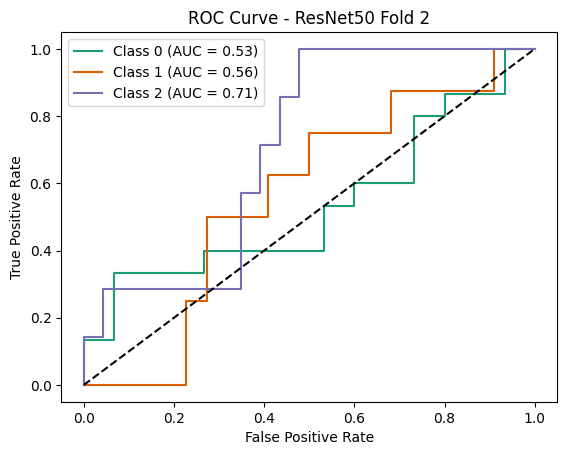


--- Fold 3 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.3333, Precision: 0.3844, Recall: 0.3333, F1-score: 0.3313


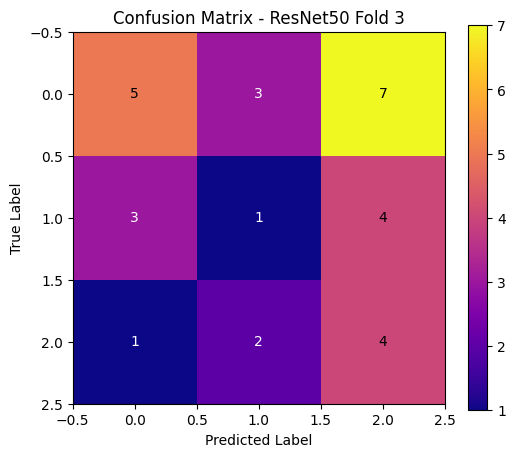

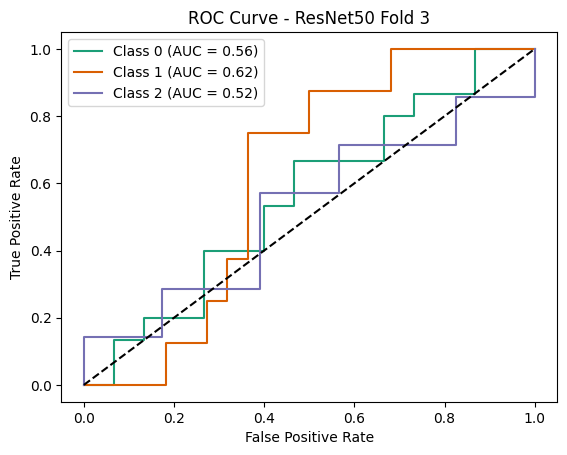


--- Fold 4 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.4667, Precision: 0.4212, Recall: 0.4667, F1-score: 0.4404


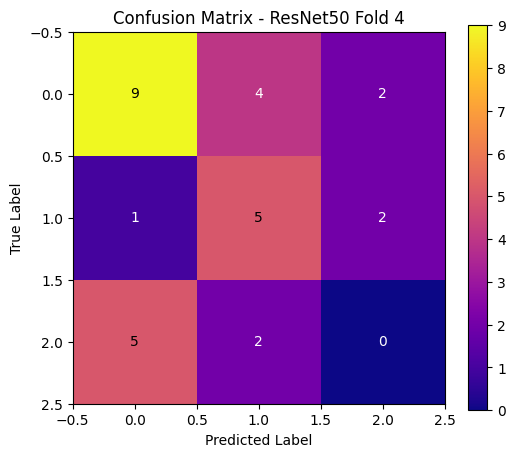

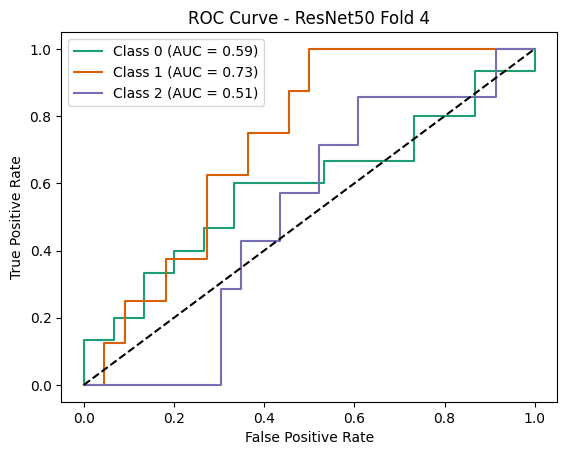


--- Fold 5 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.4138, Precision: 0.4261, Recall: 0.4138, F1-score: 0.4059


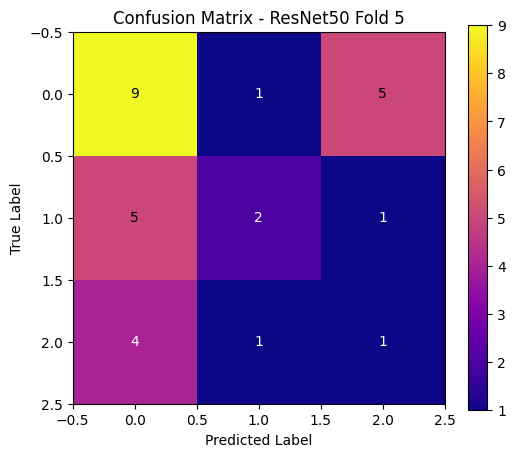

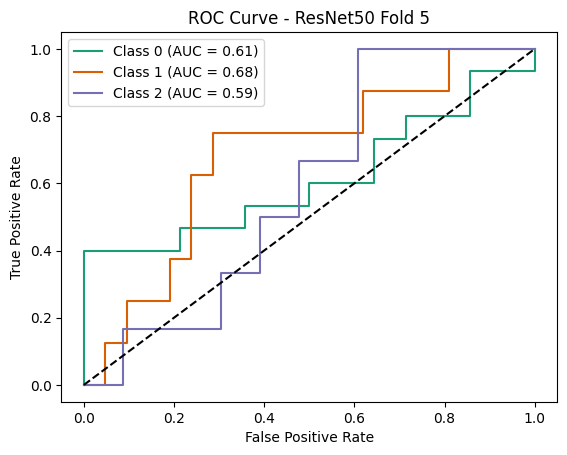


--- K-Fold Summary ---
Average Accuracy: 0.4028
Average Precision: 0.3716
Average Recall: 0.4028
Average F1-score: 0.3729


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from torchvision import transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = CustomDataset(df, transform)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

X = df["Image_Path"]
y = df["Final_Label"]

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
acc_list, precision_list, recall_list, f1_list = [], [], [], []

for train_idx, test_idx in kfold.split(X, y):
    print(f"\n--- Fold {fold} ---")

    train_subset = Subset(dataset, train_idx)
    test_subset = Subset(dataset, test_idx)

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=16, shuffle=False)

    model = models.resnet50(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 3)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    epochs = 10
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")

    acc_list.append(acc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='plasma')
    plt.title(f"Confusion Matrix - ResNet50 Fold {fold}")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i,j]),
                     ha='center', va='center', color='black' if cm[i,j]>cm.max()/2 else 'white')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    y_test_bin = label_binarize(all_labels, classes=[0,1,2])
    all_probs = np.array(all_probs)

    plt.figure()
    colors = ['#1b9e77', '#d95f02', '#7570b3']
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - ResNet50 Fold {fold}")
    plt.legend()
    plt.show()

    fold += 1

print("\n--- K-Fold Summary ---")
print(f"Average Accuracy: {np.mean(acc_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1-score: {np.mean(f1_list):.4f}")


--- Fold 1 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.3667, Precision: 0.3643, Recall: 0.3667, F1-score: 0.3612


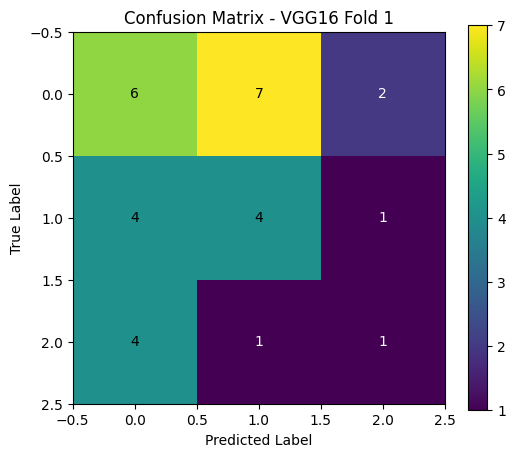

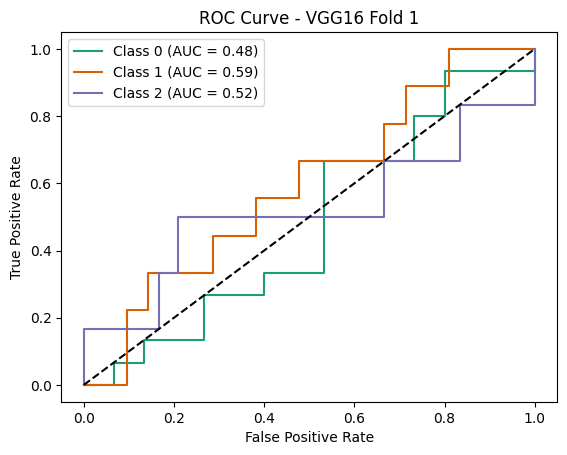


--- Fold 2 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.4333, Precision: 0.5426, Recall: 0.4333, F1-score: 0.4068


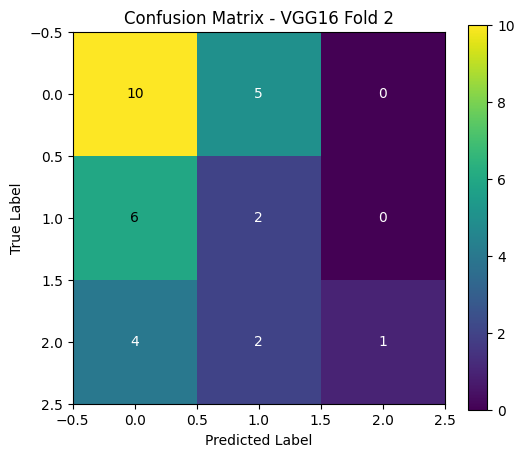

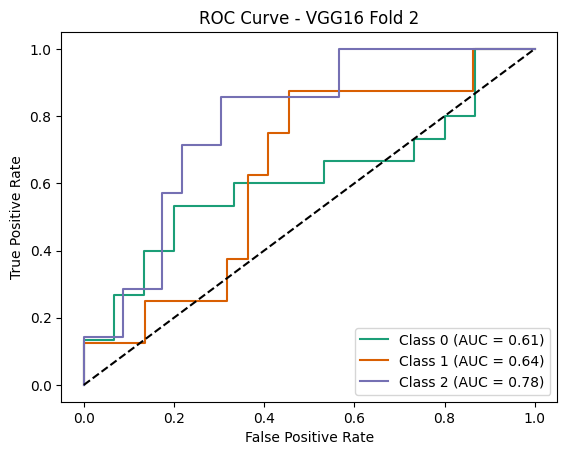


--- Fold 3 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.6000, Precision: 0.5932, Recall: 0.6000, F1-score: 0.5506


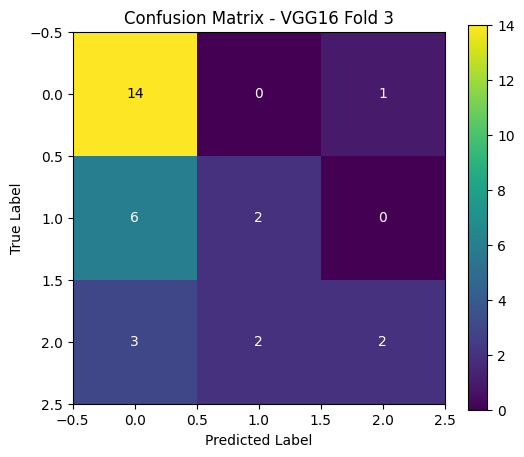

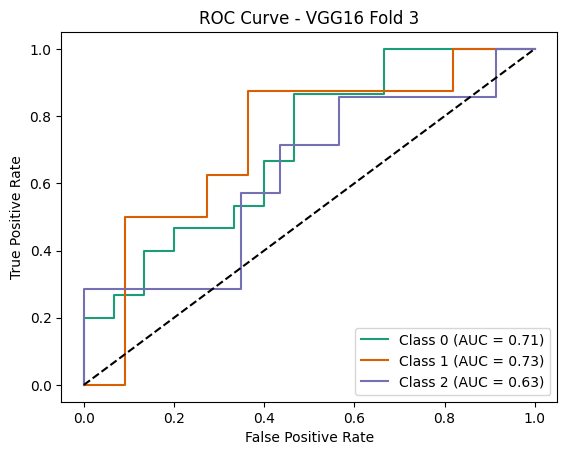


--- Fold 4 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.1667, Precision: 0.2186, Recall: 0.1667, F1-score: 0.1810


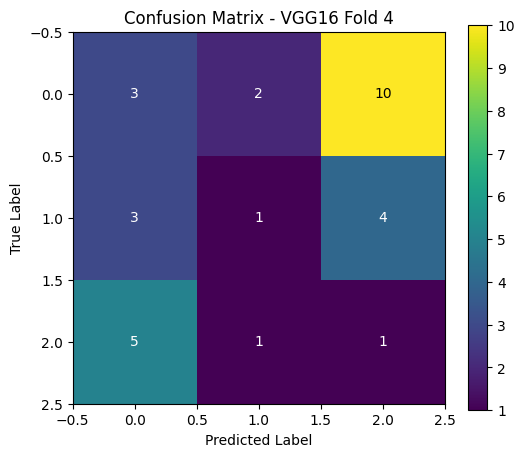

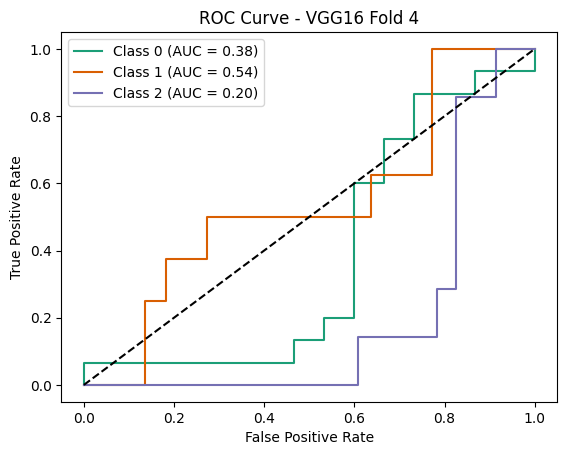


--- Fold 5 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.3448, Precision: 0.4181, Recall: 0.3448, F1-score: 0.3361


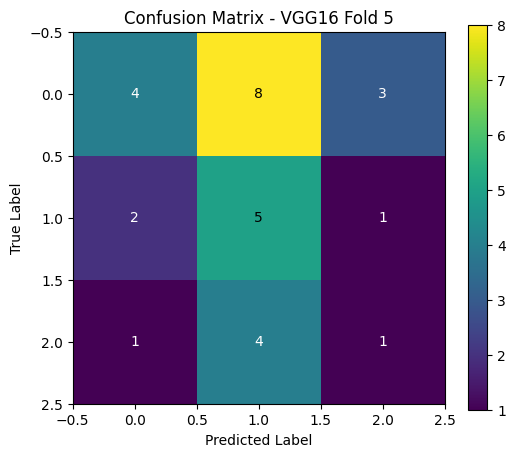

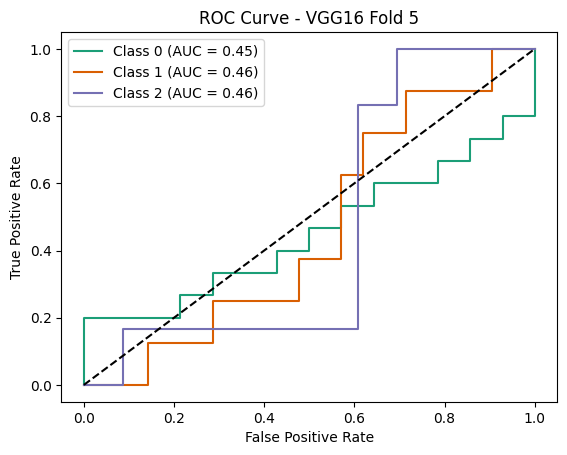


--- 5-Fold Summary ---
Average Accuracy: 0.3823
Average Precision: 0.4274
Average Recall: 0.3823
Average F1-score: 0.3671


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from torchvision import transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = CustomDataset(df, transform)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

X = df["Image_Path"]
y = df["Final_Label"]
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
acc_list, precision_list, recall_list, f1_list = [], [], [], []

for train_idx, test_idx in kfold.split(X, y):
    print(f"\n--- Fold {fold} ---")

    train_subset = Subset(dataset, train_idx)
    test_subset = Subset(dataset, test_idx)

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=16, shuffle=False)

    model = models.vgg16(pretrained=True)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, 3)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    epochs = 10
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")

    acc_list.append(acc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='viridis')
    plt.title(f"Confusion Matrix - VGG16 Fold {fold}")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i,j]),
                     ha='center', va='center', color='black' if cm[i,j]>cm.max()/2 else 'white')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    y_test_bin = label_binarize(all_labels, classes=[0,1,2])
    all_probs = np.array(all_probs)
    plt.figure()
    colors = ['#1b9e77', '#d95f02', '#7570b3']
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - VGG16 Fold {fold}")
    plt.legend()
    plt.show()

    fold += 1

print("\n--- 5-Fold Summary ---")
print(f"Average Accuracy: {np.mean(acc_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1-score: {np.mean(f1_list):.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Fold 1
Accuracy: 0.2333, Precision: 0.2083, Recall: 0.2333, F1-score: 0.1911


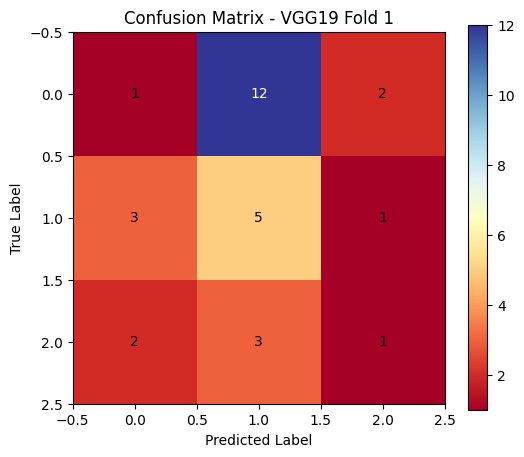

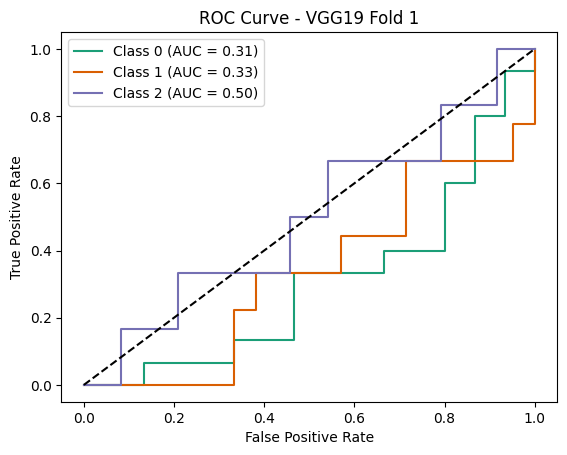

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Fold 2
Accuracy: 0.4333, Precision: 0.5130, Recall: 0.4333, F1-score: 0.4069


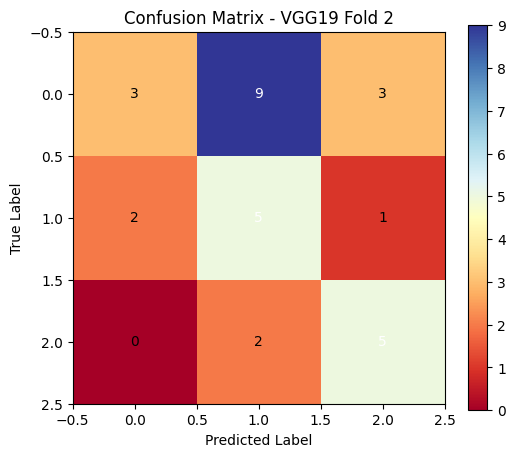

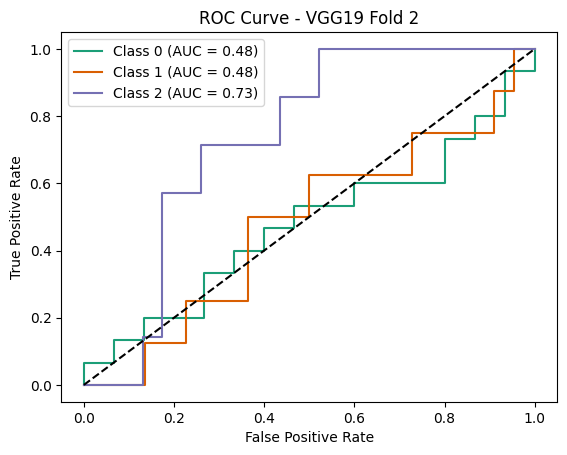

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Fold 3
Accuracy: 0.5000, Precision: 0.4941, Recall: 0.5000, F1-score: 0.4935


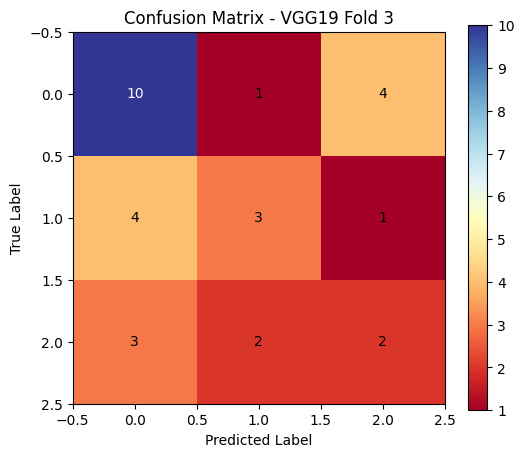

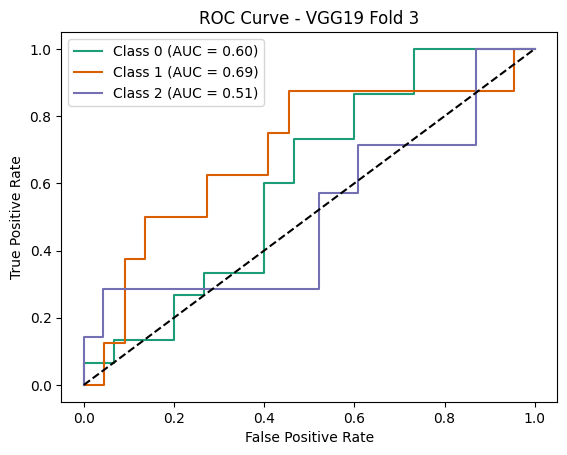

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Fold 4
Accuracy: 0.4667, Precision: 0.3467, Recall: 0.4667, F1-score: 0.3821


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


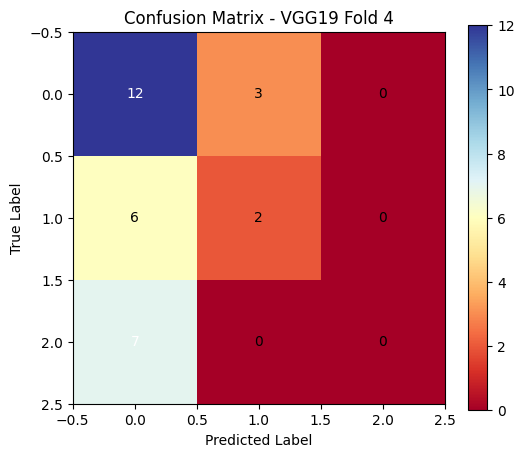

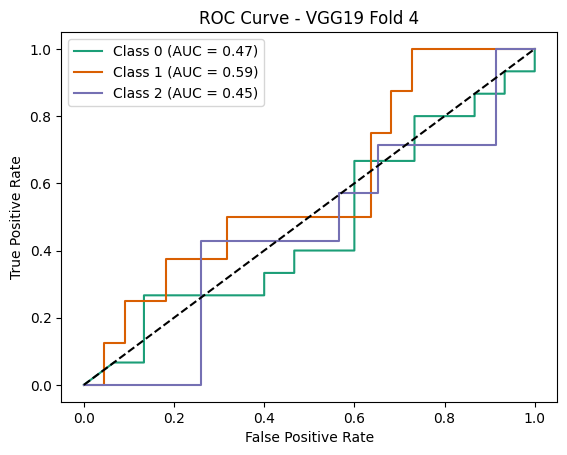

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Fold 5
Accuracy: 0.3448, Precision: 0.2746, Recall: 0.3448, F1-score: 0.3057


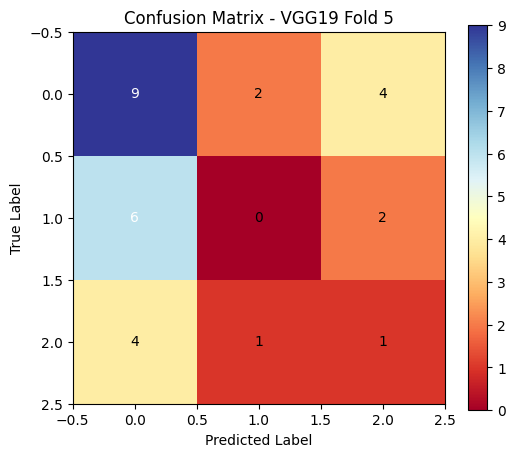

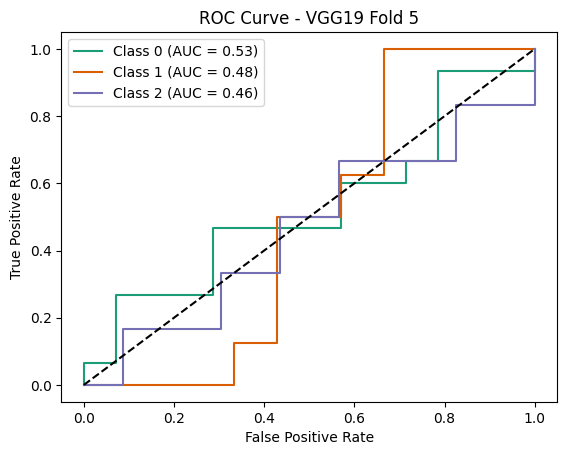


5-Fold Summary
Average Accuracy: 0.3956
Average Precision: 0.3673
Average Recall: 0.3956
Average F1-score: 0.3558


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = CustomDataset(df, transform)
class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)
X = df["Image_Path"]
y = df["Final_Label"]
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
acc_list, precision_list, recall_list, f1_list = [], [], [], []

for train_idx, test_idx in kfold.split(X, y):
    train_subset = Subset(dataset, train_idx)
    test_subset = Subset(dataset, test_idx)
    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=16, shuffle=False)

    model = models.vgg19(pretrained=True)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, 3)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    epochs = 10

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    acc_list.append(acc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

    print(f"\nFold {fold}")
    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='RdYlBu')
    plt.title(f"Confusion Matrix - VGG19 Fold {fold}")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i,j]),
                     ha='center', va='center', color='white' if cm[i,j]>cm.max()/2 else 'black')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    y_test_bin = label_binarize(all_labels, classes=[0,1,2])
    all_probs = np.array(all_probs)
    plt.figure()
    colors = ['#1b9e77', '#d95f02', '#7570b3']
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - VGG19 Fold {fold}")
    plt.legend()
    plt.show()

    fold += 1

print("\n5-Fold Summary")
print(f"Average Accuracy: {np.mean(acc_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1-score: {np.mean(f1_list):.4f}")


Fold 1
Accuracy: 0.5000, Precision: 0.5098, Recall: 0.5000, F1-score: 0.4894


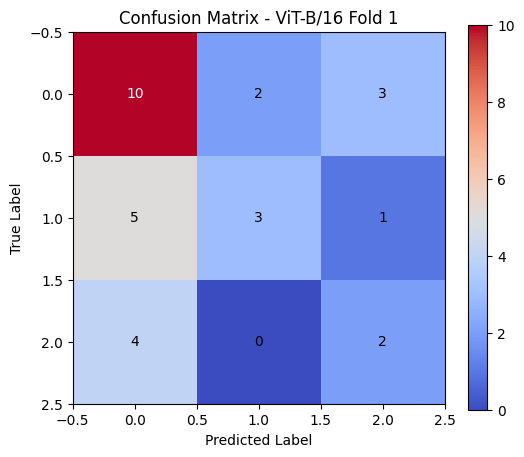

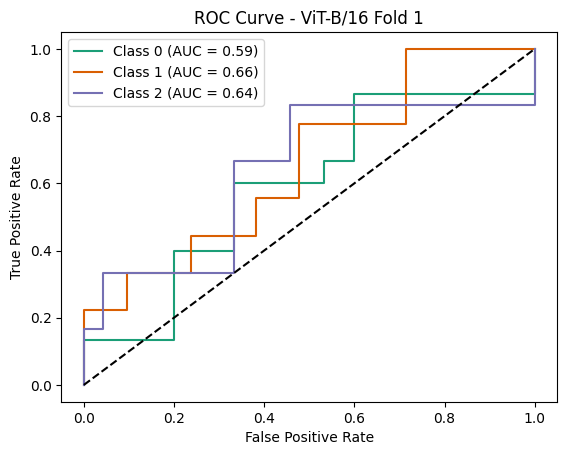


Fold 2
Accuracy: 0.4333, Precision: 0.3967, Recall: 0.4333, F1-score: 0.4045


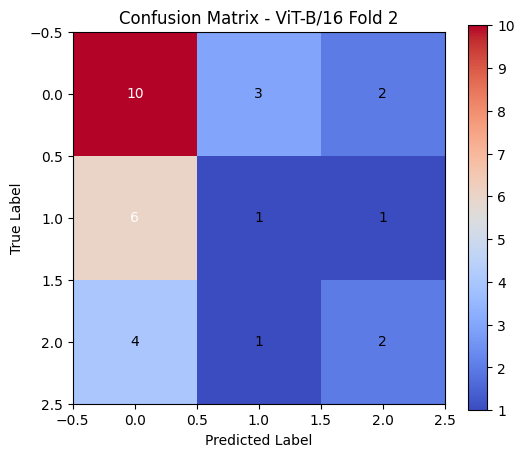

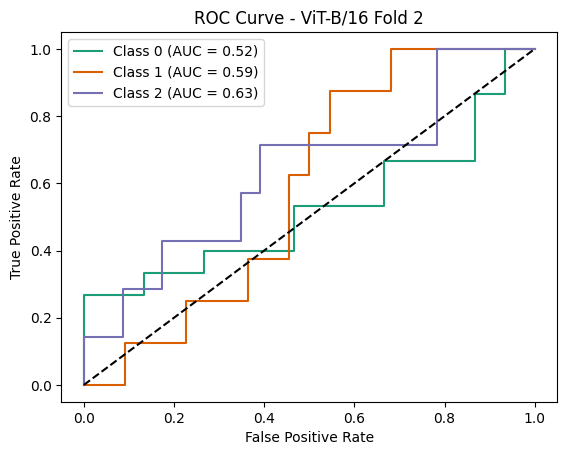


Fold 3
Accuracy: 0.5667, Precision: 0.5502, Recall: 0.5667, F1-score: 0.5549


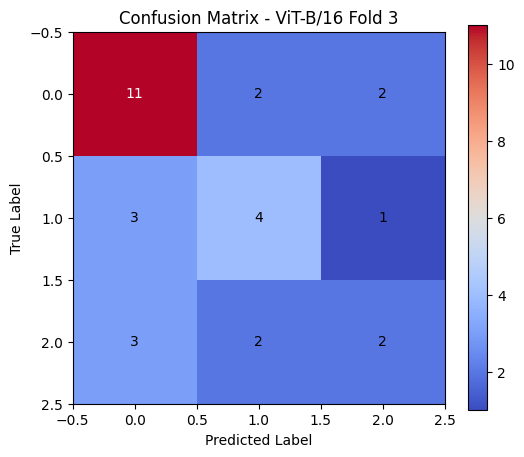

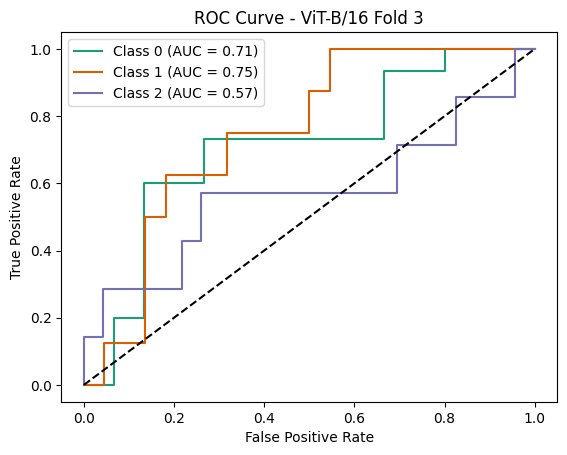


Fold 4
Accuracy: 0.4667, Precision: 0.3489, Recall: 0.4667, F1-score: 0.3735


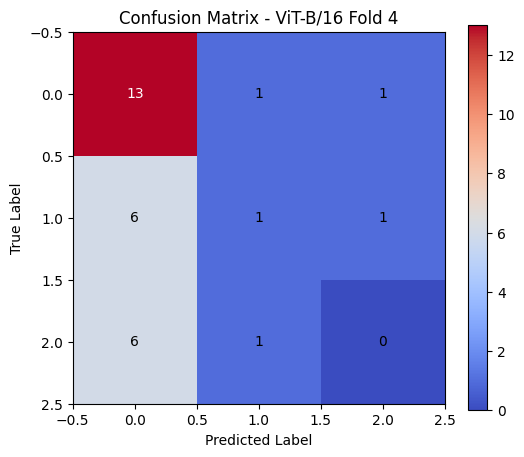

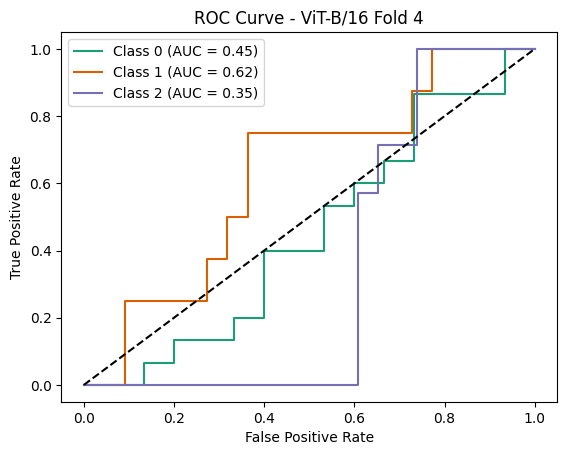


Fold 5
Accuracy: 0.5172, Precision: 0.5162, Recall: 0.5172, F1-score: 0.5141


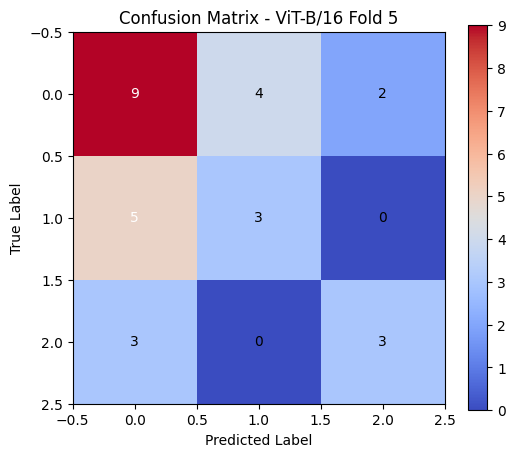

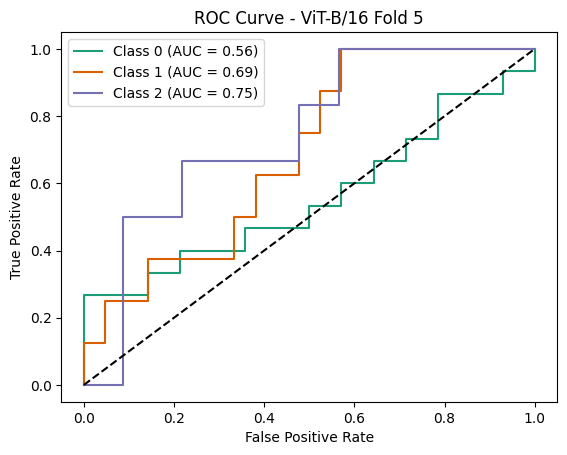


5-Fold Summary
Average Accuracy: 0.4968
Average Precision: 0.4644
Average Recall: 0.4968
Average F1-score: 0.4673


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from torchvision.models import vit_b_16, ViT_B_16_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

weights = ViT_B_16_Weights.DEFAULT
transform = weights.transforms()
dataset = CustomDataset(df, transform)
class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)
X = df["Image_Path"]
y = df["Final_Label"]
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
acc_list, precision_list, recall_list, f1_list = [], [], [], []

for train_idx, test_idx in kfold.split(X, y):
    train_subset = Subset(dataset, train_idx)
    test_subset = Subset(dataset, test_idx)
    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=16, shuffle=False)

    model = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
    model.heads.head = nn.Linear(model.heads.head.in_features, 3)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    epochs = 10

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    acc_list.append(acc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

    print(f"\nFold {fold}")
    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='coolwarm')
    plt.title(f"Confusion Matrix - ViT-B/16 Fold {fold}")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i,j]),
                     ha='center', va='center', color='white' if cm[i,j]>cm.max()/2 else 'black')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    y_test_bin = label_binarize(all_labels, classes=[0,1,2])
    all_probs = np.array(all_probs)
    plt.figure()
    colors = ['#1b9e77', '#d95f02', '#7570b3']
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - ViT-B/16 Fold {fold}")
    plt.legend()
    plt.show()

    fold += 1

print("\n5-Fold Summary")
print(f"Average Accuracy: {np.mean(acc_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1-score: {np.mean(f1_list):.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Fold 1
Accuracy: 0.3667, Precision: 0.3394, Recall: 0.3667, F1-score: 0.3468


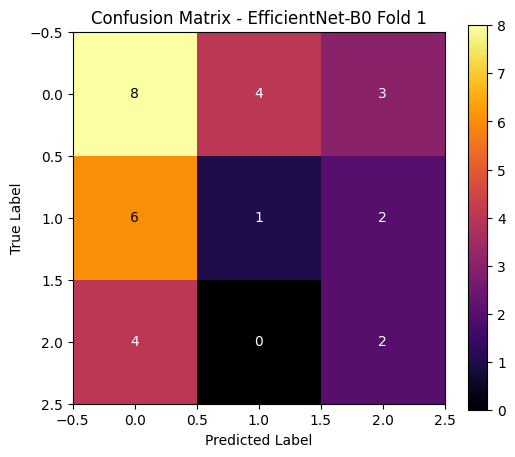

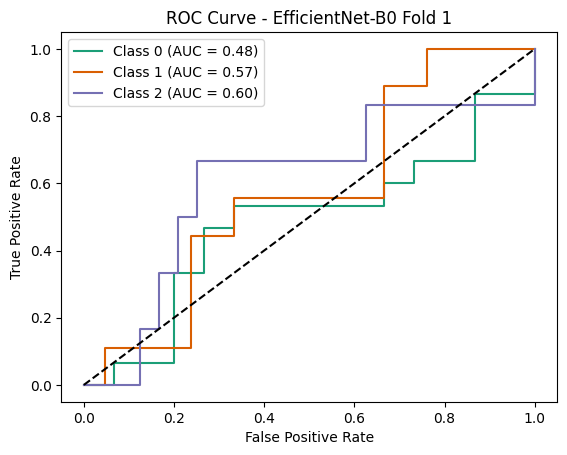

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Fold 2
Accuracy: 0.4667, Precision: 0.4332, Recall: 0.4667, F1-score: 0.4428


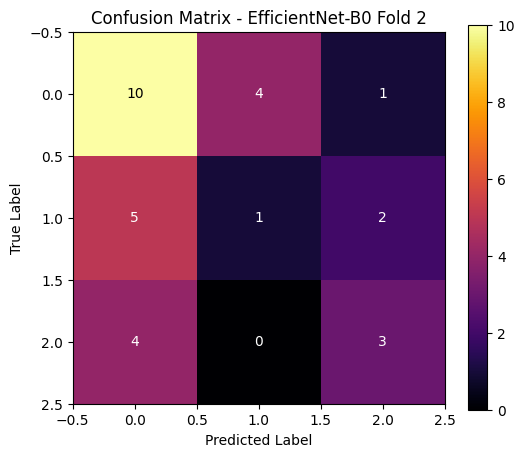

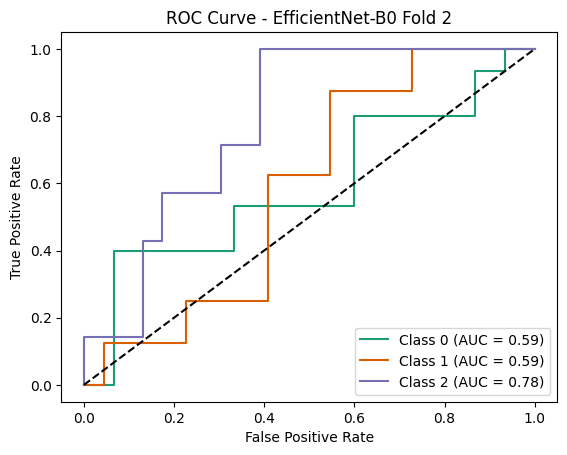

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Fold 3
Accuracy: 0.4667, Precision: 0.4667, Recall: 0.4667, F1-score: 0.4667


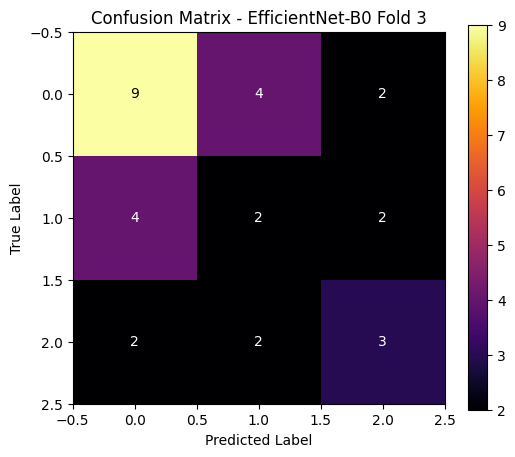

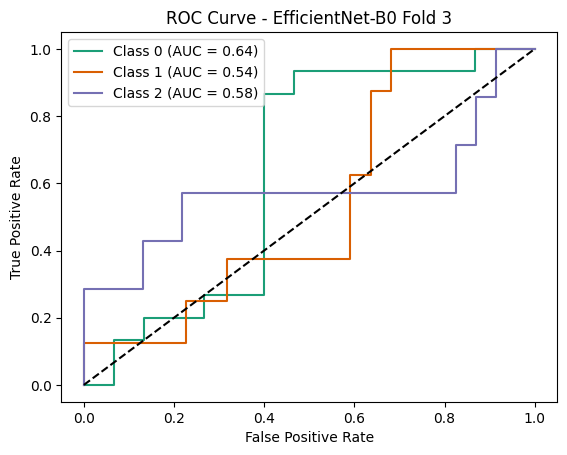

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Fold 4
Accuracy: 0.4000, Precision: 0.3511, Recall: 0.4000, F1-score: 0.3714


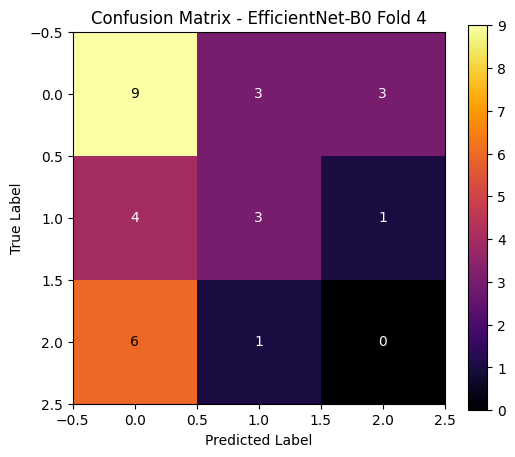

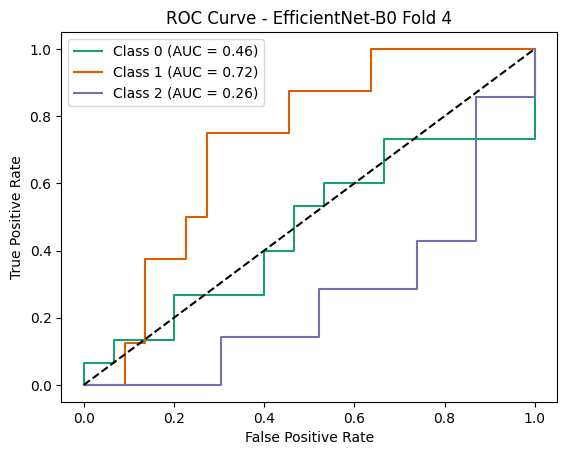

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Fold 5
Accuracy: 0.3448, Precision: 0.3498, Recall: 0.3448, F1-score: 0.3467


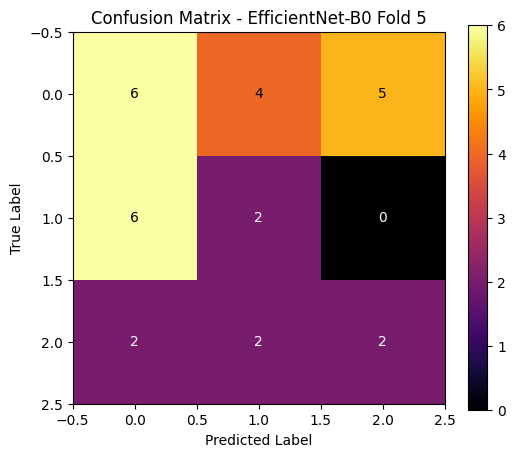

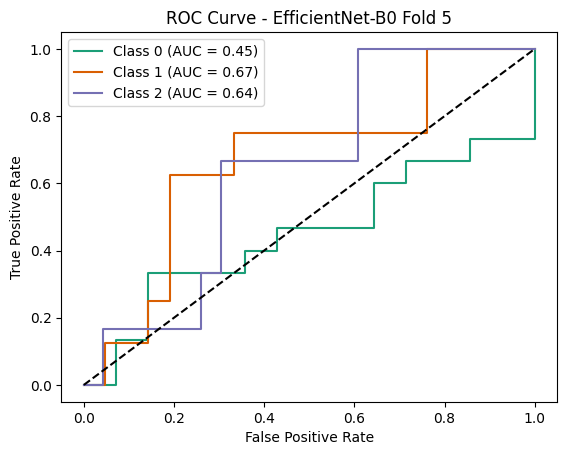


5-Fold Summary
Average Accuracy: 0.4090
Average Precision: 0.3880
Average Recall: 0.4090
Average F1-score: 0.3949


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from torchvision import transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
dataset = CustomDataset(df, transform)
class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)
X = df["Image_Path"]
y = df["Final_Label"]
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
acc_list, precision_list, recall_list, f1_list = [], [], [], []

for train_idx, test_idx in kfold.split(X, y):
    train_subset = Subset(dataset, train_idx)
    test_subset = Subset(dataset, test_idx)
    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=16, shuffle=False)

    model = models.efficientnet_b0(pretrained=True)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    epochs = 10

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    acc_list.append(acc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

    print(f"\nFold {fold}")
    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='inferno')
    plt.title(f"Confusion Matrix - EfficientNet-B0 Fold {fold}")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i,j]),
                     ha='center', va='center', color='black' if cm[i,j]>cm.max()/2 else 'white')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    y_test_bin = label_binarize(all_labels, classes=[0,1,2])
    all_probs = np.array(all_probs)
    plt.figure()
    colors = ['#1b9e77', '#d95f02', '#7570b3']
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - EfficientNet-B0 Fold {fold}")
    plt.legend()
    plt.show()

    fold += 1

print("\n5-Fold Summary")
print(f"Average Accuracy: {np.mean(acc_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1-score: {np.mean(f1_list):.4f}")

In [ ]:
!git clone https://github.com/google-research/big_transfer.git

fatal: destination path 'big_transfer' already exists and is not an empty directory.


In [ ]:
import sys
sys.path.append("/content/big_transfer")

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from torchvision import transforms
from big_transfer.benchmarks.imagenet2012 import models as bit_models
from big_transfer.checkpoint import load as load_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = CustomDataset(df, transform)
class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)
X = df["Image_Path"]
y = df["Final_Label"]
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
acc_list, precision_list, recall_list, f1_list = [], [], [], []

for train_idx, test_idx in kfold.split(X, y):
    train_subset = Subset(dataset, train_idx)
    test_subset = Subset(dataset, test_idx)
    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=16, shuffle=False)

    model = bit_models.ResNetV2('BiT-M-R50x1', heads=3)
    load_checkpoint(model, "BiT-M-R50x1", head_size=3)

    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    epochs = 10
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    acc_list.append(acc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

    print(f"\nFold {fold}")
    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='GnBu')
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i,j]),
                     ha='center', va='center', color='white' if cm[i,j]>cm.max()/2 else 'black')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    y_test_bin = label_binarize(all_labels, classes=[0,1,2])
    all_probs = np.array(all_probs)
    plt.figure()
    colors = ['#1b9e77', '#d95f02', '#7570b3']
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    fold += 1

print("\n5-Fold Summary")
print(f"Avg Accuracy: {np.mean(acc_list):.4f}")
print(f"Avg Precision: {np.mean(precision_list):.4f}")
print(f"Avg Recall: {np.mean(recall_list):.4f}")
print(f"Avg F1-score: {np.mean(f1_list):.4f}")


ModuleNotFoundError: No module named 'big_transfer.benchmarks'


--- Fold 1 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.4000, Precision: 0.4083, Recall: 0.4000, F1-score: 0.3828


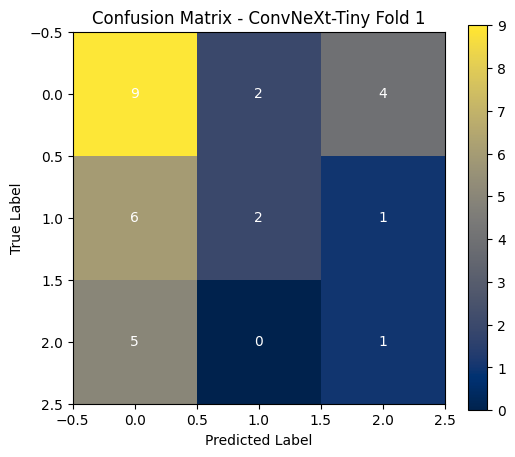

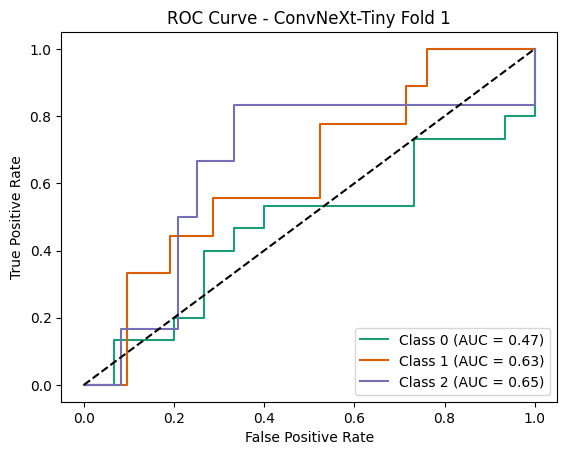


--- Fold 2 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.4667, Precision: 0.4219, Recall: 0.4667, F1-score: 0.4278


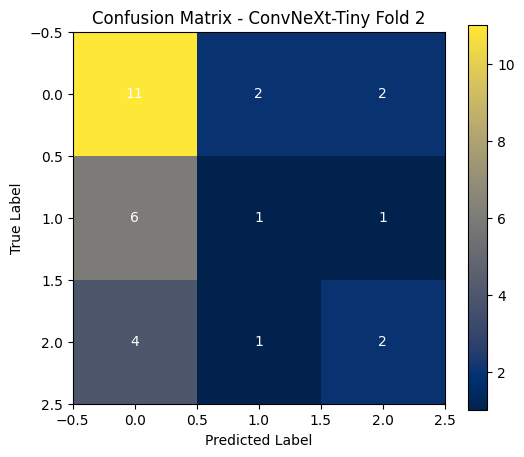

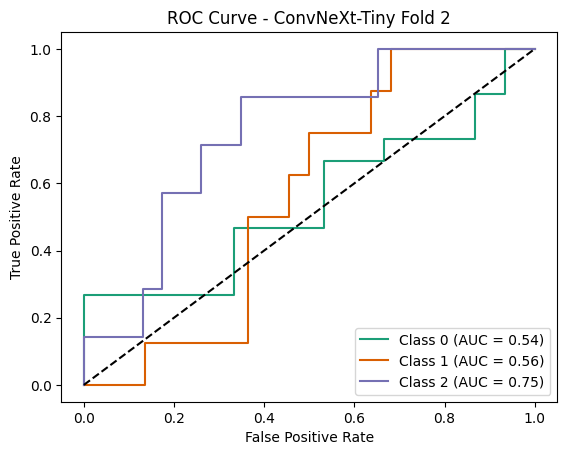


--- Fold 3 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.3667, Precision: 0.3504, Recall: 0.3667, F1-score: 0.3570


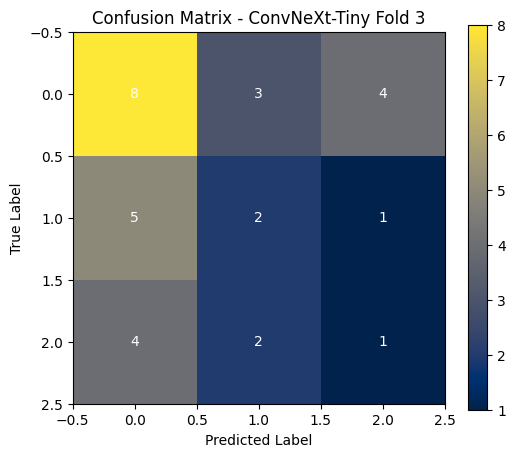

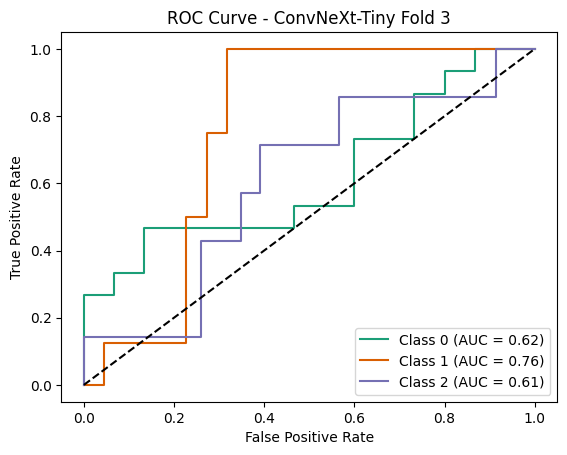


--- Fold 4 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.5000, Precision: 0.3752, Recall: 0.5000, F1-score: 0.4225


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


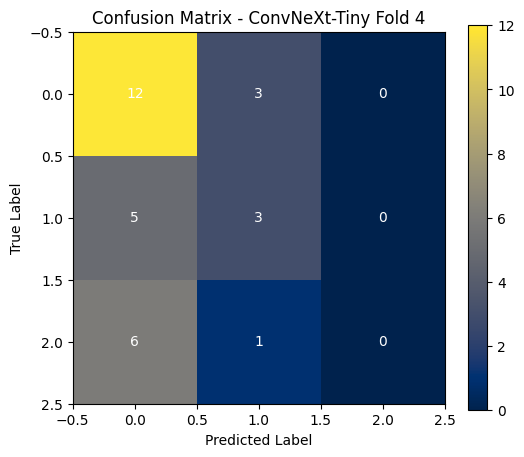

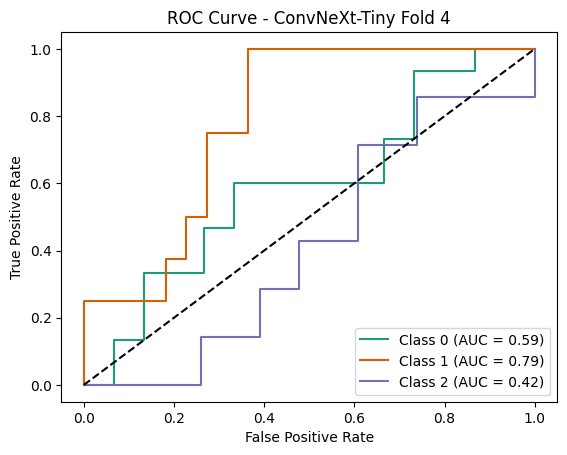


--- Fold 5 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.5517, Precision: 0.5402, Recall: 0.5517, F1-score: 0.5419


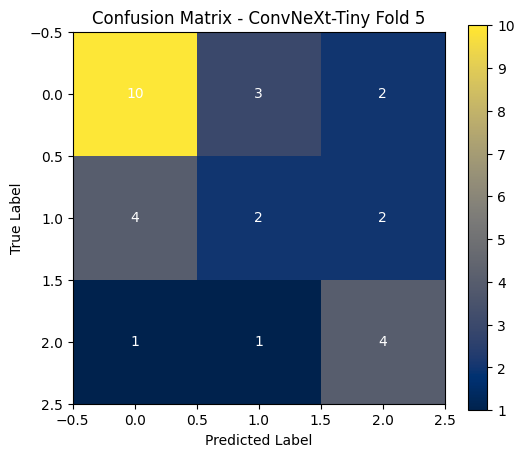

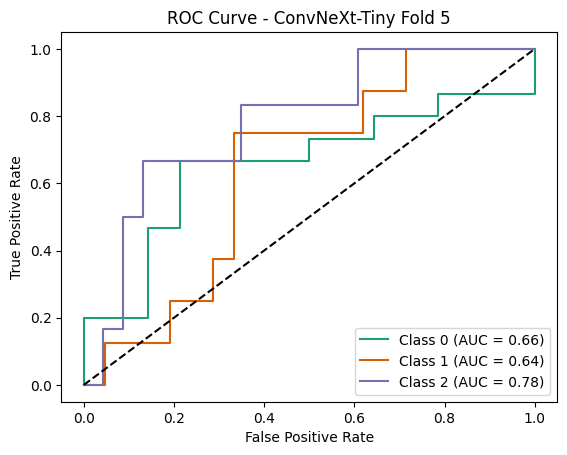


--- K-Fold Summary ---
Average Accuracy: 0.4570
Average Precision: 0.4192
Average Recall: 0.4570
Average F1-score: 0.4264


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from torchvision import transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = CustomDataset(df, transform)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X = df["Image_Path"]
y = df["Final_Label"]

fold = 1
acc_list, precision_list, recall_list, f1_list = [], [], [], []

for train_idx, test_idx in kfold.split(X, y):
    print(f"\n--- Fold {fold} ---")

    train_subset = Subset(dataset, train_idx)
    test_subset = Subset(dataset, test_idx)

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=16, shuffle=False)

    model = models.convnext_tiny(pretrained=True)
    model.classifier[2] = nn.Linear(model.classifier[2].in_features, 3)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    epochs = 10
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")

    acc_list.append(acc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='cividis')
    plt.title(f"Confusion Matrix - ConvNeXt-Tiny Fold {fold}")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i,j]),
                     ha='center', va='center', color='white' if cm[i,j]>cm.max()/2 else 'white')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    y_test_bin = label_binarize(all_labels, classes=[0,1,2])
    all_probs = np.array(all_probs)

    plt.figure()
    colors = ['#1b9e77', '#d95f02', '#7570b3']
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - ConvNeXt-Tiny Fold {fold}")
    plt.legend()
    plt.show()

    fold += 1

print("\n--- K-Fold Summary ---")
print(f"Average Accuracy: {np.mean(acc_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1-score: {np.mean(f1_list):.4f}")


In [ ]:
import sys
sys.path.append("/content/big_transfer/big_transfer") # Add the direct path to the package content

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from torchvision import transforms
# Corrected imports to directly import modules after adding their directory to sys.path
import utils
import checkpoint
import models as bi_tmodels # Renamed for consistency with previous use of bi_tmodels

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = CustomDataset(df, transform)
class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)
X = df["Image_Path"]
y = df["Final_Label"]
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
acc_list, precision_list, recall_list, f1_list = [], [], [], []

for train_idx, test_idx in kfold.split(X, y):

    train_subset = Subset(dataset, train_idx)
    test_subset = Subset(dataset, test_idx)
    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=16, shuffle=False)

    # Instantiate BiT model and load checkpoint
    model = bi_tmodels.KNOWN_MODELS["BiT-M-R50x1"](head_size=3)
    checkpoint.load(model, "R50x1", num_classes=3)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    epochs = 10
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    acc_list.append(acc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

    print(f"\nFold {fold}")
    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='GnBu')
    plt.title(f"Confusion Matrix - BiT-M-R50x1 Fold {fold}")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i,j]),
                     ha='center', va='center', color='white' if cm[i,j]>cm.max()/2 else 'black')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    y_test_bin = label_binarize(all_labels, classes=[0,1,2])
    all_probs = np.array(all_probs)
    plt.figure()
    colors = ['#1b9e77', '#d95f02', '#7570b3']
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Label")
    plt.title(f"ROC Curve - BiT-M-R50x1 Fold {fold}")
    plt.legend()
    plt.show()

    fold += 1

print("\n5-Fold Summary")
print(f"Avg Accuracy: {np.mean(acc_list):.4f}")
print(f"Avg Precision: {np.mean(precision_list):.4f}")
print(f"Avg Recall: {np.mean(recall_list):.4f}")
print(f"Avg F1-score: {np.mean(f1_list):.4f}")

ModuleNotFoundError: No module named 'big_transfer.big_transfer'

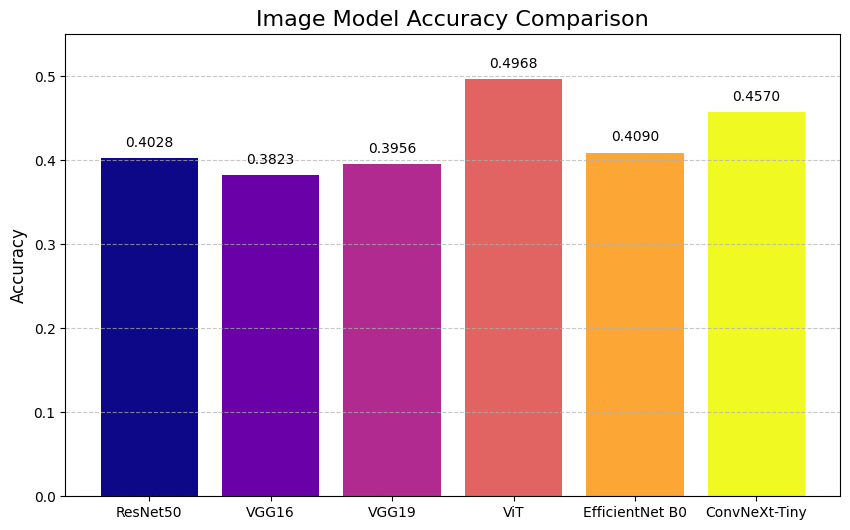

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['ResNet50', 'VGG16', 'VGG19', 'ViT', 'EfficientNet B0', 'ConvNeXt-Tiny']
accuracy = [0.4028, 0.3823, 0.3956, 0.4968, 0.4090, 0.4570]

colors = plt.cm.plasma(np.linspace(0, 1, len(models)))

plt.figure(figsize=(10,6))
bars = plt.bar(models, accuracy, color=colors)

for bar, acc in zip(bars, accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10)

plt.title('Image Model Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 0.55)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# **Image-Text**

In [ ]:
import pandas as pd
processed_csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
original_csv_path = "/content/drive/MyDrive/Political_Bias/Final_Dataset.csv"
new_csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"

processed_df = pd.read_csv(processed_csv_path)
original_df = pd.read_csv(original_csv_path)

merged_df = pd.merge(
    processed_df,
    original_df[["Image_id", "Preprocessed_Text"]],
    on="Image_id",
    how="left"
)

merged_df.to_csv(new_csv_path, index=False)
print("New CSV with Preprocessed_Text saved at:")
print(new_csv_path)

New CSV with Preprocessed_Text saved at:
/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv


In [ ]:
!pip install transformers timm scikit-learn

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Accuracy: 0.43333333333333335
Precision: 0.49166666666666664
Recall: 0.43333333333333335
F1-score: 0.4222222222222222


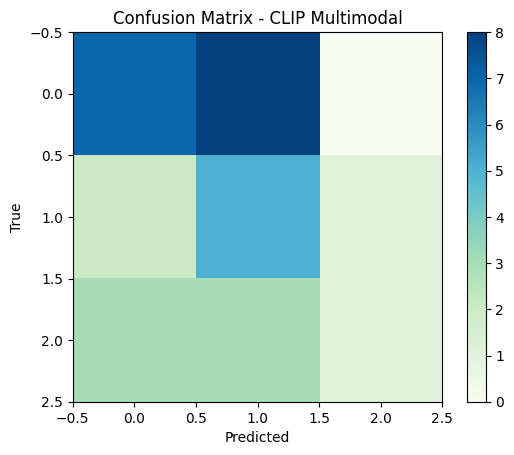

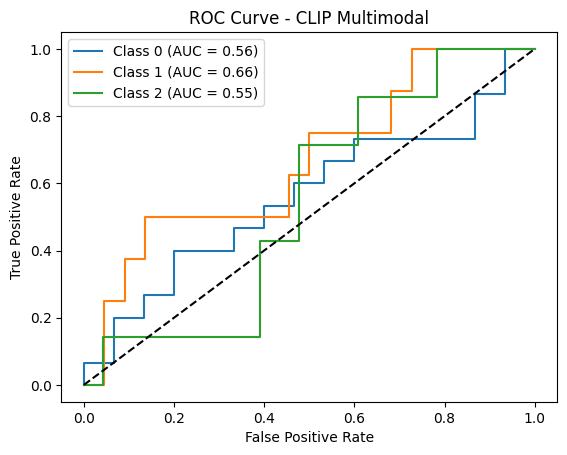

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from transformers import CLIPProcessor, CLIPModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Final_Label"], random_state=42)

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["Image_Path"]).convert("RGB")
        text = str(row["Preprocessed_Text"])
        label = int(row["Final_Label"])
        return image, text, label

def collate_fn(batch):
    images, texts, labels = zip(*batch)
    inputs = processor(
        text=list(texts),
        images=list(images),
        return_tensors="pt",
        padding=True,
        truncation=True
    )
    inputs["labels"] = torch.tensor(labels)
    return inputs

train_dataset = MultimodalDataset(train_df)
test_dataset = MultimodalDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model = model.to(device)

classifier = nn.Linear(model.config.projection_dim * 2, 3).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(list(model.parameters()) + list(classifier.parameters()), lr=1e-5)

epochs = 5

for epoch in range(epochs):
    model.train()
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values
        )

        text_embeds = outputs.text_embeds
        image_embeds = outputs.image_embeds

        fused = torch.cat((text_embeds, image_embeds), dim=1)
        logits = classifier(fused)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values
        )

        text_embeds = outputs.text_embeds
        image_embeds = outputs.image_embeds
        fused = torch.cat((text_embeds, image_embeds), dim=1)
        logits = classifier(fused)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, cmap="GnBu")
plt.title("Confusion Matrix - CLIP Multimodal")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)

plt.figure()
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CLIP Multimodal")
plt.legend()
plt.show()

df_test = test_df.copy().reset_index(drop=True)
df_test["Predicted_Label"] = all_preds
df_test.to_csv("/content/drive/MyDrive/Political_Bias/CLIP_Predictions.csv", index=False)


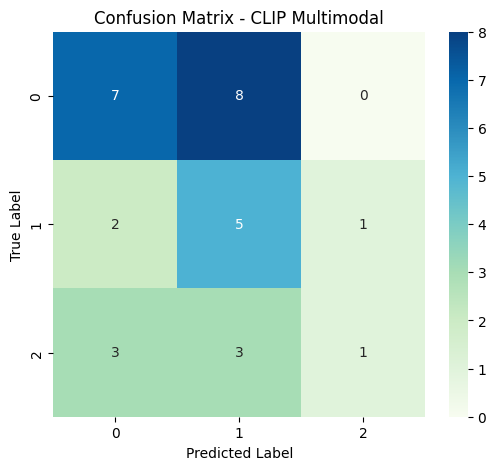

In [ ]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="GnBu", cbar=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CLIP Multimodal")
plt.show()

`BlipModel` is going to be deprecated in future release, please use `BlipForConditionalGeneration`, `BlipForQuestionAnswering` or `BlipForImageTextRetrieval` depending on your usecase.


Loading weights:   0%|          | 0/150 [00:00<?, ?it/s]

BlipModel LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                                                             | Status     | 
--------------------------------------------------------------------------------+------------+-
text_decoder.bert.encoder.layer.{0...11}.crossattention.self.query.bias         | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.crossattention.output.LayerNorm.weight | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.attention.output.dense.bias            | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.intermediate.dense.weight              | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.attention.self.query.weight            | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.output.LayerNorm.bias                  | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.crossattention.output.LayerNorm.bias   | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.crossattention.output.dense.w

Accuracy: 0.4666666666666667
Precision: 0.4642857142857143
Recall: 0.4666666666666667
F1-score: 0.44713804713804717


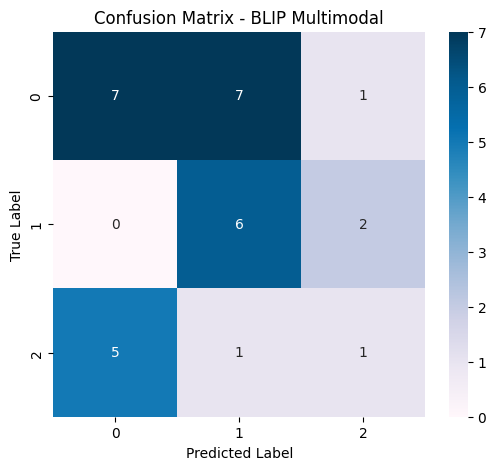

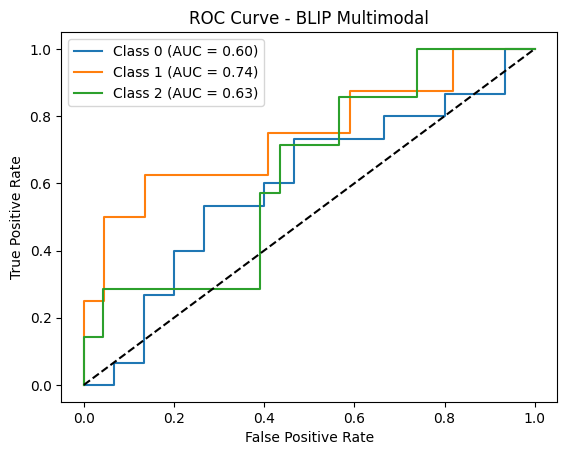

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from transformers import BlipProcessor, BlipModel # Changed to BlipModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Final_Label"], random_state=42)

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["Image_Path"]).convert("RGB")
        text = str(row["Preprocessed_Text"])
        label = int(row["Final_Label"])
        return image, text, label

def collate_fn(batch):
    images, texts, labels = zip(*batch)
    inputs = processor(
        images=list(images),
        text=list(texts),
        return_tensors="pt",
        padding=True,
        truncation=True
    )
    inputs["labels"] = torch.tensor(labels)
    return inputs

train_dataset = MultimodalDataset(train_df)
test_dataset = MultimodalDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

model = BlipModel.from_pretrained("Salesforce/blip-image-captioning-base") # Changed to BlipModel
model = model.to(device)

# Get embedding size dynamically - This part is now consistent with the debugged cell 3J5cGTOdMI2V
# Using the fusion_dim found from cell 3J5cGTOdMI2V: 1024
fusion_dim = 1024 # outputs.text_embeds.shape[-1] + outputs.image_embeds.shape[-1]

classifier = nn.Linear(fusion_dim, 3).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(list(model.parameters()) + list(classifier.parameters()), lr=1e-5)

epochs = 5

for epoch in range(epochs):
    model.train()
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values, return_dict=True)

        text_embeds = outputs.text_embeds # Direct access for BlipModel
        image_embeds = outputs.image_embeds # Direct access for BlipModel

        fused = torch.cat((text_embeds, image_embeds), dim=1)
        logits = classifier(fused)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values, return_dict=True)

        text_embeds = outputs.text_embeds # Direct access for BlipModel
        image_embeds = outputs.image_embeds # Direct access for BlipModel

        fused = torch.cat((text_embeds, image_embeds), dim=1)
        logits = classifier(fused)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuBu", cbar=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BLIP Multimodal")
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)
plt.figure()
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr) # Corrected: Pass fpr and tpr arrays directly
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BLIP Multimodal")
plt.legend()
plt.show()

df_test = test_df.copy().reset_index(drop=True)
df_test["Predicted_Label"] = all_preds
df_test.to_csv("/content/drive/MyDrive/Political_Bias/BLIP_Predictions.csv", index=False)


preprocessor_config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

The image processor of type `EfficientNetImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/399 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/690M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/690M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1394 [00:00<?, ?it/s]

AlignModel LOAD REPORT from: kakaobrain/align-base
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.6
Precision: 0.4567287784679089
Recall: 0.6
F1-score: 0.5106432748538012


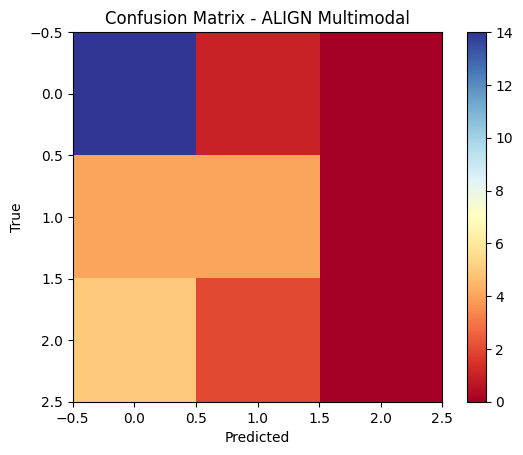

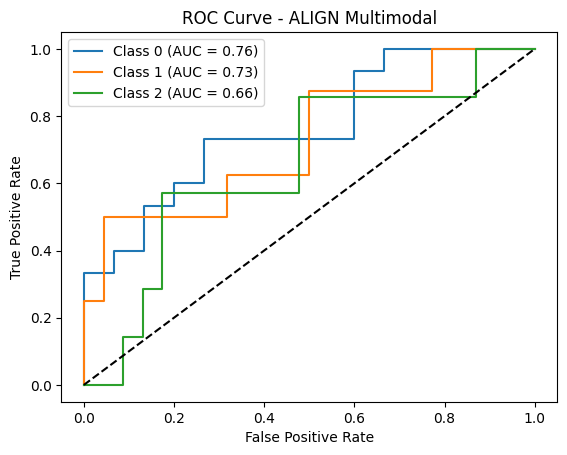

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from transformers import AutoProcessor, AlignModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Final_Label"], random_state=42)

processor = AutoProcessor.from_pretrained("kakaobrain/align-base")
model = AlignModel.from_pretrained("kakaobrain/align-base").to(device)

class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["Image_Path"]).convert("RGB")
        text = str(row["Preprocessed_Text"])
        label = int(row["Final_Label"])
        return image, text, label

def collate_fn(batch):
    images, texts, labels = zip(*batch)
    inputs = processor(text=list(texts), images=list(images), return_tensors="pt", padding=True, truncation=True)
    inputs["labels"] = torch.tensor(labels)
    return inputs

train_dataset = MultimodalDataset(train_df)
test_dataset = MultimodalDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float).to(device)

classifier = nn.Linear(model.config.projection_dim * 2, 3).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(list(model.parameters()) + list(classifier.parameters()), lr=1e-5)

epochs = 5

for epoch in range(epochs):
    model.train()
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values)
        text_embeds = outputs.text_embeds
        image_embeds = outputs.image_embeds
        fused = torch.cat((text_embeds, image_embeds), dim=1)
        logits = classifier(fused)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values)
        text_embeds = outputs.text_embeds
        image_embeds = outputs.image_embeds
        fused = torch.cat((text_embeds, image_embeds), dim=1)
        logits = classifier(fused)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, cmap="RdYlBu")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - ALIGN Multimodal")
plt.colorbar()
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)

plt.figure()
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ALIGN Multimodal")
plt.legend()
plt.show()

df_test = test_df.copy().reset_index(drop=True)
df_test["Predicted_Label"] = all_preds
df_test.to_csv("/content/drive/MyDrive/Political_Bias/ALIGN_Predictions.csv", index=False)


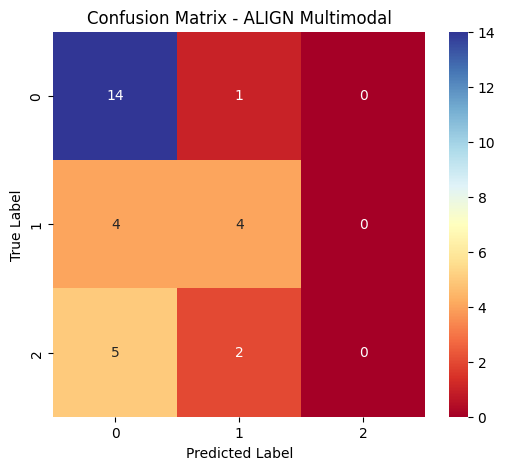

In [ ]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdYlBu", cbar=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ALIGN Multimodal")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from transformers import BridgeTowerProcessor, BridgeTowerModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Final_Label"], random_state=42)

processor = BridgeTowerProcessor.from_pretrained("BridgeTower/bridgetower-base")
# Load model in half-precision (float16) to save memory
model = BridgeTowerModel.from_pretrained("BridgeTower/bridgetower-base", torch_dtype=torch.float16).to(device)

class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["Image_Path"]).convert("RGB")
        text = str(row["Preprocessed_Text"])
        label = int(row["Final_Label"])
        return image, text, label

def collate_fn(batch):
    images, texts, labels = zip(*batch)
    inputs = processor(images=list(images), text=list(texts), return_tensors="pt", padding=True, truncation=True)
    inputs["labels"] = torch.tensor(labels)
    return inputs

train_dataset = MultimodalDataset(train_df)
test_dataset = MultimodalDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float).to(device)

hidden_size = model.config.hidden_size
classifier = nn.Linear(hidden_size*2, 3).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(list(model.parameters()) + list(classifier.parameters()), lr=1e-5)

epochs = 5

for epoch in range(epochs):
    model.train()
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values)
        # Corrected: Use text_features and image_features
        text_embeds = outputs.text_features
        vision_embeds = outputs.image_features
        fused = torch.cat((text_embeds, vision_embeds), dim=1)
        # Ensure classifier also processes float16 if model outputs float16
        logits = classifier(fused.to(torch.float32)) # Convert to float32 for linear layer computation if needed
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values)
        # Corrected: Use text_features and image_features
        text_embeds = outputs.text_features
        vision_embeds = outputs.image_features
        fused = torch.cat((text_embeds, vision_embeds), dim=1)
        # Ensure classifier also processes float16 if model outputs float16
        logits = classifier(fused.to(torch.float32)) # Convert to float32 for linear layer computation if needed
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="BrBG", cbar=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BridgeTower Multimodal")
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)

plt.figure()
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BridgeTower Multimodal")
plt.legend()
plt.show()

df_test = test_df.copy().reset_index(drop=True)
df_test["Predicted_Label"] = all_preds
df_test.to_csv("/content/drive/MyDrive/Political_Bias/BridgeTower_Predictions.csv", index=False)


Fast image processor class <class 'transformers.models.bridgetower.image_processing_bridgetower_fast.BridgeTowerImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/695 [00:00<?, ?it/s]

BridgeTowerModel LOAD REPORT from: BridgeTower/bridgetower-base
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
vision_model.visual.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


OutOfMemoryError: CUDA out of memory. Tried to allocate 74.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 15.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 13.93 GiB is allocated by PyTorch, and 489.32 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

preprocessor_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

The image processor of type `ViltImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/653 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

ViltModel LOAD REPORT from: dandelin/vilt-b32-mlm
Key                                          | Status     |  | 
---------------------------------------------+------------+--+-
mlm_score.bias                               | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.bias           | UNEXPECTED |  | 
mlm_score.transform.dense.bias               | UNEXPECTED |  | 
mlm_score.transform.dense.weight             | UNEXPECTED |  | 
vilt.embeddings.text_embeddings.position_ids | UNEXPECTED |  | 
mlm_score.decoder.weight                     | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.weight         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Accuracy: 0.4666666666666667
Precision: 0.5558585858585858
Recall: 0.4666666666666667
F1-score: 0.48630030959752324


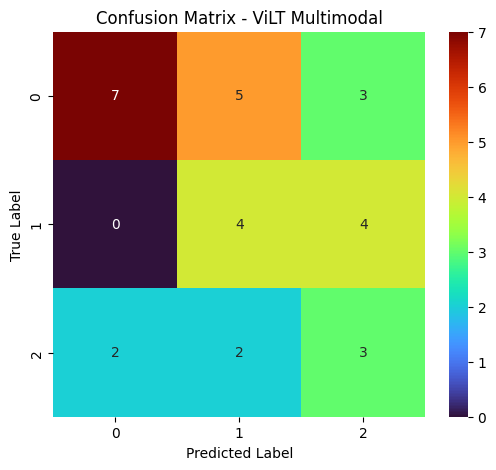

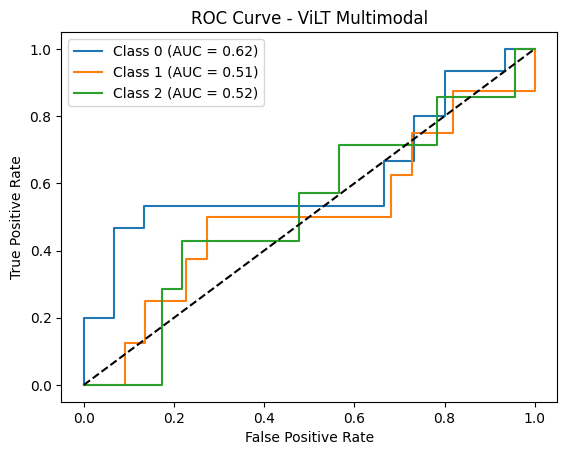

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from transformers import ViltProcessor, ViltModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Final_Label"], random_state=42)

processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-mlm")
model = ViltModel.from_pretrained("dandelin/vilt-b32-mlm").to(device)

class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["Image_Path"]).convert("RGB")
        text = str(row["Preprocessed_Text"])
        label = int(row["Final_Label"])
        return image, text, label

def collate_fn(batch):
    images, texts, labels = zip(*batch)
    inputs = processor(images=list(images), text=list(texts), return_tensors="pt", padding=True, truncation=True)
    inputs["labels"] = torch.tensor(labels)
    return inputs

train_dataset = MultimodalDataset(train_df)
test_dataset = MultimodalDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float).to(device)

hidden_size = model.config.hidden_size
classifier = nn.Linear(hidden_size, 3).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(list(model.parameters()) + list(classifier.parameters()), lr=1e-5)

epochs = 5

for epoch in range(epochs):
    model.train()
    for batch in train_loader:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        outputs = model(pixel_values=pixel_values, input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0, :]
        logits = classifier(pooled)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(pixel_values=pixel_values, input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0, :]
        logits = classifier(pooled)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="turbo", cbar=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ViLT Multimodal")
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)

plt.figure()
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ViLT Multimodal")
plt.legend()
plt.show()

df_test = test_df.copy().reset_index(drop=True)
df_test["Predicted_Label"] = all_preds
df_test.to_csv("/content/drive/MyDrive/Political_Bias/ViLT_Predictions.csv", index=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/881 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/358 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_1.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_2.weight | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_2.res_path.path.conv_1.weight | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_2.res_path.path.conv_3.bias   | UNEXPECTED |  | 
itm_head.seq_relationship.bias                                          | UNEXPECTED |  | 
itm_head.seq_relationship.weight                                        | UNEXPECTED |  | 
image_codebook.blocks.group_3.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_3.weight | UNEXPECTED |  | 
mlm_head.transform.LayerNorm.weight      

Accuracy: 0.43333333333333335
Precision: 0.47435897435897434
Recall: 0.43333333333333335
F1-score: 0.43222222222222223


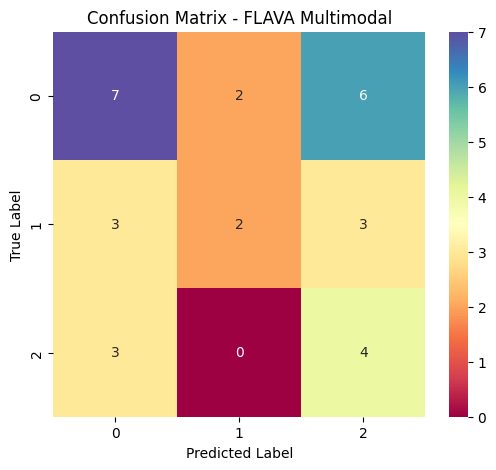

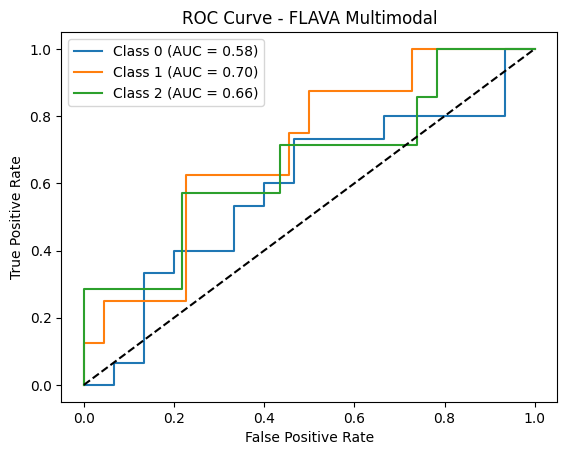

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from transformers import FlavaProcessor, FlavaModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Final_Label"], random_state=42)

processor = FlavaProcessor.from_pretrained("facebook/flava-full")
model = FlavaModel.from_pretrained("facebook/flava-full").to(device)

class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["Image_Path"]).convert("RGB")
        text = str(row["Preprocessed_Text"])
        label = int(row["Final_Label"])
        return image, text, label

def collate_fn(batch):
    images, texts, labels = zip(*batch)
    inputs = processor(images=list(images), text=list(texts), return_tensors="pt", padding=True, truncation=True)
    inputs["labels"] = torch.tensor(labels)
    return inputs

train_dataset = MultimodalDataset(train_df)
test_dataset = MultimodalDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float).to(device)

hidden_size = model.config.hidden_size
classifier = nn.Linear(hidden_size, 3).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(list(model.parameters()) + list(classifier.parameters()), lr=1e-5)

epochs = 5

for epoch in range(epochs):
    model.train()
    for batch in train_loader:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values)
        # Corrected: Use 'multimodal_embeddings' (plural) and pool it
        pooled = outputs.multimodal_embeddings[:, 0, :]
        logits = classifier(pooled)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values)
        # Corrected: Use 'multimodal_embeddings' (plural) and pool it
        pooled = outputs.multimodal_embeddings[:, 0, :]
        logits = classifier(pooled)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Spectral", cbar=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - FLAVA Multimodal")
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)

plt.figure()
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - FLAVA Multimodal")
plt.legend()
plt.show()

df_test = test_df.copy().reset_index(drop=True)
df_test["Predicted_Label"] = all_preds
df_test.to_csv("/content/drive/MyDrive/Political_Bias/FLAVA_Predictions.csv", index=False)

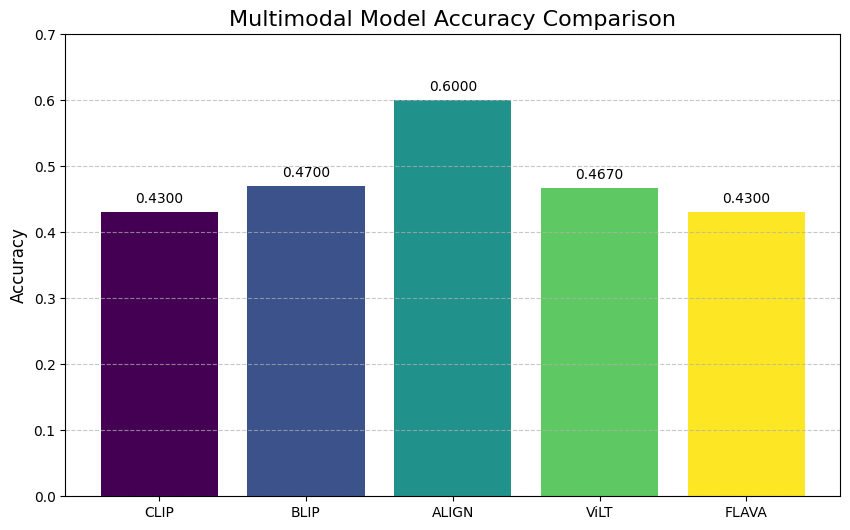

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['CLIP', 'BLIP', 'ALIGN', 'ViLT', 'FLAVA']
accuracy = [0.43, 0.47, 0.60, 0.467, 0.43]

colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

plt.figure(figsize=(10,6))
bars = plt.bar(models, accuracy, color=colors)

for bar, acc in zip(bars, accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10)

plt.title('Multimodal Model Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# **Proposed Model**

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 1.124854322274526
Epoch 2 Loss: 0.5979795932769776
Epoch 3 Loss: 0.3237767418225606
Epoch 4 Loss: 0.14900725980599722
Epoch 5 Loss: 0.0742725503941377
Accuracy: 0.6
Precision: 0.6222222222222221
Recall: 0.6
F1-score: 0.5866666666666667


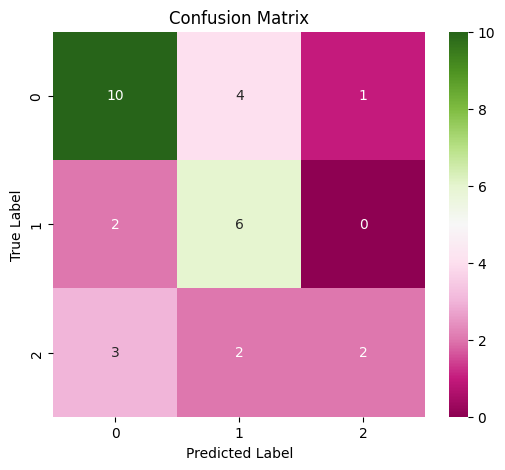

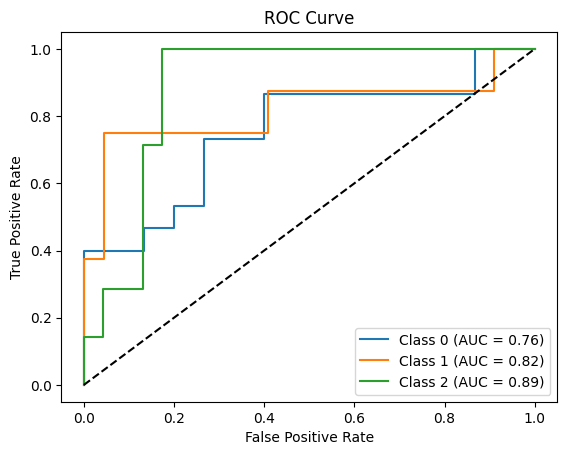

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from transformers import AutoTokenizer, AutoModel
from transformers import ViTModel, ViTImageProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Final_Label"],
    random_state=42
)

text_model_name = "sagorsarker/bangla-bert-base"
image_model_name = "google/vit-base-patch16-224"

tokenizer = AutoTokenizer.from_pretrained(text_model_name)
image_processor = ViTImageProcessor.from_pretrained(image_model_name)

class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["Image_Path"]).convert("RGB")
        text = str(row["Preprocessed_Text"])
        label = int(row["Final_Label"])
        return image, text, label

def collate_fn(batch):
    images, texts, labels = zip(*batch)

    text_inputs = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    image_inputs = image_processor(
        list(images),
        return_tensors="pt"
    )

    return {
        "input_ids": text_inputs["input_ids"],
        "attention_mask": text_inputs["attention_mask"],
        "pixel_values": image_inputs["pixel_values"],
        "labels": torch.tensor(labels)
    }

train_loader = DataLoader(
    MultimodalDataset(train_df),
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    MultimodalDataset(test_df),
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn
)

class MulMoSenT(nn.Module):
    def __init__(self, num_classes=3):
        super(MulMoSenT, self).__init__()

        self.text_model = AutoModel.from_pretrained(text_model_name)
        self.image_model = ViTModel.from_pretrained(image_model_name)

        hidden_dim = 768

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=8,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask, pixel_values):
        text_outputs = self.text_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_cls = text_outputs.last_hidden_state[:, 0, :]

        image_outputs = self.image_model(
            pixel_values=pixel_values
        )
        image_cls = image_outputs.last_hidden_state[:, 0, :]

        F_avg = (text_cls + image_cls) / 2

        query = text_cls.unsqueeze(1)
        key = image_cls.unsqueeze(1)
        value = image_cls.unsqueeze(1)

        attn_output, _ = self.cross_attention(query, key, value)
        F_tica = attn_output.squeeze(1)

        F_final = torch.cat((F_avg, F_tica), dim=1)

        x = self.dropout(F_final)
        logits = self.classifier(x)

        return logits

model = MulMoSenT().to(device)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=2e-5)

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values
        )

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader)}")

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values
        )

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="PiYG", cbar=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)

plt.figure()
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

df_test = test_df.copy().reset_index(drop=True)
df_test["Predicted_Label"] = all_preds
df_test.to_csv("/content/drive/MyDrive/Political_Bias/1_Predictions.csv", index=False)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from transformers import AutoTokenizer, AutoModel
from transformers import ViTModel, ViTImageProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

text_model_name = "sagorsarker/bangla-bert-base"
image_model_name = "google/vit-base-patch16-224"

tokenizer = AutoTokenizer.from_pretrained(text_model_name)
image_processor = ViTImageProcessor.from_pretrained(image_model_name)

class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["Image_Path"]).convert("RGB")
        text = str(row["Preprocessed_Text"])
        label = int(row["Final_Label"])
        return image, text, label

def collate_fn(batch):
    images, texts, labels = zip(*batch)
    text_inputs = tokenizer(list(texts), padding=True, truncation=True, return_tensors="pt")
    image_inputs = image_processor(list(images), return_tensors="pt")
    return {
        "input_ids": text_inputs["input_ids"],
        "attention_mask": text_inputs["attention_mask"],
        "pixel_values": image_inputs["pixel_values"],
        "labels": torch.tensor(labels)
    }

class MulMoSenT(nn.Module):
    def __init__(self, num_classes=3):
        super(MulMoSenT, self).__init__()
        self.text_model = AutoModel.from_pretrained(text_model_name)
        self.image_model = ViTModel.from_pretrained(image_model_name)
        hidden_dim = 768
        self.cross_attention = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=8, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask, pixel_values):
        text_outputs = self.text_model(input_ids=input_ids, attention_mask=attention_mask)
        text_cls = text_outputs.last_hidden_state[:, 0, :]

        image_outputs = self.image_model(pixel_values=pixel_values)
        image_cls = image_outputs.last_hidden_state[:, 0, :]

        F_avg = (text_cls + image_cls) / 2

        query = text_cls.unsqueeze(1)
        key = image_cls.unsqueeze(1)
        value = image_cls.unsqueeze(1)
        attn_output, _ = self.cross_attention(query, key, value)
        F_tica = attn_output.squeeze(1)

        F_final = torch.cat((F_avg, F_tica), dim=1)
        x = self.dropout(F_final)
        logits = self.classifier(x)
        return logits

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(kf.split(df, df["Final_Label"])):
    print(f"\n--- Fold {fold+1} ---")
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    train_loader = DataLoader(MultimodalDataset(train_df), batch_size=8, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(MultimodalDataset(val_df), batch_size=8, shuffle=False, collate_fn=collate_fn)

    model = MulMoSenT().to(device)

    # Class weights
    class_counts = train_df["Final_Label"].value_counts().sort_index()
    class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
    class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=2e-5)
    epochs = 5

    # Training
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask, pixel_values)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

    # Validation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask, pixel_values)
            preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")

    print(f"Fold {fold+1} Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
    all_fold_metrics.append((acc, precision, recall, f1))

# Average metrics across folds
avg_metrics = np.mean(all_fold_metrics, axis=0)
print("\n--- Average Metrics Across Folds ---")
print(f"Accuracy: {avg_metrics[0]:.4f}, Precision: {avg_metrics[1]:.4f}, Recall: {avg_metrics[2]:.4f}, F1-score: {avg_metrics[3]:.4f}")


--- Fold 1 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 1.2015
Epoch 2 Loss: 0.6393
Epoch 3 Loss: 0.3428
Epoch 4 Loss: 0.1638
Epoch 5 Loss: 0.0762
Fold 5 Accuracy: 0.6207, Precision: 0.6099, Recall: 0.6207, F1-score: 0.5893

--- Average Metrics Across Folds ---
Accuracy: 0.5841, Precision: 0.5908, Recall: 0.5841, F1-score: 0.5627


# **standard CrossEntropyLoss**


===== Fold 1 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 1.1132
Epoch 2 Loss: 0.6069
Epoch 3 Loss: 0.3520
Epoch 4 Loss: 0.1644
Epoch 5 Loss: 0.0810
Fold 1 Metrics -> Accuracy: 0.7000, Precision: 0.7682, Recall: 0.7000, F1-score: 0.6830


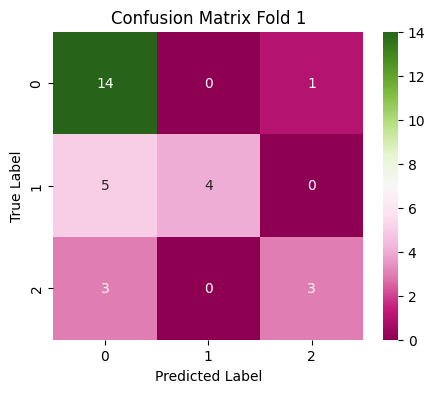

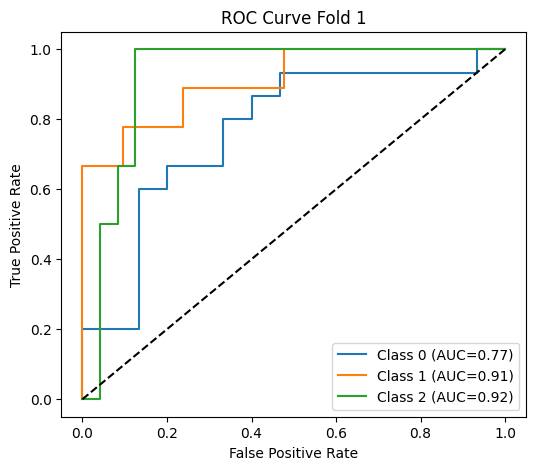


===== Fold 2 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 1.1681
Epoch 2 Loss: 0.6116
Epoch 3 Loss: 0.3616
Epoch 4 Loss: 0.1810
Epoch 5 Loss: 0.0830
Fold 2 Metrics -> Accuracy: 0.6000, Precision: 0.5889, Recall: 0.6000, F1-score: 0.5848


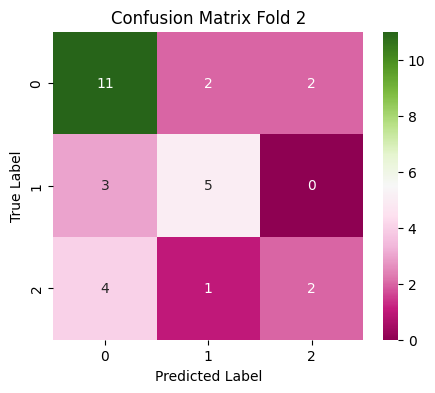

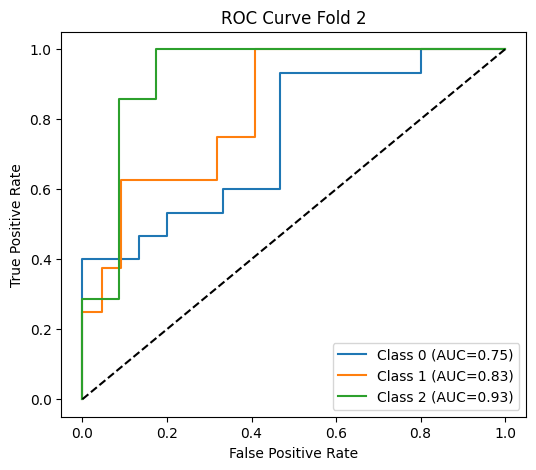


===== Fold 3 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 1.1402
Epoch 2 Loss: 0.6505
Epoch 3 Loss: 0.3677
Epoch 4 Loss: 0.1933
Epoch 5 Loss: 0.0852
Fold 3 Metrics -> Accuracy: 0.5333, Precision: 0.5341, Recall: 0.5333, F1-score: 0.5292


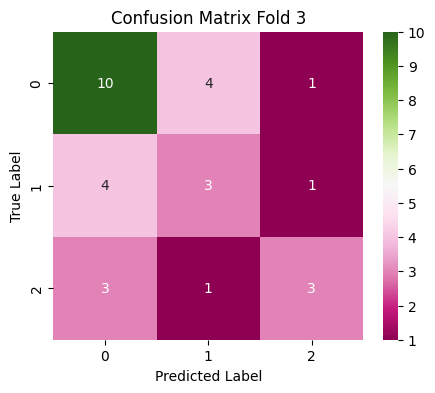

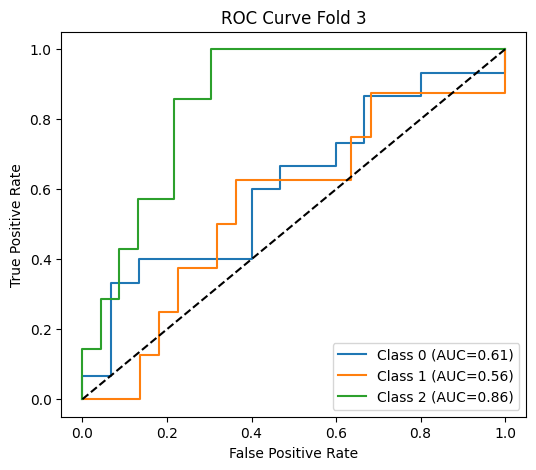


===== Fold 4 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 1.1140
Epoch 2 Loss: 0.6386
Epoch 3 Loss: 0.3060
Epoch 4 Loss: 0.1514
Epoch 5 Loss: 0.0677
Fold 4 Metrics -> Accuracy: 0.6000, Precision: 0.6087, Recall: 0.6000, F1-score: 0.5977


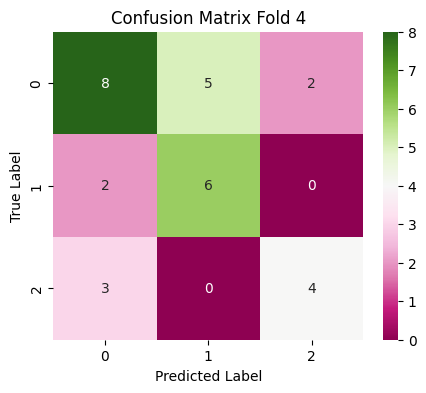

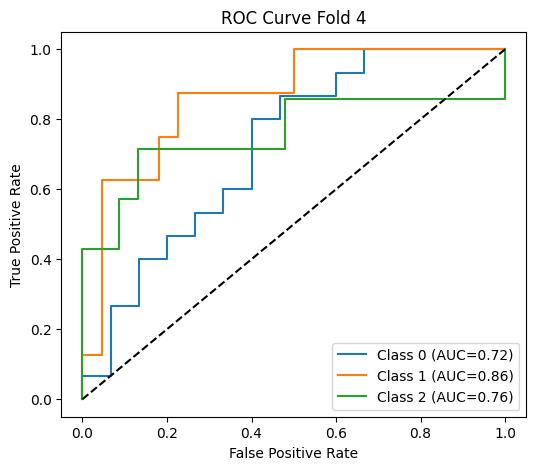


===== Fold 5 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 1.1402
Epoch 2 Loss: 0.5820
Epoch 3 Loss: 0.3300
Epoch 4 Loss: 0.1750
Epoch 5 Loss: 0.0802
Fold 5 Metrics -> Accuracy: 0.7241, Precision: 0.7241, Recall: 0.7241, F1-score: 0.6905


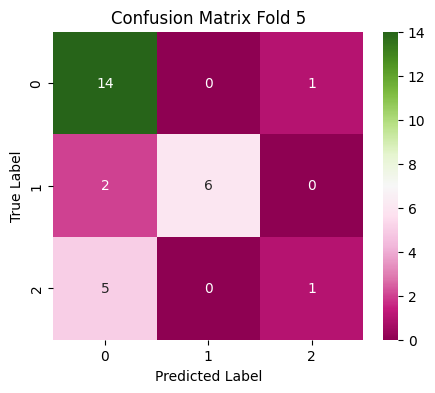

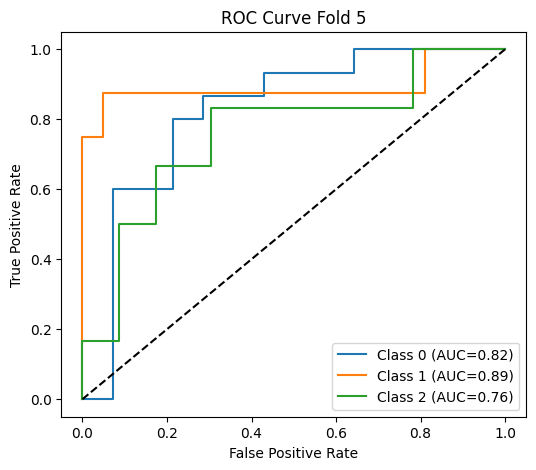


===== Average Metrics Across Folds =====
Accuracy: 0.6315, Precision: 0.6448, Recall: 0.6315, F1-score: 0.6170


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from transformers import AutoTokenizer, AutoModel
from transformers import ViTModel, ViTImageProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

text_model_name = "sagorsarker/bangla-bert-base"
image_model_name = "google/vit-base-patch16-224"

tokenizer = AutoTokenizer.from_pretrained(text_model_name)
image_processor = ViTImageProcessor.from_pretrained(image_model_name)

class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["Image_Path"]).convert("RGB")
        text = str(row["Preprocessed_Text"])
        label = int(row["Final_Label"])
        return image, text, label

def collate_fn(batch):
    images, texts, labels = zip(*batch)
    text_inputs = tokenizer(list(texts), padding=True, truncation=True, return_tensors="pt")
    image_inputs = image_processor(list(images), return_tensors="pt")
    return {
        "input_ids": text_inputs["input_ids"],
        "attention_mask": text_inputs["attention_mask"],
        "pixel_values": image_inputs["pixel_values"],
        "labels": torch.tensor(labels)
    }

class MulMoSenT(nn.Module):
    def __init__(self, num_classes=3):
        super(MulMoSenT, self).__init__()
        self.text_model = AutoModel.from_pretrained(text_model_name)
        self.image_model = ViTModel.from_pretrained(image_model_name)
        hidden_dim = 768
        self.cross_attention = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=8, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask, pixel_values):
        text_outputs = self.text_model(input_ids=input_ids, attention_mask=attention_mask)
        text_cls = text_outputs.last_hidden_state[:, 0, :]
        image_outputs = self.image_model(pixel_values=pixel_values)
        image_cls = image_outputs.last_hidden_state[:, 0, :]
        F_avg = (text_cls + image_cls) / 2
        query = text_cls.unsqueeze(1)
        key = image_cls.unsqueeze(1)
        value = image_cls.unsqueeze(1)
        attn_output, _ = self.cross_attention(query, key, value)
        F_tica = attn_output.squeeze(1)
        F_final = torch.cat((F_avg, F_tica), dim=1)
        x = self.dropout(F_final)
        logits = self.classifier(x)
        return logits

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
num_classes = 3
all_fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(kf.split(df, df["Final_Label"])):
    print(f"\n===== Fold {fold+1} =====")
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    train_loader = DataLoader(MultimodalDataset(train_df), batch_size=8, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(MultimodalDataset(val_df), batch_size=8, shuffle=False, collate_fn=collate_fn)

    model = MulMoSenT().to(device)

    class_counts = train_df["Final_Label"].value_counts().sort_index()
    class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
    class_weights = class_weights.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = optim.Adam(model.parameters(), lr=2e-5)
    epochs = 5

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask, pixel_values)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask, pixel_values)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    all_fold_metrics.append((acc, precision, recall, f1))

    print(f"Fold {fold+1} Metrics -> Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="PiYG")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix Fold {fold+1}")
    plt.show()

    y_bin = label_binarize(all_labels, classes=[0,1,2])
    all_probs = np.array(all_probs)
    plt.figure(figsize=(6,5))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve Fold {fold+1}")
    plt.legend()
    plt.show()

avg_metrics = np.mean(all_fold_metrics, axis=0)
print("\n===== Average Metrics Across Folds =====")
print(f"Accuracy: {avg_metrics[0]:.4f}, Precision: {avg_metrics[1]:.4f}, Recall: {avg_metrics[2]:.4f}, F1-score: {avg_metrics[3]:.4f}")

# **Focal+Cat**


===== Fold 1 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0000
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 1 Metrics -> Accuracy: 0.4667, Precision: 0.5310, Recall: 0.4667, F1-score: 0.4567


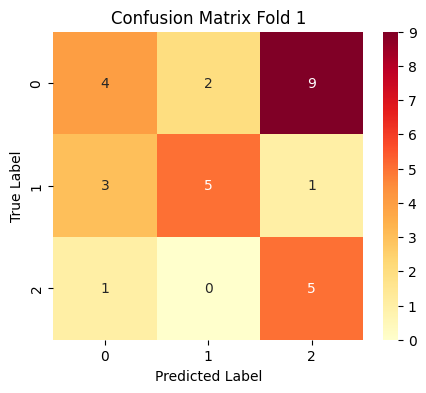

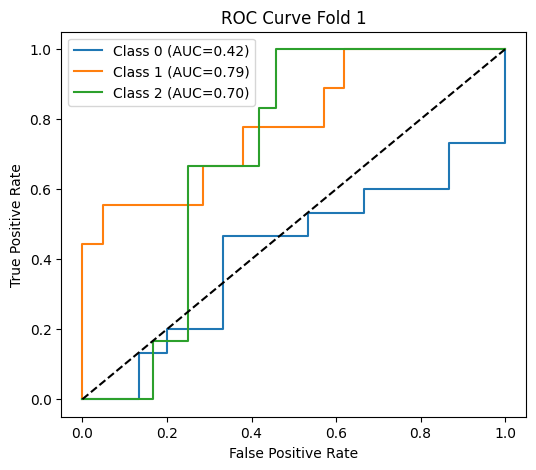


===== Fold 2 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0000
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 2 Metrics -> Accuracy: 0.6000, Precision: 0.6293, Recall: 0.6000, F1-score: 0.6063


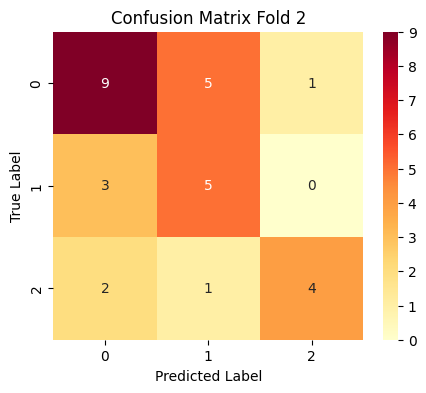

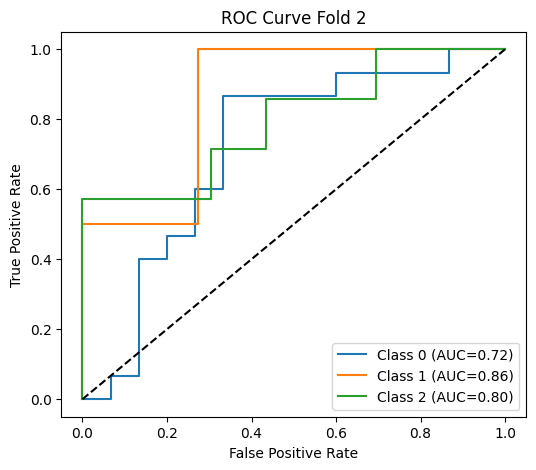


===== Fold 3 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0001
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 3 Metrics -> Accuracy: 0.5667, Precision: 0.5804, Recall: 0.5667, F1-score: 0.5627


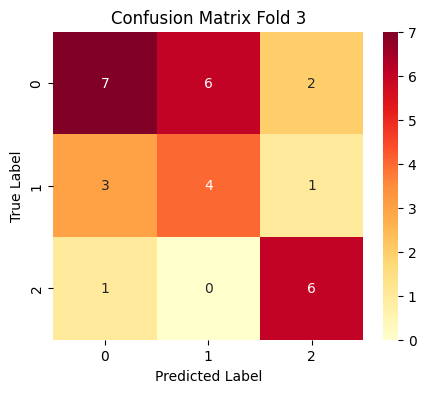

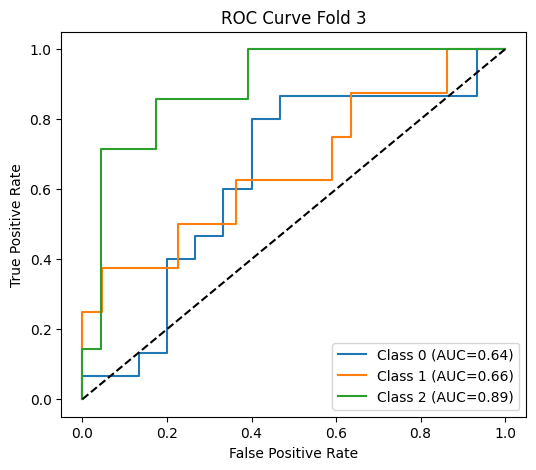


===== Fold 4 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0001
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 4 Metrics -> Accuracy: 0.5000, Precision: 0.5270, Recall: 0.5000, F1-score: 0.4929


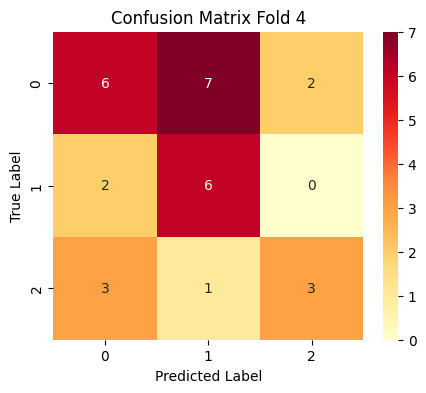

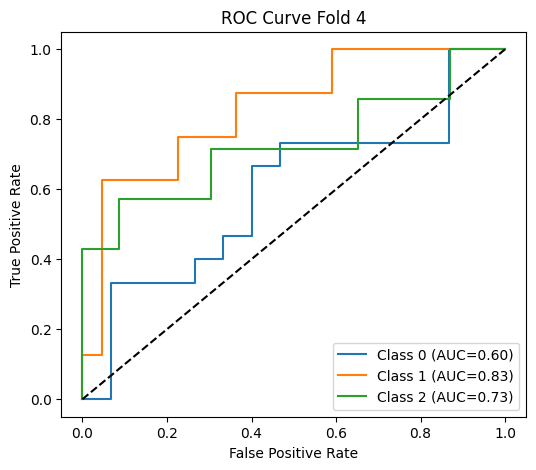


===== Fold 5 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0000
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 5 Metrics -> Accuracy: 0.5172, Precision: 0.5172, Recall: 0.5172, F1-score: 0.5119


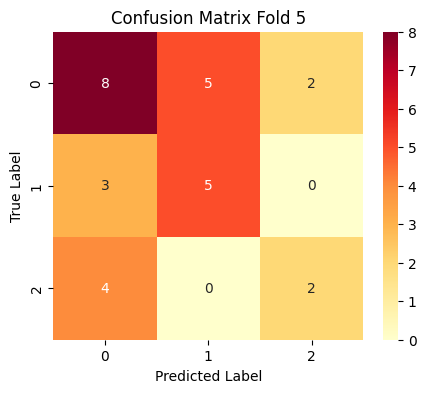

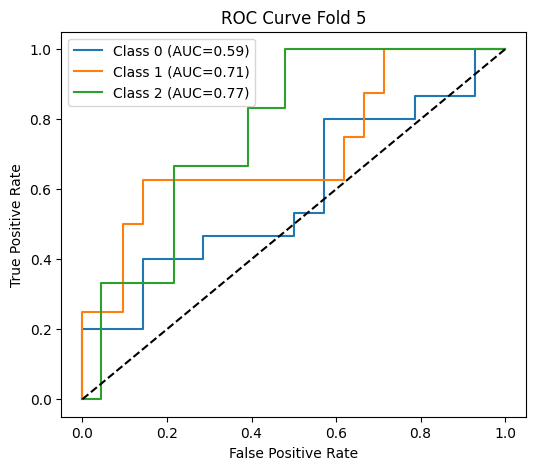


===== Average Metrics Across Folds =====
Accuracy: 0.5301, Precision: 0.5570, Recall: 0.5301, F1-score: 0.5261


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from transformers import AutoTokenizer, AutoModel
from transformers import ViTModel, ViTImageProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Load CSV ---
csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

text_model_name = "sagorsarker/bangla-bert-base"
image_model_name = "google/vit-base-patch16-224"

tokenizer = AutoTokenizer.from_pretrained(text_model_name)
image_processor = ViTImageProcessor.from_pretrained(image_model_name)

# --- Dataset ---
class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["Image_Path"]).convert("RGB")
        text = str(row["Preprocessed_Text"])
        label = int(row["Final_Label"])
        return image, text, label

def collate_fn(batch):
    images, texts, labels = zip(*batch)
    text_inputs = tokenizer(list(texts), padding=True, truncation=True, return_tensors="pt")
    image_inputs = image_processor(list(images), return_tensors="pt")
    return {
        "input_ids": text_inputs["input_ids"],
        "attention_mask": text_inputs["attention_mask"],
        "pixel_values": image_inputs["pixel_values"],
        "labels": torch.tensor(labels)
    }

# --- Focal Loss ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# --- Proposed Model ---
class MulMoSenT_Cat(nn.Module):
    def __init__(self, num_classes=3):
        super(MulMoSenT_Cat, self).__init__()
        self.text_model = AutoModel.from_pretrained(text_model_name)
        self.image_model = ViTModel.from_pretrained(image_model_name)
        hidden_dim = 768
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)  # Concatenation

    def forward(self, input_ids, attention_mask, pixel_values):
        text_outputs = self.text_model(input_ids=input_ids, attention_mask=attention_mask)
        text_cls = text_outputs.last_hidden_state[:, 0, :]
        image_outputs = self.image_model(pixel_values=pixel_values)
        image_cls = image_outputs.last_hidden_state[:, 0, :]
        F_final = torch.cat((text_cls, image_cls), dim=1)
        x = self.dropout(F_final)
        logits = self.classifier(x)
        return logits

# --- Stratified K-Fold Training ---
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
num_classes = 3
all_fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(kf.split(df, df["Final_Label"])):
    print(f"\n===== Fold {fold+1} =====")
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    train_loader = DataLoader(MultimodalDataset(train_df), batch_size=8, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(MultimodalDataset(val_df), batch_size=8, shuffle=False, collate_fn=collate_fn)

    model = MulMoSenT_Cat().to(device)

    # Class weights for imbalance
    class_counts = train_df["Final_Label"].value_counts().sort_index()
    class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float).to(device)
    criterion = FocalLoss(alpha=class_weights, gamma=2, reduction='mean')

    optimizer = optim.Adam(model.parameters(), lr=2e-5)
    epochs = 5

    # --- Training ---
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask, pixel_values)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

    # --- Validation ---
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask, pixel_values)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # --- Metrics ---
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    all_fold_metrics.append((acc, precision, recall, f1))
    print(f"Fold {fold+1} Metrics -> Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    # --- Confusion Matrix ---
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix Fold {fold+1}")
    plt.show()

    # --- ROC Curve ---
    y_bin = label_binarize(all_labels, classes=list(range(num_classes)))
    all_probs = np.array(all_probs)
    plt.figure(figsize=(6,5))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve Fold {fold+1}")
    plt.legend()
    plt.show()

# --- Average Metrics ---
avg_metrics = np.mean(all_fold_metrics, axis=0)
print("\n===== Average Metrics Across Folds =====")
print(f"Accuracy: {avg_metrics[0]:.4f}, Precision: {avg_metrics[1]:.4f}, Recall: {avg_metrics[2]:.4f}, F1-score: {avg_metrics[3]:.4f}")

# **Focal+MFB**


===== Fold 1 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0000
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 1 Metrics -> Accuracy: 0.3333, Precision: 0.4056, Recall: 0.3333, F1-score: 0.3516


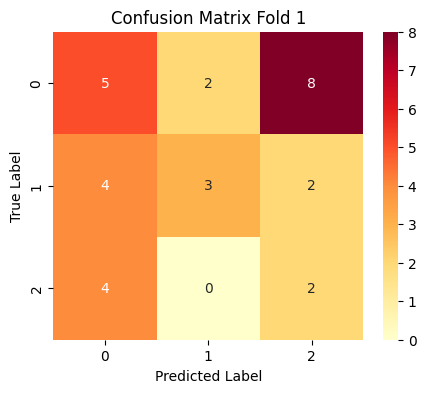

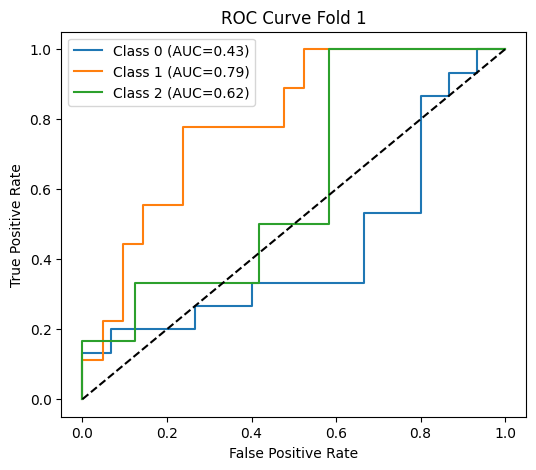


===== Fold 2 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0000
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 2 Metrics -> Accuracy: 0.4333, Precision: 0.5302, Recall: 0.4333, F1-score: 0.4360


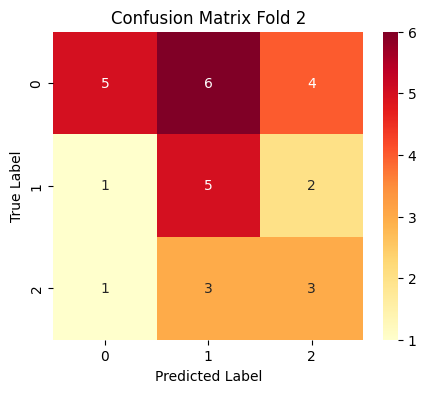

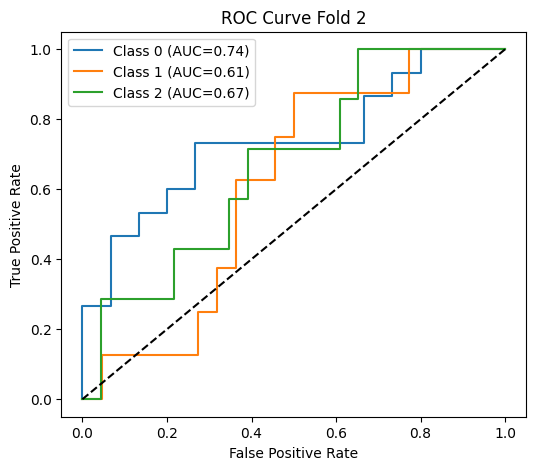


===== Fold 3 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0000
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 3 Metrics -> Accuracy: 0.5333, Precision: 0.5160, Recall: 0.5333, F1-score: 0.5221


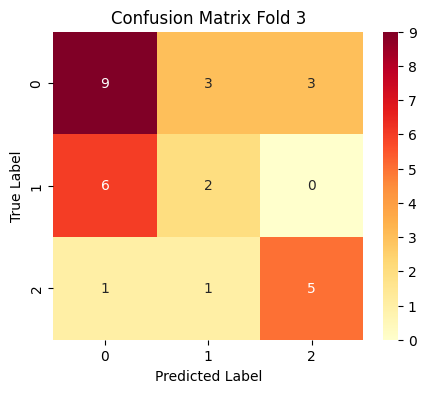

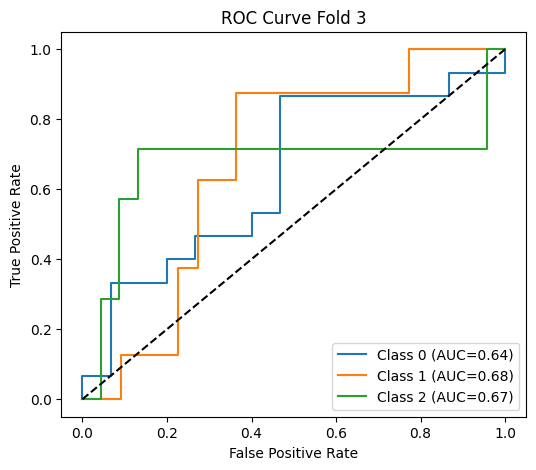


===== Fold 4 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0000
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 4 Metrics -> Accuracy: 0.4333, Precision: 0.4817, Recall: 0.4333, F1-score: 0.4406


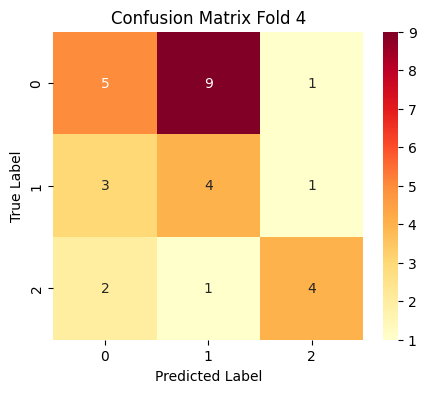

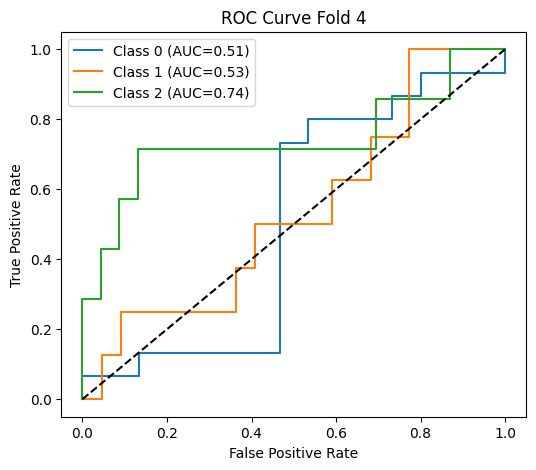


===== Fold 5 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0000
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 5 Metrics -> Accuracy: 0.4828, Precision: 0.5867, Recall: 0.4828, F1-score: 0.4997


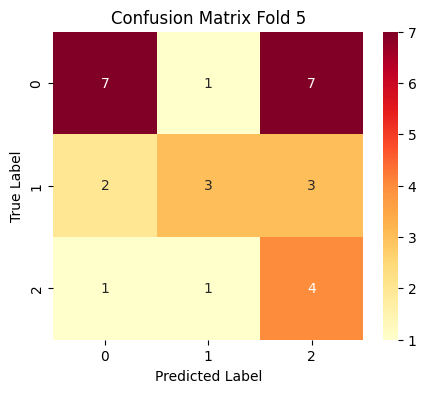

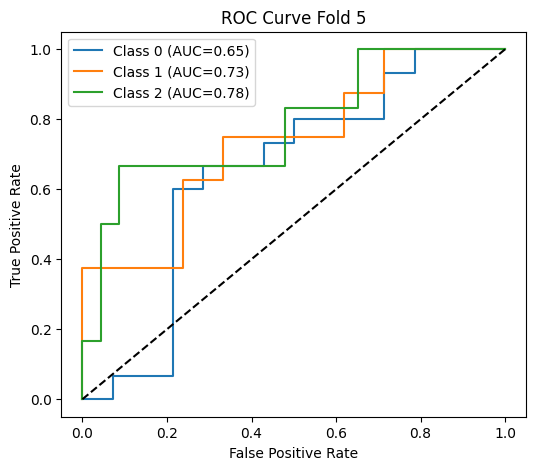


===== Average Metrics Across Folds =====
Accuracy: 0.4432, Precision: 0.5040, Recall: 0.4432, F1-score: 0.4500


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from transformers import AutoTokenizer, AutoModel
from transformers import ViTModel, ViTImageProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

text_model_name = "sagorsarker/bangla-bert-base"
image_model_name = "google/vit-base-patch16-224"

tokenizer = AutoTokenizer.from_pretrained(text_model_name)
image_processor = ViTImageProcessor.from_pretrained(image_model_name)

class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["Image_Path"]).convert("RGB")
        text = str(row["Preprocessed_Text"])
        label = int(row["Final_Label"])
        return image, text, label

def collate_fn(batch):
    images, texts, labels = zip(*batch)
    text_inputs = tokenizer(list(texts), padding=True, truncation=True, return_tensors="pt")
    image_inputs = image_processor(list(images), return_tensors="pt")
    return {
        "input_ids": text_inputs["input_ids"],
        "attention_mask": text_inputs["attention_mask"],
        "pixel_values": image_inputs["pixel_values"],
        "labels": torch.tensor(labels)
    }

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction=='mean':
            return focal_loss.mean()
        elif self.reduction=='sum':
            return focal_loss.sum()
        return focal_loss

class MulMoSenT_MFB(nn.Module):
    def __init__(self, num_classes=3, factor=4):
        super(MulMoSenT_MFB, self).__init__()
        self.text_model = AutoModel.from_pretrained(text_model_name)
        self.image_model = ViTModel.from_pretrained(image_model_name)
        hidden_dim = 768
        self.factor = factor
        self.dropout = nn.Dropout(0.3)
        self.proj_text = nn.Linear(hidden_dim, hidden_dim*factor)
        self.proj_image = nn.Linear(hidden_dim, hidden_dim*factor)
        # FIX: Classifier input dimension should be hidden_dim, not hidden_dim*factor
        self.classifier = nn.Linear(hidden_dim, num_classes) # Changed from hidden_dim*factor
    def forward(self, input_ids, attention_mask, pixel_values):
        text_cls = self.text_model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:,0,:]
        image_cls = self.image_model(pixel_values=pixel_values).last_hidden_state[:,0,:]
        text_proj = self.proj_text(text_cls)
        image_proj = self.proj_image(image_cls)
        joint = text_proj * image_proj
        joint = joint.view(joint.size(0), -1, self.factor).sum(-1) # This produces (batch_size, hidden_dim)
        x = self.dropout(joint)
        logits = self.classifier(x)
        return logits

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
num_classes = 3
all_fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(kf.split(df, df["Final_Label"])):
    print(f"\n===== Fold {fold+1} =====")
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)
    train_loader = DataLoader(MultimodalDataset(train_df), batch_size=8, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(MultimodalDataset(val_df), batch_size=8, shuffle=False, collate_fn=collate_fn)
    model = MulMoSenT_MFB().to(device)
    class_counts = train_df["Final_Label"].value_counts().sort_index()
    class_weights = 1./torch.tensor(class_counts.values, dtype=torch.float).to(device)
    criterion = FocalLoss(alpha=class_weights, gamma=2, reduction='mean')
    optimizer = optim.Adam(model.parameters(), lr=2e-5)
    epochs=5
    for epoch in range(epochs):
        model.train()
        total_loss=0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            optimizer.zero_grad()
            logits = model(input_ids, attention_mask, pixel_values)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            logits = model(input_ids, attention_mask, pixel_values)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    all_fold_metrics.append((acc, precision, recall, f1))
    print(f"Fold {fold+1} Metrics -> Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix Fold {fold+1}")
    plt.show()
    y_bin = label_binarize(all_labels, classes=list(range(num_classes)))
    all_probs = np.array(all_probs)
    plt.figure(figsize=(6,5))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve Fold {fold+1}")
    plt.legend()
    plt.show()

avg_metrics = np.mean(all_fold_metrics, axis=0)
print("\n===== Average Metrics Across Folds =====")
print(f"Accuracy: {avg_metrics[0]:.4f}, Precision: {avg_metrics[1]:.4f}, Recall: {avg_metrics[2]:.4f}, F1-score: {avg_metrics[3]:.4f}")


# **Focal+Sum**


===== Fold 1 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0001
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 1 Metrics -> Accuracy: 0.5333, Precision: 0.5467, Recall: 0.5333, F1-score: 0.5344


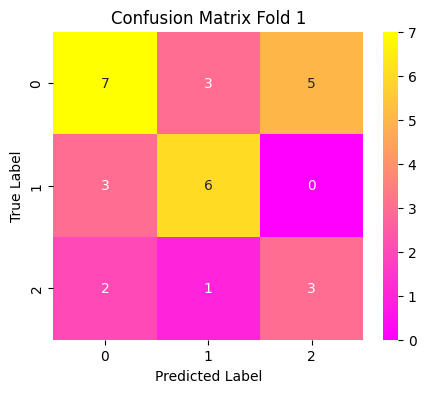

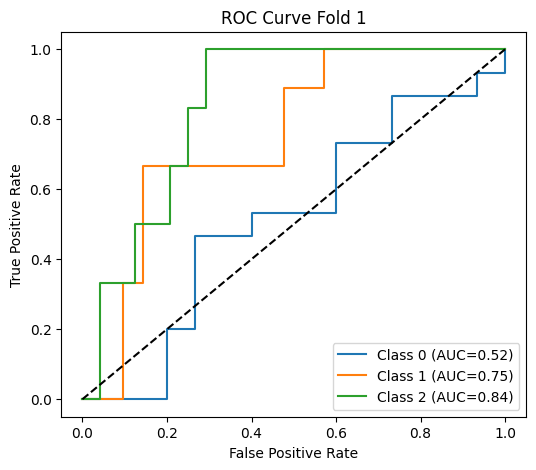


===== Fold 2 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0001
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 2 Metrics -> Accuracy: 0.5667, Precision: 0.6453, Recall: 0.5667, F1-score: 0.5750


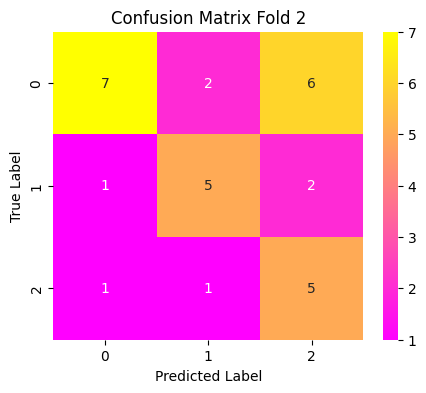

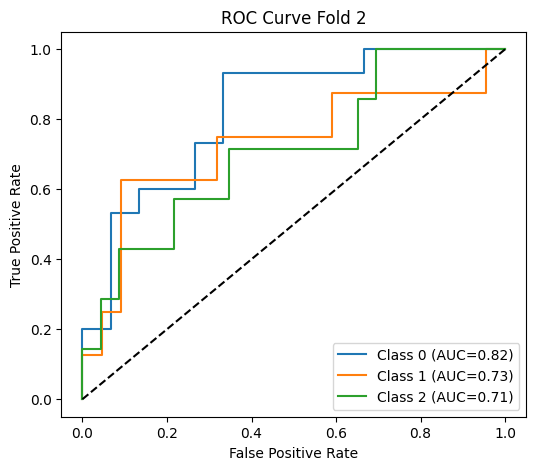


===== Fold 3 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0001
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 3 Metrics -> Accuracy: 0.4000, Precision: 0.4741, Recall: 0.4000, F1-score: 0.4150


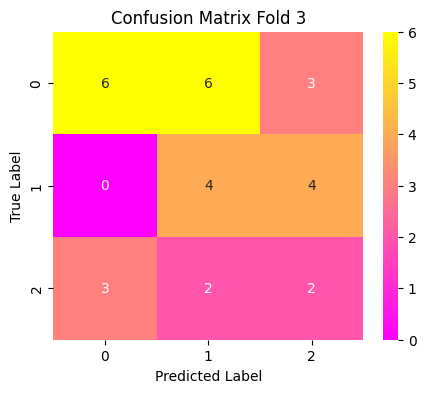

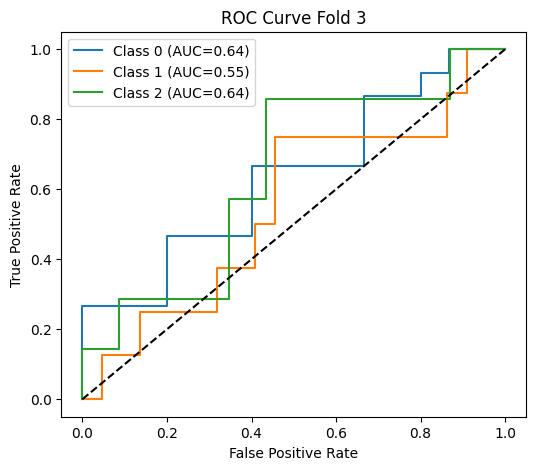


===== Fold 4 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0001
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 4 Metrics -> Accuracy: 0.5333, Precision: 0.5375, Recall: 0.5333, F1-score: 0.5249


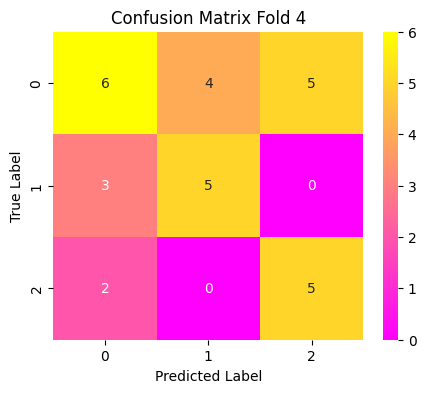

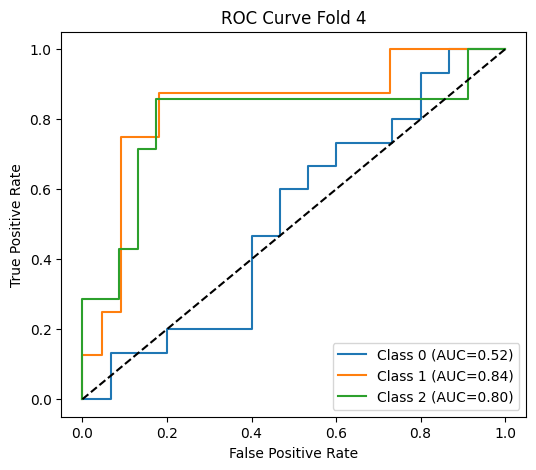


===== Fold 5 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0001
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 5 Metrics -> Accuracy: 0.5862, Precision: 0.5892, Recall: 0.5862, F1-score: 0.5868


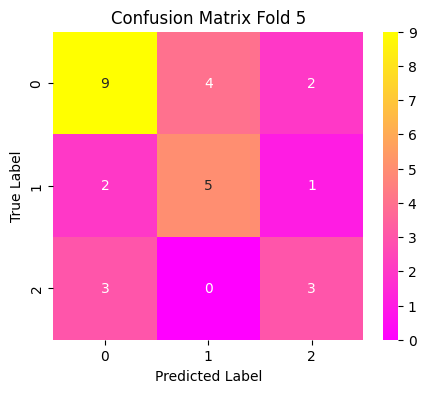

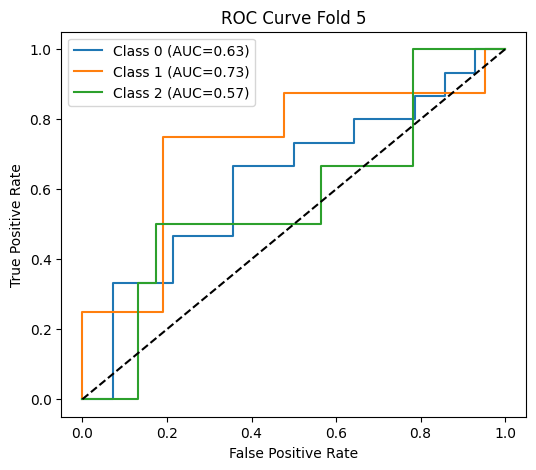


===== Average Metrics Across Folds =====
Accuracy: 0.5239, Precision: 0.5586, Recall: 0.5239, F1-score: 0.5272


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from transformers import AutoTokenizer, AutoModel
from transformers import ViTModel, ViTImageProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

text_model_name = "sagorsarker/bangla-bert-base"
image_model_name = "google/vit-base-patch16-224"

tokenizer = AutoTokenizer.from_pretrained(text_model_name)
image_processor = ViTImageProcessor.from_pretrained(image_model_name)

class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["Image_Path"]).convert("RGB")
        text = str(row["Preprocessed_Text"])
        label = int(row["Final_Label"])
        return image, text, label

def collate_fn(batch):
    images, texts, labels = zip(*batch)
    text_inputs = tokenizer(list(texts), padding=True, truncation=True, return_tensors="pt")
    image_inputs = image_processor(list(images), return_tensors="pt")
    return {
        "input_ids": text_inputs["input_ids"],
        "attention_mask": text_inputs["attention_mask"],
        "pixel_values": image_inputs["pixel_values"],
        "labels": torch.tensor(labels)
    }

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction=='mean':
            return focal_loss.mean()
        elif self.reduction=='sum':
            return focal_loss.sum()
        return focal_loss

class MulMoSenT_Sum(nn.Module):
    def __init__(self, num_classes=3):
        super(MulMoSenT_Sum, self).__init__()
        self.text_model = AutoModel.from_pretrained(text_model_name)
        self.image_model = ViTModel.from_pretrained(image_model_name)
        hidden_dim = 768
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim, num_classes)
    def forward(self, input_ids, attention_mask, pixel_values):
        text_cls = self.text_model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:,0,:]
        image_cls = self.image_model(pixel_values=pixel_values).last_hidden_state[:,0,:]
        F_sum = text_cls + image_cls
        x = self.dropout(F_sum)
        logits = self.classifier(x)
        return logits

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
num_classes = 3
all_fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(kf.split(df, df["Final_Label"])):
    print(f"\n===== Fold {fold+1} =====")
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)
    train_loader = DataLoader(MultimodalDataset(train_df), batch_size=8, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(MultimodalDataset(val_df), batch_size=8, shuffle=False, collate_fn=collate_fn)
    model = MulMoSenT_Sum().to(device)
    class_counts = train_df["Final_Label"].value_counts().sort_index()
    class_weights = 1./torch.tensor(class_counts.values, dtype=torch.float).to(device)
    criterion = FocalLoss(alpha=class_weights, gamma=2, reduction='mean')
    optimizer = optim.Adam(model.parameters(), lr=2e-5)
    epochs=5
    for epoch in range(epochs):
        model.train()
        total_loss=0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            optimizer.zero_grad()
            logits = model(input_ids, attention_mask, pixel_values)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            logits = model(input_ids, attention_mask, pixel_values)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    all_fold_metrics.append((acc, precision, recall, f1))
    print(f"Fold {fold+1} Metrics -> Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="spring")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix Fold {fold+1}")
    plt.show()
    y_bin = label_binarize(all_labels, classes=list(range(num_classes)))
    all_probs = np.array(all_probs)
    plt.figure(figsize=(6,5))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve Fold {fold+1}")
    plt.legend()
    plt.show()

avg_metrics = np.mean(all_fold_metrics, axis=0)
print("\n===== Average Metrics Across Folds =====")
print(f"Accuracy: {avg_metrics[0]:.4f}, Precision: {avg_metrics[1]:.4f}, Recall: {avg_metrics[2]:.4f}, F1-score: {avg_metrics[3]:.4f}")


# **Focal+Avg**


===== Fold 1 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0001
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 1 Metrics -> Accuracy: 0.6000, Precision: 0.6409, Recall: 0.6000, F1-score: 0.5976


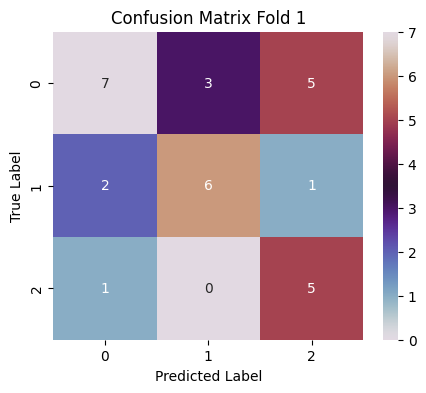

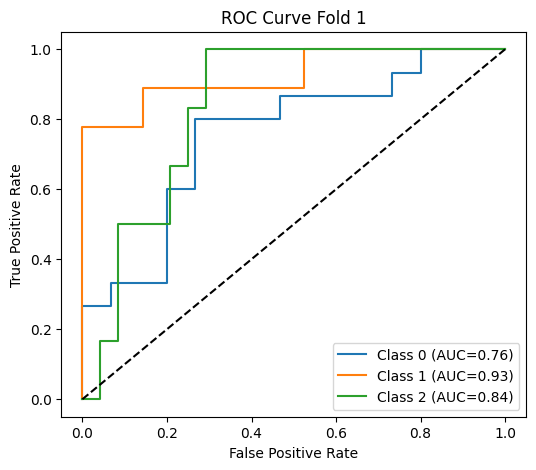


===== Fold 2 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0000
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 2 Metrics -> Accuracy: 0.5000, Precision: 0.6285, Recall: 0.5000, F1-score: 0.4909


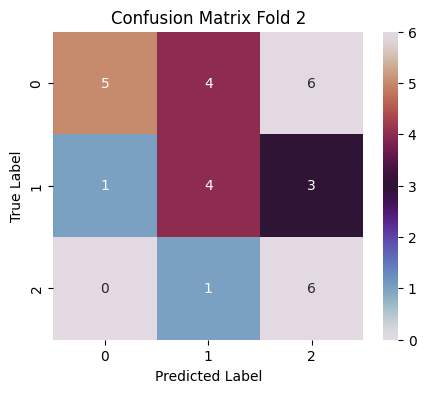

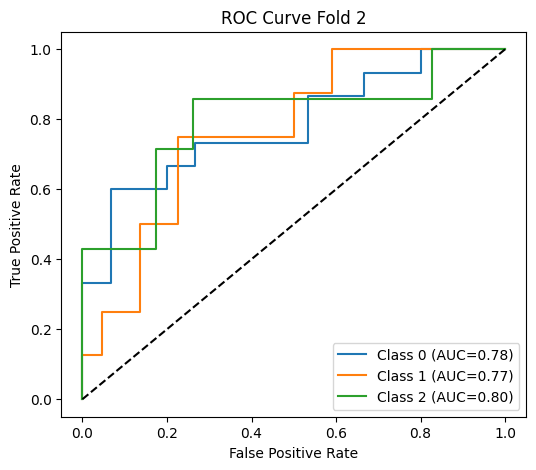


===== Fold 3 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0000
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 3 Metrics -> Accuracy: 0.4000, Precision: 0.3942, Recall: 0.4000, F1-score: 0.3874


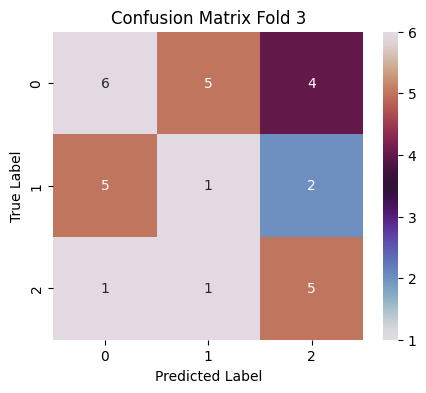

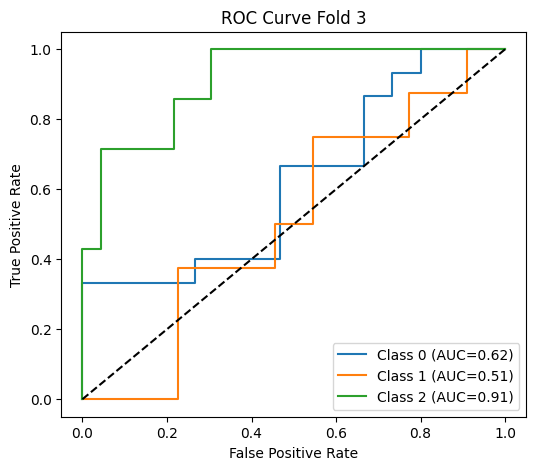


===== Fold 4 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0000
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 4 Metrics -> Accuracy: 0.5333, Precision: 0.5564, Recall: 0.5333, F1-score: 0.5257


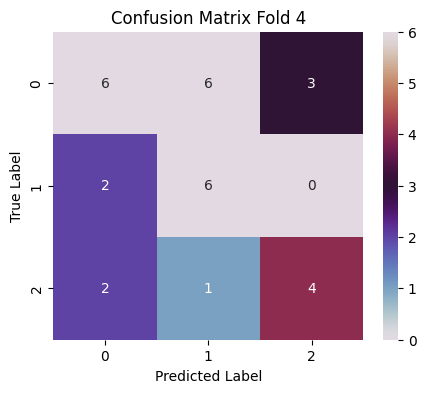

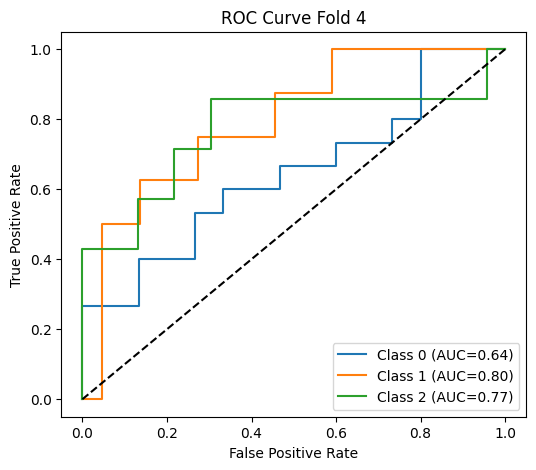


===== Fold 5 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.0000
Epoch 2 Loss: 0.0000
Epoch 3 Loss: 0.0000
Epoch 4 Loss: 0.0000
Epoch 5 Loss: 0.0000
Fold 5 Metrics -> Accuracy: 0.6207, Precision: 0.6931, Recall: 0.6207, F1-score: 0.6392


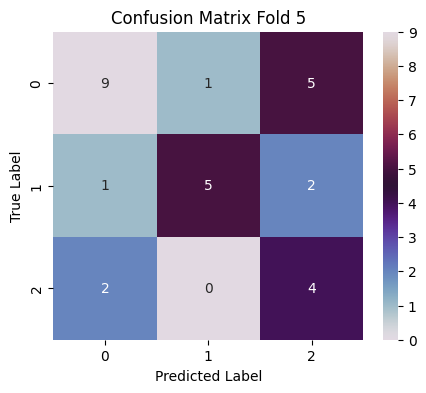

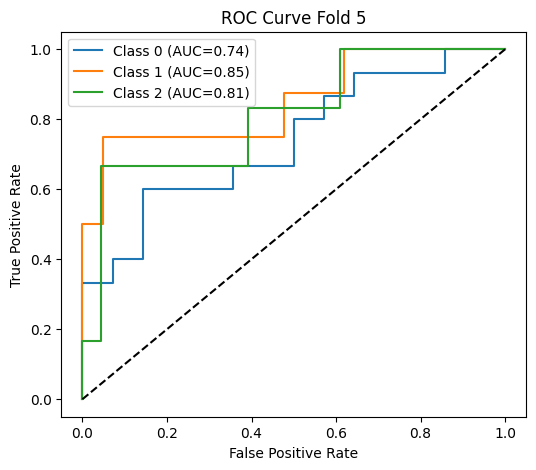


===== Average Metrics Across Folds =====
Accuracy: 0.5308, Precision: 0.5826, Recall: 0.5308, F1-score: 0.5282


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from transformers import AutoTokenizer, AutoModel
from transformers import ViTModel, ViTImageProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

text_model_name = "sagorsarker/bangla-bert-base"
image_model_name = "google/vit-base-patch16-224"

tokenizer = AutoTokenizer.from_pretrained(text_model_name)
image_processor = ViTImageProcessor.from_pretrained(image_model_name)

class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["Image_Path"]).convert("RGB")
        text = str(row["Preprocessed_Text"])
        label = int(row["Final_Label"])
        return image, text, label

def collate_fn(batch):
    images, texts, labels = zip(*batch)
    text_inputs = tokenizer(list(texts), padding=True, truncation=True, return_tensors="pt")
    image_inputs = image_processor(list(images), return_tensors="pt")
    return {
        "input_ids": text_inputs["input_ids"],
        "attention_mask": text_inputs["attention_mask"],
        "pixel_values": image_inputs["pixel_values"],
        "labels": torch.tensor(labels)
    }

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction=='mean':
            return focal_loss.mean()
        elif self.reduction=='sum':
            return focal_loss.sum()
        return focal_loss

class MulMoSenT_Avg(nn.Module):
    def __init__(self, num_classes=3):
        super(MulMoSenT_Avg, self).__init__()
        self.text_model = AutoModel.from_pretrained(text_model_name)
        self.image_model = ViTModel.from_pretrained(image_model_name)
        hidden_dim = 768
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim, num_classes)
    def forward(self, input_ids, attention_mask, pixel_values):
        text_cls = self.text_model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:,0,:]
        image_cls = self.image_model(pixel_values=pixel_values).last_hidden_state[:,0,:]
        F_avg = (text_cls + image_cls) / 2
        x = self.dropout(F_avg)
        logits = self.classifier(x)
        return logits

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
num_classes = 3
all_fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(kf.split(df, df["Final_Label"])):
    print(f"\n===== Fold {fold+1} =====")
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)
    train_loader = DataLoader(MultimodalDataset(train_df), batch_size=8, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(MultimodalDataset(val_df), batch_size=8, shuffle=False, collate_fn=collate_fn)
    model = MulMoSenT_Avg().to(device)
    class_counts = train_df["Final_Label"].value_counts().sort_index()
    class_weights = 1./torch.tensor(class_counts.values, dtype=torch.float).to(device)
    criterion = FocalLoss(alpha=class_weights, gamma=2, reduction='mean')
    optimizer = optim.Adam(model.parameters(), lr=2e-5)
    epochs=5
    for epoch in range(epochs):
        model.train()
        total_loss=0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            optimizer.zero_grad()
            logits = model(input_ids, attention_mask, pixel_values)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            logits = model(input_ids, attention_mask, pixel_values)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    all_fold_metrics.append((acc, precision, recall, f1))
    print(f"Fold {fold+1} Metrics -> Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="twilight")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix Fold {fold+1}")
    plt.show()
    y_bin = label_binarize(all_labels, classes=list(range(num_classes)))
    all_probs = np.array(all_probs)
    plt.figure(figsize=(6,5))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve Fold {fold+1}")
    plt.legend()
    plt.show()

avg_metrics = np.mean(all_fold_metrics, axis=0)
print("\n===== Average Metrics Across Folds =====")
print(f"Accuracy: {avg_metrics[0]:.4f}, Precision: {avg_metrics[1]:.4f}, Recall: {avg_metrics[2]:.4f}, F1-score: {avg_metrics[3]:.4f}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Accuracy: 0.3
Precision: 0.3331986531986532
Recall: 0.3
F1-score: 0.31036324786324787


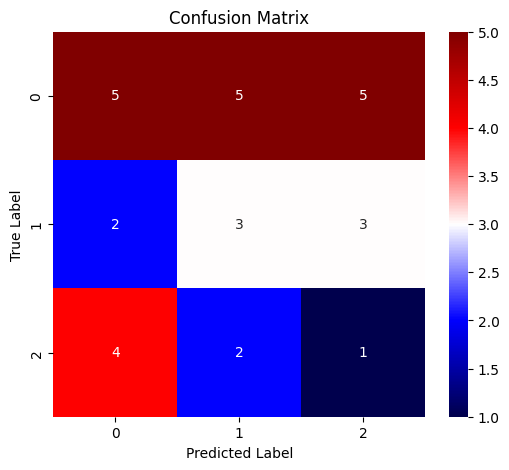

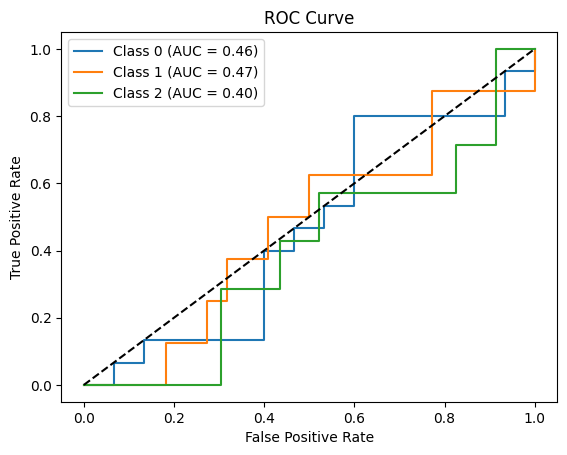

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC

from transformers import ViTModel, ViTImageProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Final_Label"],
    random_state=42
)

vectorizer = CountVectorizer(max_features=5000)
X_train_text = vectorizer.fit_transform(train_df["Preprocessed_Text"].astype(str))
X_test_text = vectorizer.transform(test_df["Preprocessed_Text"].astype(str))

image_model_name = "google/vit-base-patch16-224"
image_processor = ViTImageProcessor.from_pretrained(image_model_name)
vit_model = ViTModel.from_pretrained(image_model_name).to(device)
vit_model.eval()

def extract_vit_features(image_paths):
    features = []
    with torch.no_grad():
        for path in image_paths:
            image = Image.open(path).convert("RGB")
            inputs = image_processor(images=image, return_tensors="pt").to(device)
            outputs = vit_model(**inputs)
            cls_embedding = outputs.last_hidden_state[:, 0, :]
            features.append(cls_embedding.cpu().numpy().flatten())
    return np.array(features)

X_train_img = extract_vit_features(train_df["Image_Path"])
X_test_img = extract_vit_features(test_df["Image_Path"])

X_train = np.concatenate((X_train_text.toarray(), X_train_img), axis=1)
X_test = np.concatenate((X_test_text.toarray(), X_test_img), axis=1)

y_train = train_df["Final_Label"].values
y_test = test_df["Final_Label"].values

svm = SVC(kernel="rbf", probability=True, class_weight="balanced")
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="seismic", cbar=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure()
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

df_test = test_df.copy().reset_index(drop=True)
df_test["Predicted_Label"] = y_pred
df_test.to_csv("/content/drive/MyDrive/Political_Bias/CountVec_ViT_Predictions.csv", index=False)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



===== Fold 1 =====
Fold 1 Metrics -> Accuracy: 0.4667, Precision: 0.4558, Recall: 0.4667, F1-score: 0.4262


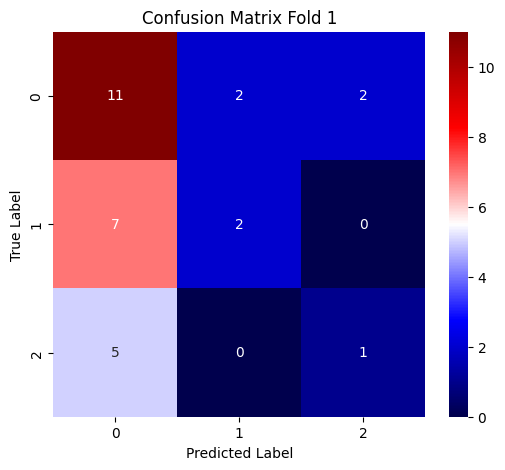

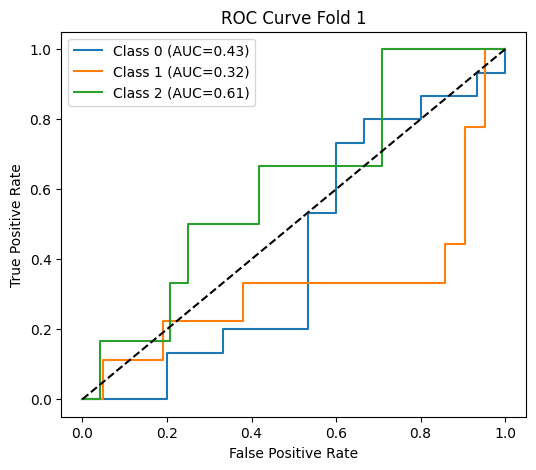


===== Fold 2 =====
Fold 2 Metrics -> Accuracy: 0.4667, Precision: 0.4960, Recall: 0.4667, F1-score: 0.4692


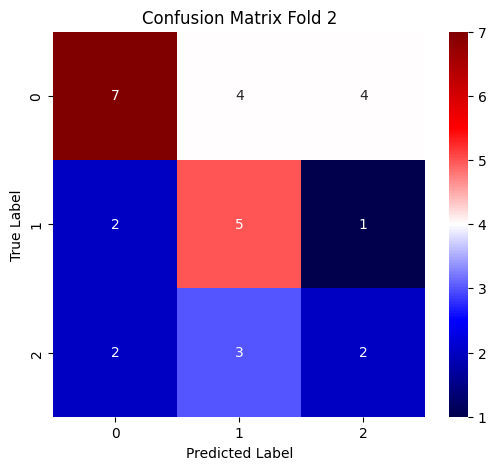

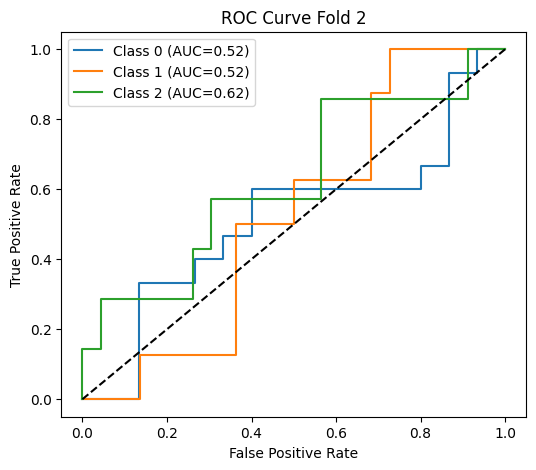


===== Fold 3 =====
Fold 3 Metrics -> Accuracy: 0.5667, Precision: 0.5710, Recall: 0.5667, F1-score: 0.5647


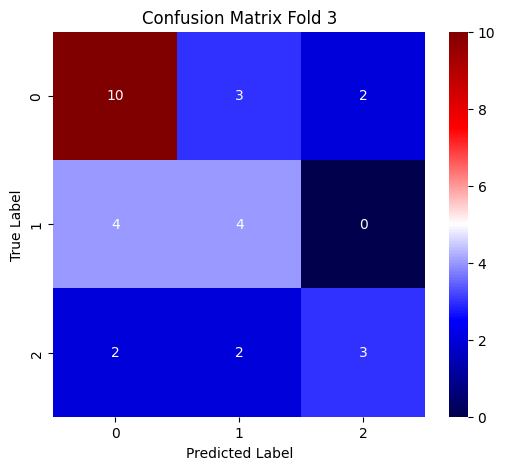

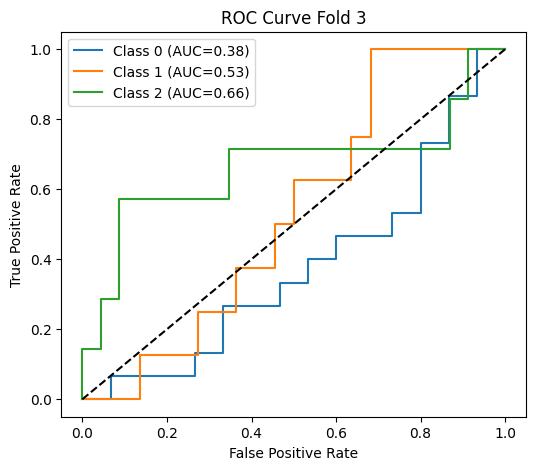


===== Fold 4 =====
Fold 4 Metrics -> Accuracy: 0.3667, Precision: 0.3845, Recall: 0.3667, F1-score: 0.3616


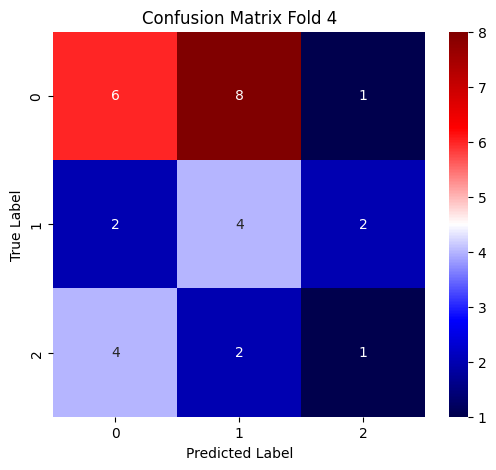

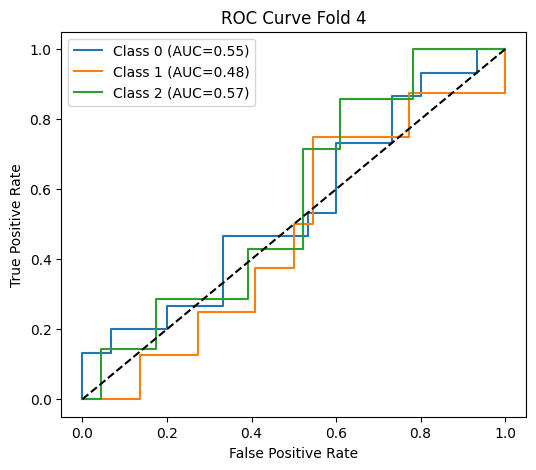


===== Fold 5 =====
Fold 5 Metrics -> Accuracy: 0.4483, Precision: 0.4565, Recall: 0.4483, F1-score: 0.4517


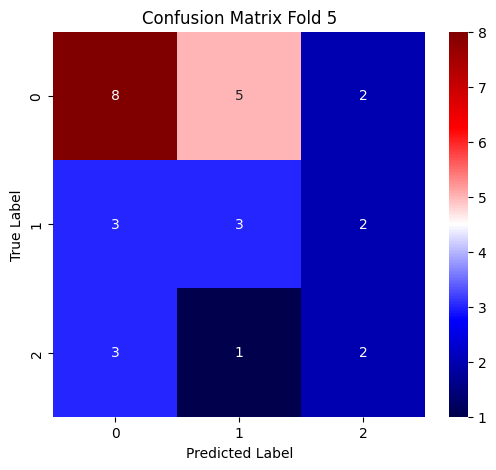

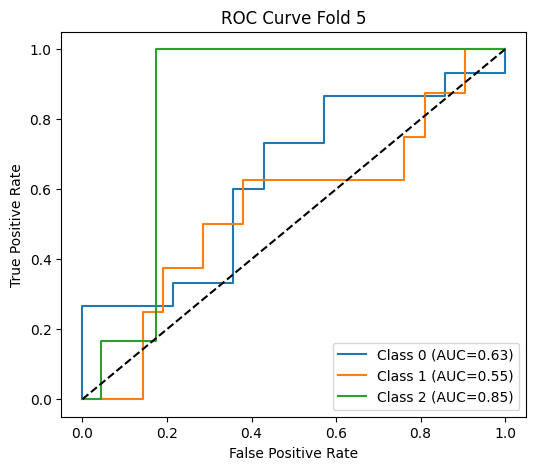


===== Average Metrics Across Folds =====
Accuracy: 0.4630, Precision: 0.4728, Recall: 0.4630, F1-score: 0.4547


In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC

from transformers import ViTModel, ViTImageProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CSV
csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_WithText.csv"
df = pd.read_csv(csv_path)

# Text vectorizer
vectorizer = CountVectorizer(max_features=5000)
X_text = vectorizer.fit_transform(df["Preprocessed_Text"].astype(str))

# ViT feature extractor
image_model_name = "google/vit-base-patch16-224"
image_processor = ViTImageProcessor.from_pretrained(image_model_name)
vit_model = ViTModel.from_pretrained(image_model_name).to(device)
vit_model.eval()

def extract_vit_features(image_paths):
    features = []
    with torch.no_grad():
        for path in image_paths:
            image = Image.open(path).convert("RGB")
            inputs = image_processor(images=image, return_tensors="pt").to(device)
            outputs = vit_model(**inputs)
            cls_embedding = outputs.last_hidden_state[:, 0, :]
            features.append(cls_embedding.cpu().numpy().flatten())
    return np.array(features)

X_img = extract_vit_features(df["Image_Path"])
X = np.concatenate((X_text.toarray(), X_img), axis=1)
y = df["Final_Label"].values

# Stratified K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
num_classes = len(np.unique(y))
all_fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n===== Fold {fold+1} =====")
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Use balanced class weights for SVM
    svm = SVC(kernel="rbf", probability=True, class_weight="balanced")
    svm.fit(X_train, y_train)

    y_pred = svm.predict(X_val)
    y_prob = svm.predict_proba(X_val)

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average="weighted")
    recall = recall_score(y_val, y_pred, average="weighted")
    f1 = f1_score(y_val, y_pred, average="weighted")
    all_fold_metrics.append((acc, precision, recall, f1))

    print(f"Fold {fold+1} Metrics -> Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="seismic")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix Fold {fold+1}")
    plt.show()

    # ROC Curve
    y_val_bin = label_binarize(y_val, classes=list(range(num_classes)))
    plt.figure(figsize=(6,5))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve Fold {fold+1}")
    plt.legend()
    plt.show()

# Average metrics
avg_metrics = np.mean(all_fold_metrics, axis=0)
print("\n===== Average Metrics Across Folds =====")
print(f"Accuracy: {avg_metrics[0]:.4f}, Precision: {avg_metrics[1]:.4f}, Recall: {avg_metrics[2]:.4f}, F1-score: {avg_metrics[3]:.4f}")

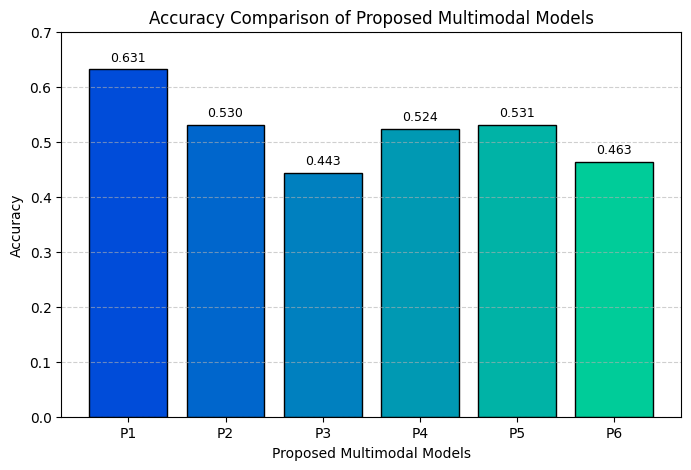

In [2]:
import matplotlib.pyplot as plt
import numpy as np

models = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']

accuracy = [0.6315, 0.5301, 0.4432, 0.5239, 0.5308, 0.463]

colors = plt.cm.winter(np.linspace(0.3, 0.8, len(models)))

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracy, color=colors, edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom', fontsize=9)

plt.ylim(0, 0.7)
plt.xlabel('Proposed Multimodal Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Proposed Multimodal Models')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()